In [1]:
#train pipleline


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.ndimage import gaussian_filter

In [3]:
N_BINS = 80

SIGMA = 1.0

EPS = 1e-10

SKIP_TIMESTEPS = 50

GAUSSIAN_KERNEL = (5, 5)


In [4]:
def get_input_data(
    pkl_path,
    layer_name,
):
    """
    Load the 2D trajectory dataset.

    Returns
    -------
    ground_truth : (n_traj, T, 2)

    prediction : (n_traj, T, 2)

    positions : (n_traj, T, 2)

    activations : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])

    prediction = np.asarray(data["prediction"])

    activations = np.asarray(data[layer_name])

    positions = prediction.copy()

    if SKIP_TIMESTEPS > 0:

        ground_truth = ground_truth[:, SKIP_TIMESTEPS:, :]

        prediction = prediction[:, SKIP_TIMESTEPS:, :]

        positions = positions[:, SKIP_TIMESTEPS:, :]

        activations = activations[:, SKIP_TIMESTEPS:, :]

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [5]:
def get_arena_bounds(positions):
    """
    Compute global arena bounds across all trajectories.

    Parameters
    ----------
    positions : ndarray
        Shape (n_traj, T, 2)

    Returns
    -------
    bounds : tuple
        (xmin, xmax, ymin, ymax)
    """

    xmin = np.min(positions[:, :, 0])
    xmax = np.max(positions[:, :, 0])

    ymin = np.min(positions[:, :, 1])
    ymax = np.max(positions[:, :, 1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [6]:
def get_arena_bounds(positions_list):
    """
    Compute global arena bounds shared across every trajectory.
    """

    all_positions = np.concatenate(positions_list, axis=0)

    xmin = np.min(all_positions[:,0])
    xmax = np.max(all_positions[:,0])

    ymin = np.min(all_positions[:,1])
    ymax = np.max(all_positions[:,1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [7]:
def bin_positions(
    positions,
    bins=N_BINS,
    bounds=None,
):
    """
    Assign every (x, y) position sample to a spatial bin.

    Parameters
    ----------
    positions : ndarray
        Shape (T, 2)

    bins : int
        Number of bins along each dimension.

    bounds : tuple
        (xmin, xmax, ymin, ymax)

    Returns
    -------
    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    x_edges : ndarray
        Bin edges along x.

    y_edges : ndarray
        Bin edges along y.
    """

    xmin, xmax, ymin, ymax = bounds

    x_edges = np.linspace(xmin, xmax, bins + 1)
    y_edges = np.linspace(ymin, ymax, bins + 1)

    x_bin = np.digitize(
        positions[:, 0],
        x_edges,
    ) - 1

    y_bin = np.digitize(
        positions[:, 1],
        y_edges,
    ) - 1

    # Keep indices inside the grid
    x_bin = np.clip(x_bin, 0, bins - 1)
    y_bin = np.clip(y_bin, 0, bins - 1)

    return x_bin, y_bin, x_edges, y_edges

In [8]:
def compute_occupancy_maps(
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D occupancy maps.

    Parameters
    ----------
    x_bin : ndarray
    y_bin : ndarray

    Returns
    -------
    count_occupancy : (bins,bins)

    probability_occupancy : (bins,bins)
    """

    count_occupancy = np.zeros((bins, bins), dtype=float)

    # Count visits
    for xb, yb in zip(x_bin, y_bin):
        count_occupancy[yb, xb] += 1

    total = np.sum(count_occupancy)

    if total > 0:
        probability_occupancy = count_occupancy / total
    else:
        probability_occupancy = np.zeros_like(count_occupancy)

    return count_occupancy, probability_occupancy

In [9]:
def compute_activity_maps(
    activity,
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D activity maps for ONE neuron.

    Parameters
    ----------
    activity : ndarray
        Shape (T,)

    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    Returns
    -------
    amplitude_activity : (bins, bins)

    real_activity : (bins, bins)
    """

    amplitude = np.abs(activity)

    real = np.real(activity)

    amplitude_activity = np.zeros((bins, bins), dtype=float)

    real_activity = np.zeros((bins, bins), dtype=float)

    for a, r, xb, yb in zip(
        amplitude,
        real,
        x_bin,
        y_bin,
    ):

        amplitude_activity[yb, xb] += a

        real_activity[yb, xb] += r

    return amplitude_activity, real_activity

In [10]:
def compute_firing_rate_map(
    activity_map,
    occupancy_map,
    eps=EPS,
):
    """
    Compute firing-rate map.

    Works for both 1D and 2D arrays.

    Parameters
    ----------
    activity_map : ndarray
    occupancy_map : ndarray

    Returns
    -------
    firing_rate_map : ndarray
    """

    firing_rate = np.divide(
        activity_map,
        occupancy_map + eps,
    )

    firing_rate[occupancy_map == 0] = 0

    return firing_rate

In [11]:
from scipy.signal import convolve2d


def matlab_style_gauss2D(shape=(5, 5), sigma=1.0):
    """
    2D Gaussian mask equivalent to MATLAB's

        fspecial('gaussian', shape, sigma)

    Parameters
    ----------
    shape : tuple
        Size of the Gaussian kernel.

    sigma : float
        Standard deviation of the Gaussian.

    Returns
    -------
    h : ndarray
        Normalized Gaussian kernel.
    """

    m, n = [(ss - 1.) / 2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x + y*y) / (2.0 * sigma * sigma))

    h[h < np.finfo(h.dtype).eps * h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h


def smooth_firing_rate_map(
    firing_rate_map,
    sigma=SIGMA,
    kernel_shape=GAUSSIAN_KERNEL,
):
    """
    Smooth a firing-rate map using a MATLAB-style Gaussian kernel.

    Parameters
    ----------
    firing_rate_map : ndarray
        2D firing-rate map.

    sigma : float
        Gaussian standard deviation.

    kernel_shape : tuple
        Kernel size used by MATLAB's fspecial.
    """

    kernel = matlab_style_gauss2D(
        shape=kernel_shape,
        sigma=sigma,
    )

    smoothed = convolve2d(
        firing_rate_map,
        kernel,
        mode="same",
        boundary="symm",
    )

    return smoothed

#main


In [12]:
import pickle
import numpy as np

layer_name = "d4"

trajectory_results_path = r"C:\Users\ALL AtoZ\Desktop\2d_hippocampal_cells\2D-traj-results-test.pkl"

ground_truth, prediction, positions, activations = get_input_data(
    trajectory_results_path,
    layer_name,
)

In [13]:
print("Ground Truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

Ground Truth : (50, 450, 2)
Prediction   : (50, 450, 2)
Positions    : (50, 450, 2)
Activations  : (50, 450, 100)


In [14]:
bounds = get_arena_bounds(positions)

print(bounds)

(0.04950893297791481, 0.9475427269935608, 0.03876063600182533, 0.942124605178833)


In [15]:
trajectory = 0
neuron = 0

trajectory_positions = positions[trajectory]

activity = activations[trajectory, :, neuron]

print("Trajectory positions:", trajectory_positions.shape)
print("Neuron activity:", activity.shape)

Trajectory positions: (450, 2)
Neuron activity: (450,)


In [16]:
x_bin, y_bin, x_edges, y_edges = bin_positions(
    trajectory_positions,
    bins=N_BINS,
    bounds=bounds,
)

print("x bins:", x_bin.shape)
print("y bins:", y_bin.shape)

print()

print("x range:", x_bin.min(), "to", x_bin.max())
print("y range:", y_bin.min(), "to", y_bin.max())

print()

print("First 10 x bins:", x_bin[:10])
print("First 10 y bins:", y_bin[:10])

x bins: (450,)
y bins: (450,)

x range: 13 to 66
y range: 0 to 48

First 10 x bins: [57 57 57 58 58 58 58 59 59 59]
First 10 y bins: [30 30 30 30 29 29 29 28 28 27]


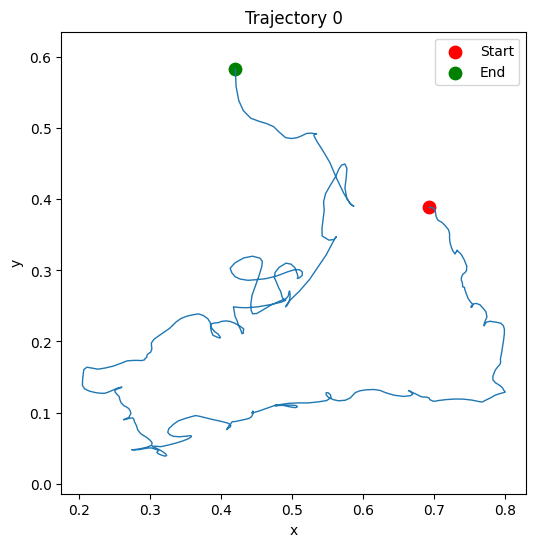

In [17]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_positions[:,0],
    trajectory_positions[:,1],
    lw=1,
)

plt.scatter(
    trajectory_positions[0,0],
    trajectory_positions[0,1],
    c="red",
    s=80,
    label="Start",
)

plt.scatter(
    trajectory_positions[-1,0],
    trajectory_positions[-1,1],
    c="green",
    s=80,
    label="End",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory 0")

plt.legend()
plt.axis("equal")

plt.show()

In [18]:
count_occ, prob_occ = compute_occupancy_maps(
    x_bin,
    y_bin,
)

print("Count occupancy shape:", count_occ.shape)
print("Probability occupancy shape:", prob_occ.shape)

print()

print("Total samples:", count_occ.sum())
print("Probability sum:", prob_occ.sum())

Count occupancy shape: (80, 80)
Probability occupancy shape: (80, 80)

Total samples: 450.0
Probability sum: 0.9999999999999999


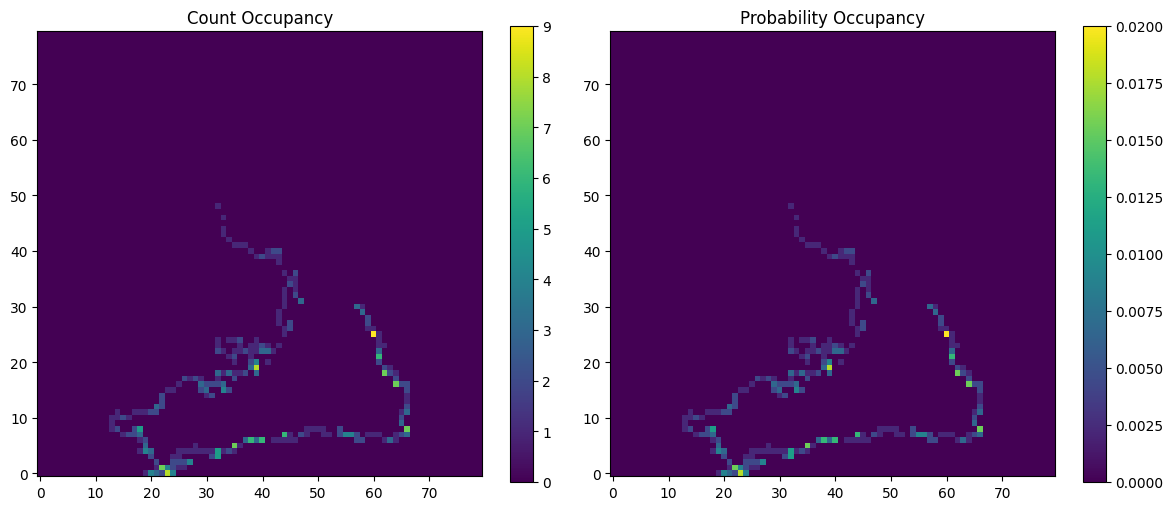

In [19]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

im = ax[0].imshow(
    count_occ,
    origin="lower",
    interpolation="nearest",
)

ax[0].set_title("Count Occupancy")

plt.colorbar(im, ax=ax[0])

im = ax[1].imshow(
    prob_occ,
    origin="lower",
    interpolation="nearest",
)

ax[1].set_title("Probability Occupancy")

plt.colorbar(im, ax=ax[1])

plt.tight_layout()

plt.show()

In [20]:
amp_activity, real_activity = compute_activity_maps(
    activity,
    x_bin,
    y_bin,
)

In [21]:
print("Amplitude Activity Shape:", amp_activity.shape)
print("Real Activity Shape:", real_activity.shape)

print()

print("Total Amplitude:", amp_activity.sum())
print("Total Real:", real_activity.sum())


Amplitude Activity Shape: (80, 80)
Real Activity Shape: (80, 80)

Total Amplitude: 134.85207266711905
Total Real: 132.33802548817084


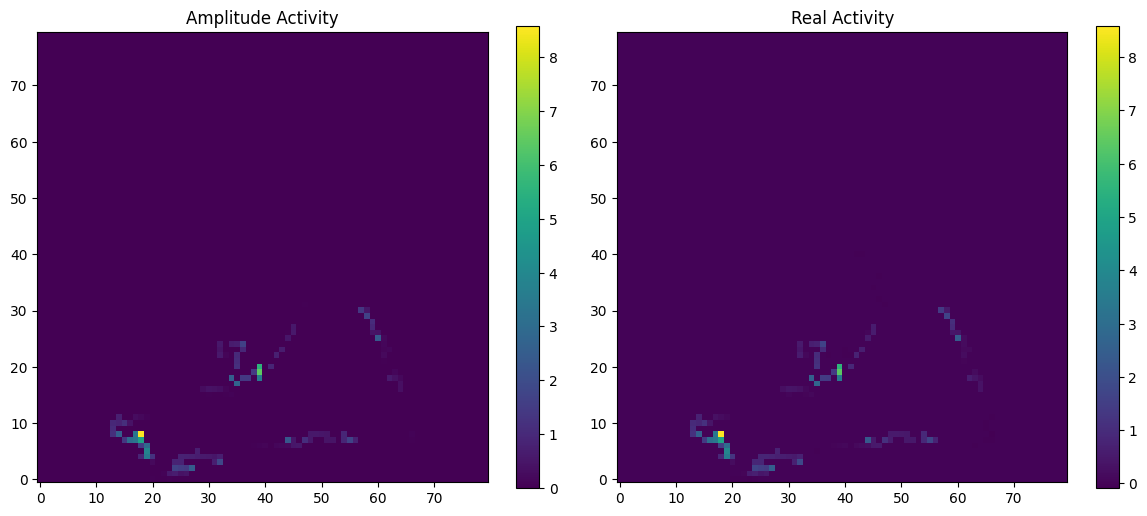

In [22]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

im = ax[0].imshow(
    amp_activity,
    origin="lower",
)

ax[0].set_title("Amplitude Activity")

plt.colorbar(im, ax=ax[0])

im = ax[1].imshow(
    real_activity,
    origin="lower",
)

ax[1].set_title("Real Activity")

plt.colorbar(im, ax=ax[1])

plt.tight_layout()

plt.show()

In [24]:
amp_count_rate = compute_firing_rate_map(
    amp_activity,
    count_occ,
)

amp_prob_rate = compute_firing_rate_map(
    amp_activity,
    prob_occ,
)

real_count_rate = compute_firing_rate_map(
    real_activity,
    count_occ,
)

real_prob_rate = compute_firing_rate_map(
    real_activity,
    prob_occ,
)

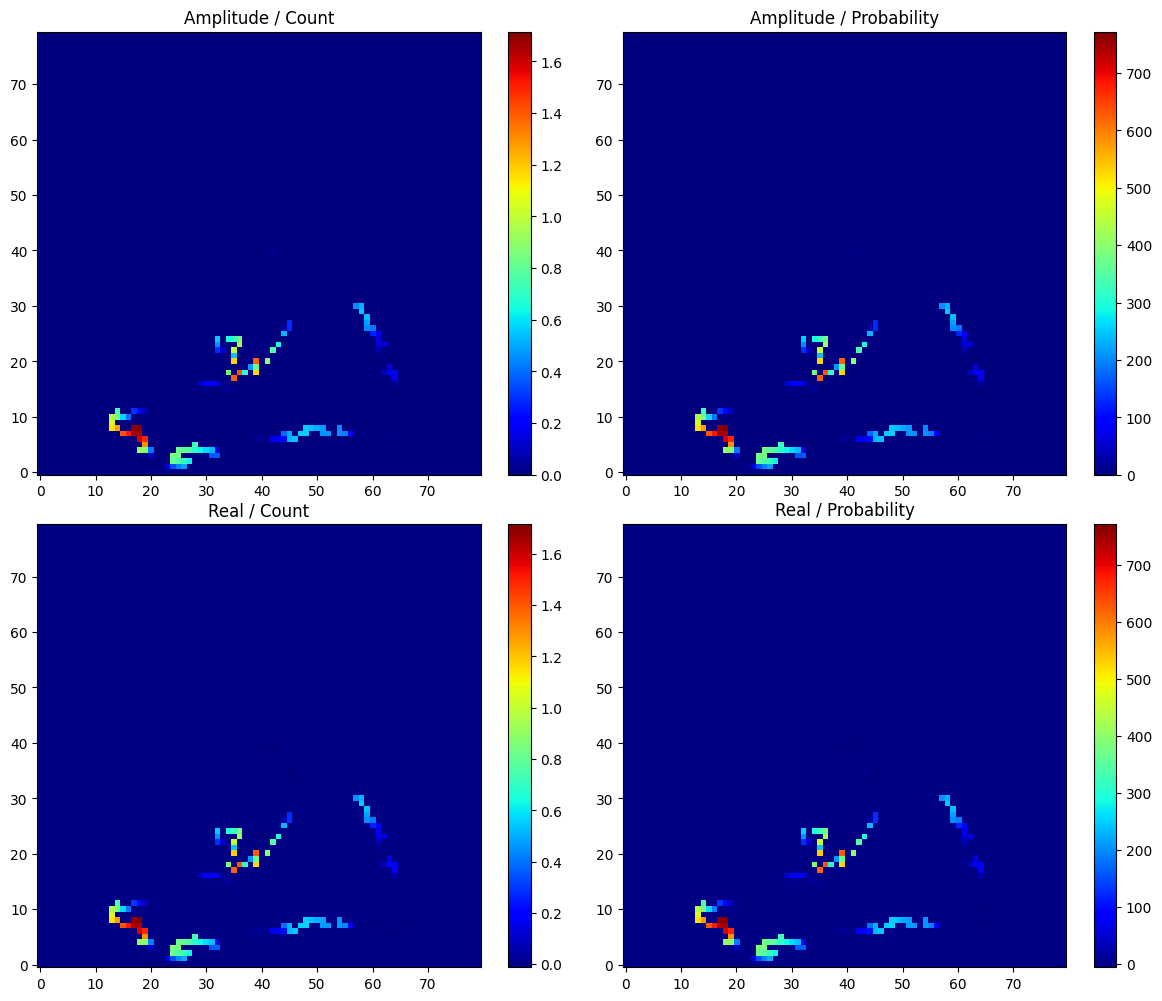

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

maps = [

    ("Amplitude / Count", amp_count_rate),

    ("Amplitude / Probability", amp_prob_rate),

    ("Real / Count", real_count_rate),

    ("Real / Probability", real_prob_rate),

]

for axis, (title, rate_map) in zip(ax.ravel(), maps):

    im = axis.imshow(
        rate_map,
        origin="lower",
        interpolation="nearest",
        cmap="jet",
    )

    axis.set_title(title)

    plt.colorbar(im, ax=axis)

plt.tight_layout()

plt.show()

In [26]:
print("Amplitude / Count:", amp_count_rate.shape)
print("Amplitude / Probability:", amp_prob_rate.shape)

print("Real / Count:", real_count_rate.shape)
print("Real / Probability:", real_prob_rate.shape)

Amplitude / Count: (80, 80)
Amplitude / Probability: (80, 80)
Real / Count: (80, 80)
Real / Probability: (80, 80)


In [27]:
amp_count_smoothed = smooth_firing_rate_map(amp_count_rate)

amp_prob_smoothed = smooth_firing_rate_map(amp_prob_rate)

real_count_smoothed = smooth_firing_rate_map(real_count_rate)

real_prob_smoothed = smooth_firing_rate_map(real_prob_rate)

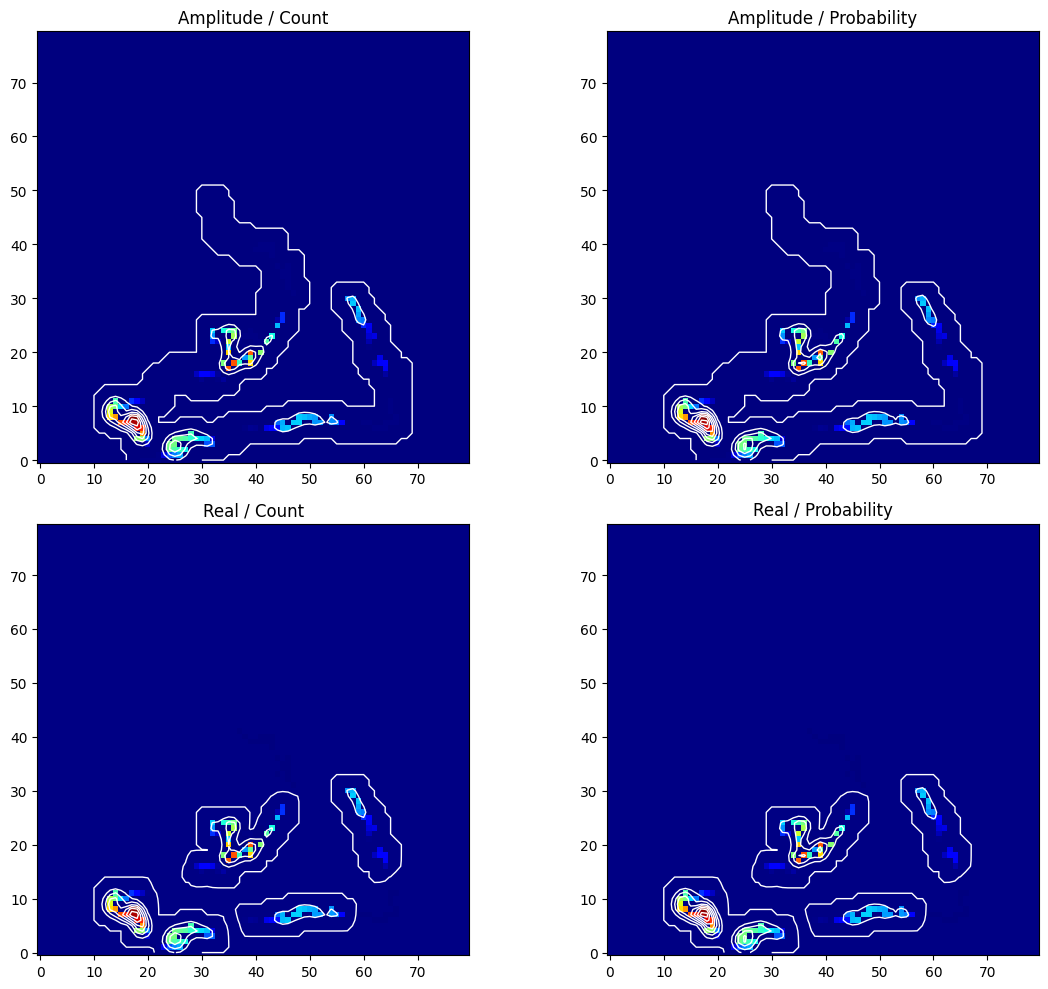

In [28]:
fig, ax = plt.subplots(2,2, figsize=(12,10))

maps = [

    ("Amplitude / Count",
     amp_count_rate,
     amp_count_smoothed),

    ("Amplitude / Probability",
     amp_prob_rate,
     amp_prob_smoothed),

    ("Real / Count",
     real_count_rate,
     real_count_smoothed),

    ("Real / Probability",
     real_prob_rate,
     real_prob_smoothed),
]

for axis, (title, raw, smooth) in zip(ax.ravel(), maps):

    axis.imshow(
        raw,
        origin="lower",
        interpolation="nearest",
        cmap="jet"
    )

    axis.contour(
        smooth,
        colors="white",
        linewidths=1,
    )

    axis.set_title(title)

plt.tight_layout()

plt.show()

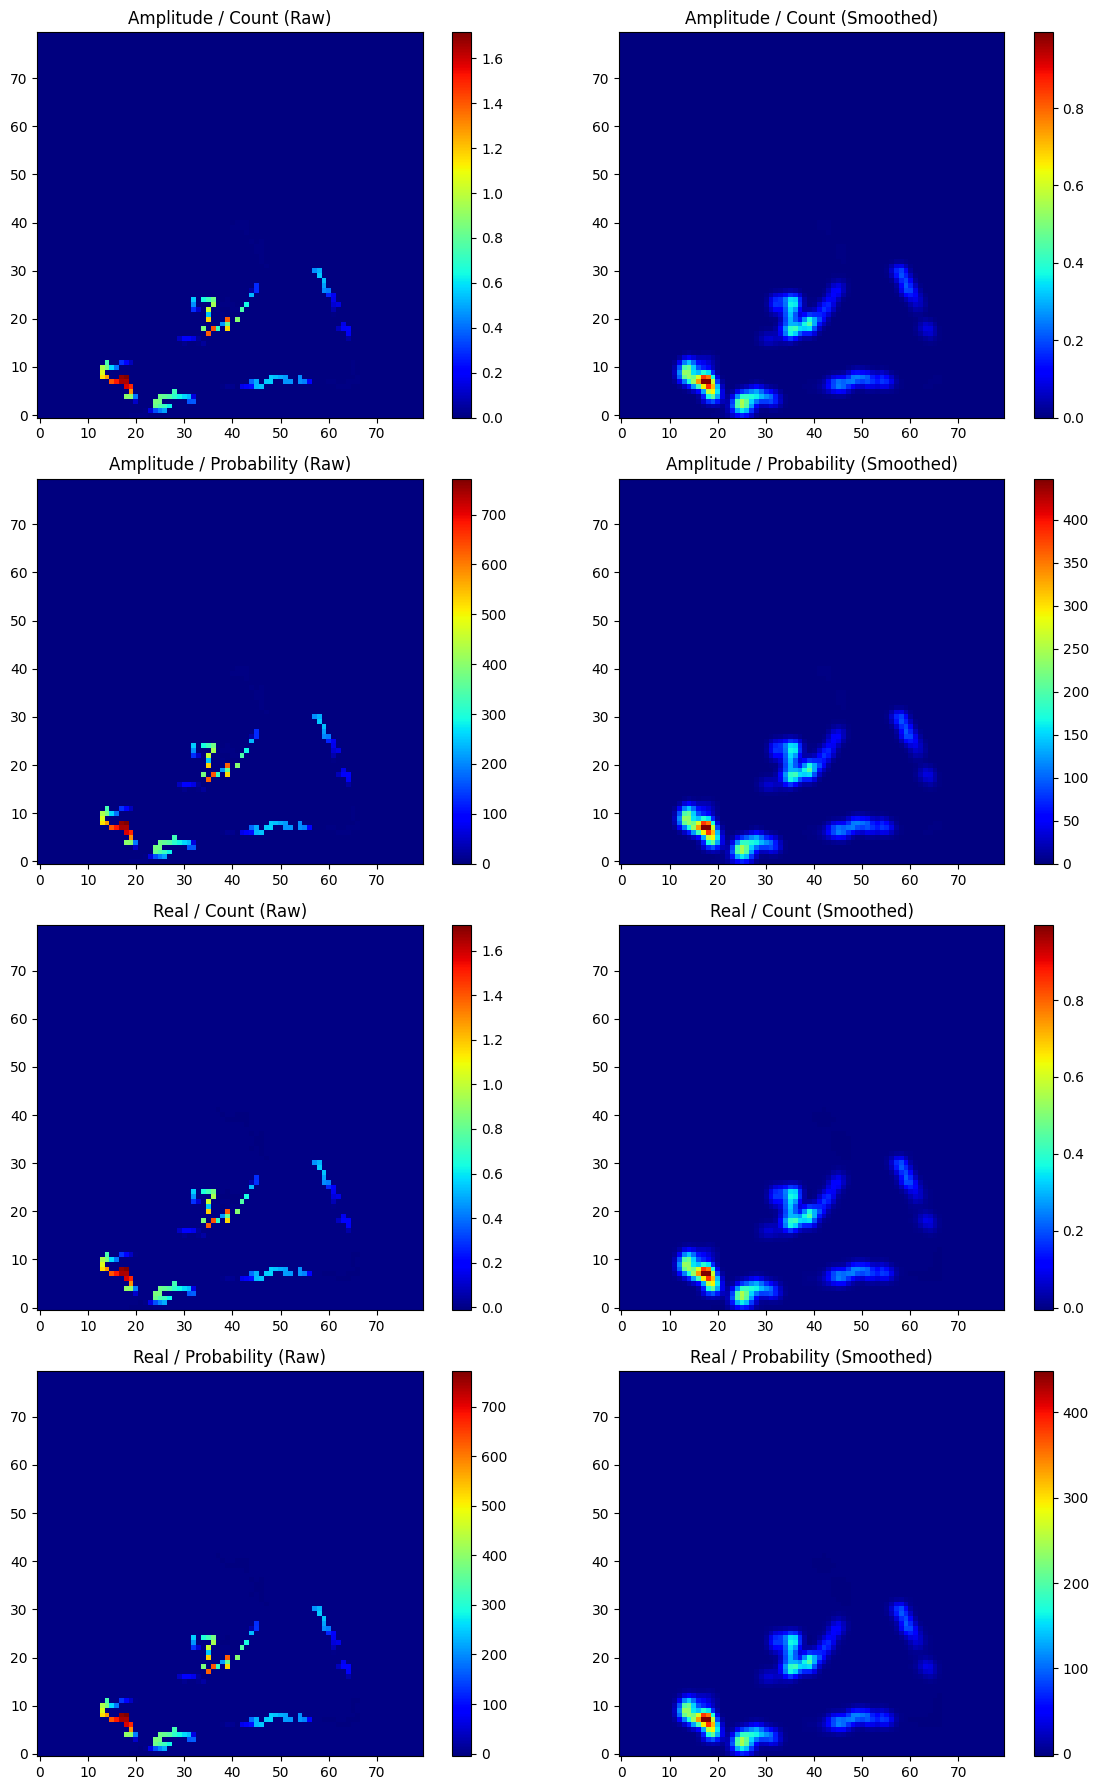

In [29]:
fig, ax = plt.subplots(4, 2, figsize=(12, 18))

maps = [

    ("Amplitude / Count",
     amp_count_rate,
     amp_count_smoothed),

    ("Amplitude / Probability",
     amp_prob_rate,
     amp_prob_smoothed),

    ("Real / Count",
     real_count_rate,
     real_count_smoothed),

    ("Real / Probability",
     real_prob_rate,
     real_prob_smoothed),
]

for row, (title, raw, smooth) in enumerate(maps):

    im = ax[row, 0].imshow(
        raw,
        origin="lower",
        interpolation="nearest",
        cmap="jet"
    )

    ax[row, 0].set_title(f"{title} (Raw)")
    plt.colorbar(im, ax=ax[row, 0])

    im = ax[row, 1].imshow(
        smooth,
        origin="lower",
        interpolation="nearest",
        cmap="jet"
    )

    ax[row, 1].set_title(f"{title} (Smoothed)")
    plt.colorbar(im, ax=ax[row, 1])

plt.tight_layout()

plt.show()

In [30]:
all_results = []

trajectory = 0

trajectory_positions = positions[trajectory]

x_bin, y_bin, _, _ = bin_positions(
    trajectory_positions,
    bins=N_BINS,
    bounds=bounds,
)

count_occ, prob_occ = compute_occupancy_maps(
    x_bin,
    y_bin,
)

n_neurons = activations.shape[2]

for neuron in range(n_neurons):

    activity = activations[
        trajectory,
        :,
        neuron,
    ]

    amp_activity, real_activity = compute_activity_maps(
        activity,
        x_bin,
        y_bin,
    )

    amp_count = compute_firing_rate_map(
        amp_activity,
        count_occ,
    )

    amp_prob = compute_firing_rate_map(
        amp_activity,
        prob_occ,
    )

    real_count = compute_firing_rate_map(
        real_activity,
        count_occ,
    )

    real_prob = compute_firing_rate_map(
        real_activity,
        prob_occ,
    )

    amp_count_s = smooth_firing_rate_map(
        amp_count,
    )

    amp_prob_s = smooth_firing_rate_map(
        amp_prob,
    )

    real_count_s = smooth_firing_rate_map(
        real_count,
    )

    real_prob_s = smooth_firing_rate_map(
        real_prob,
    )

    all_results.append({

        "neuron": neuron,

        "amp_count_smoothed": amp_count_s,
        "amp_prob_smoothed": amp_prob_s,

        "real_count_smoothed": real_count_s,
        "real_prob_smoothed": real_prob_s,

    })

print(f"Processed {len(all_results)} neurons.")

Processed 100 neurons.


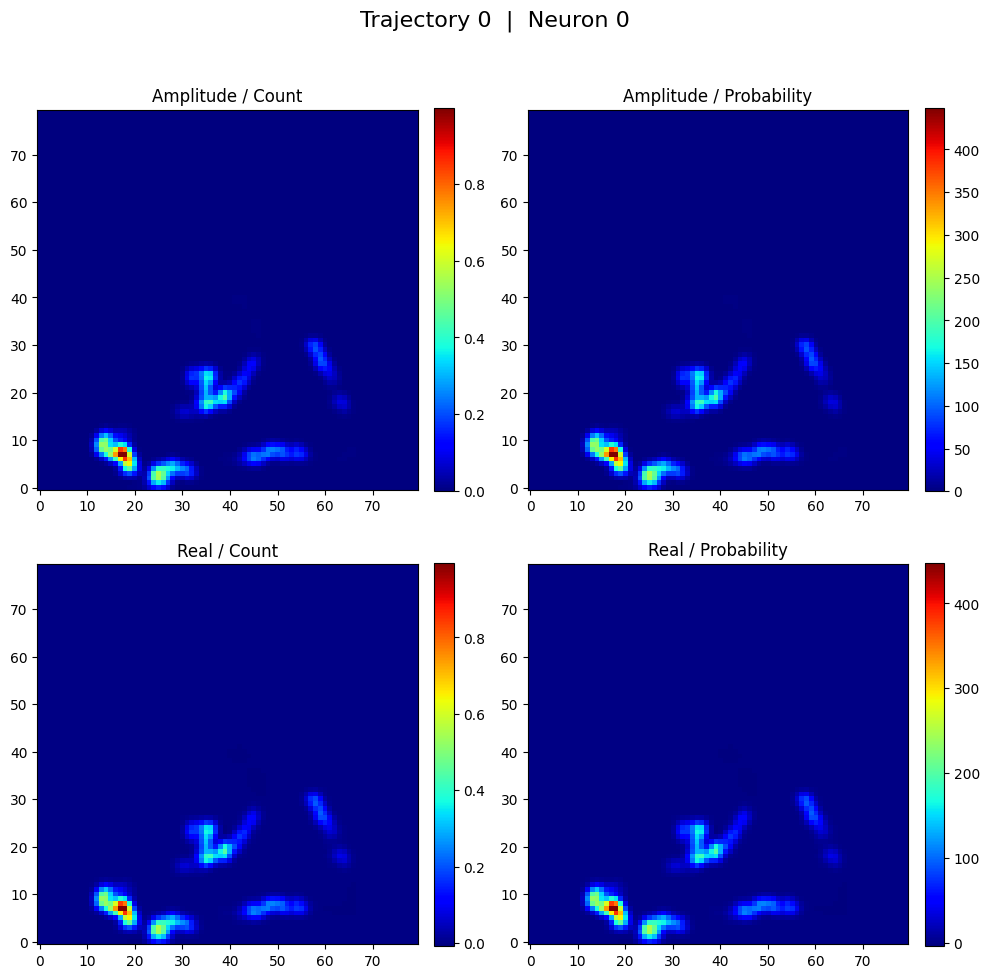

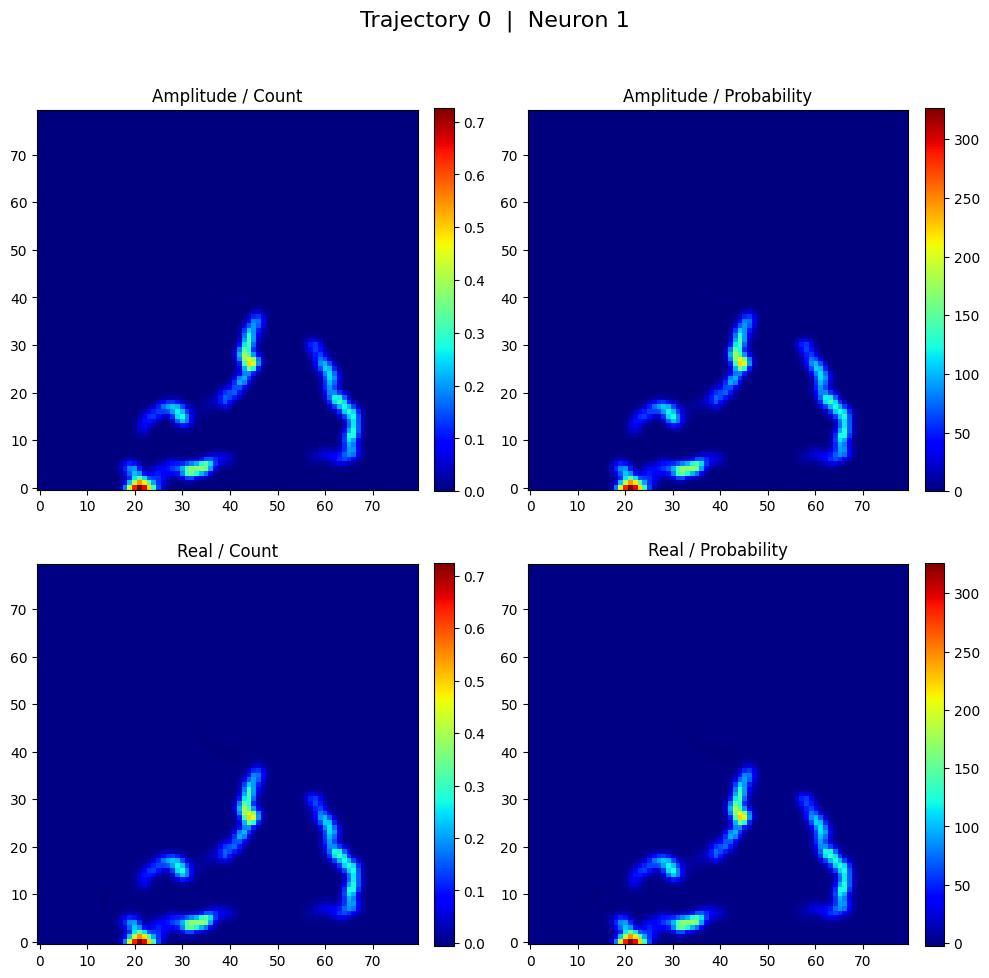

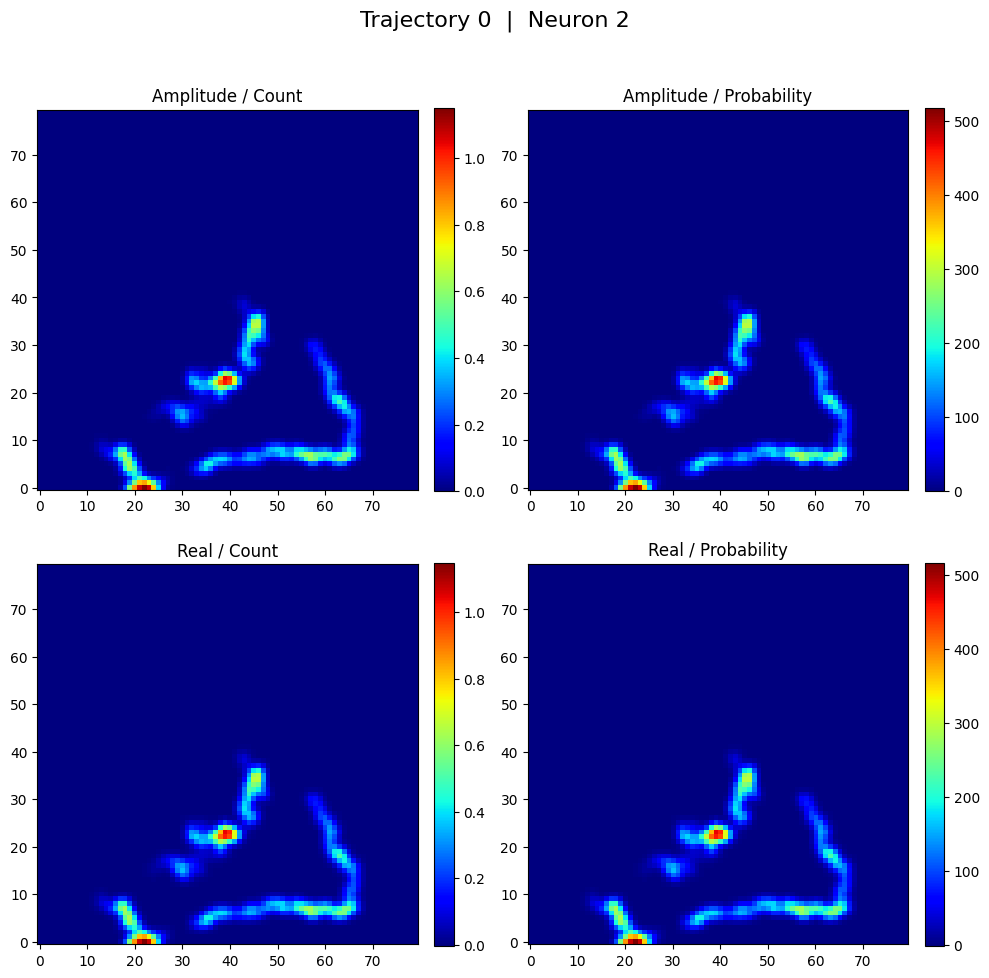

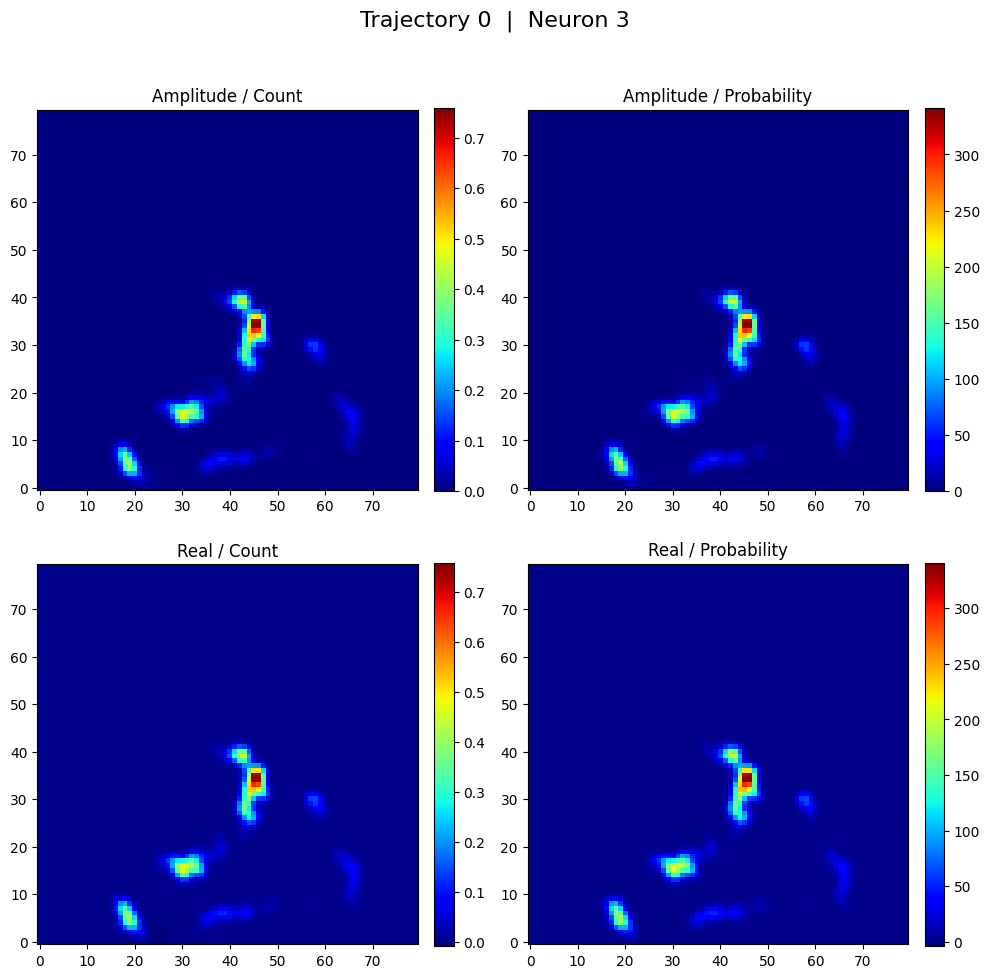

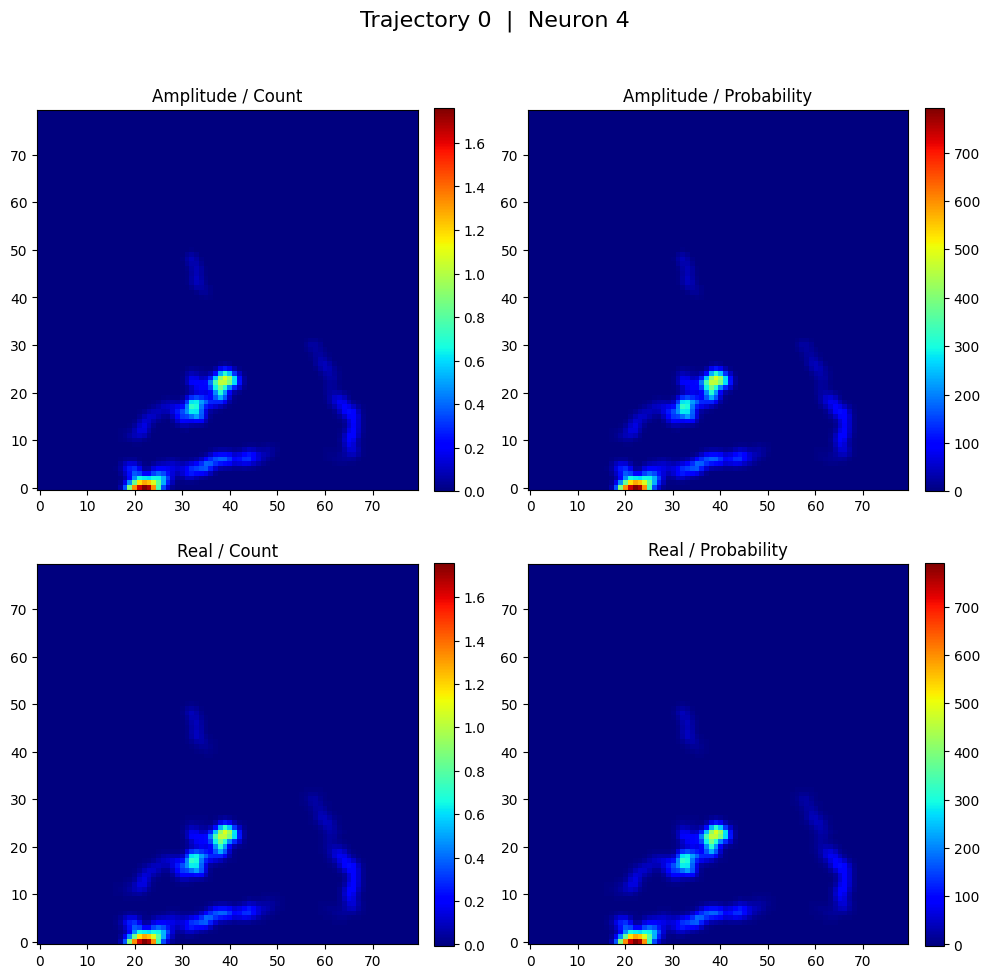

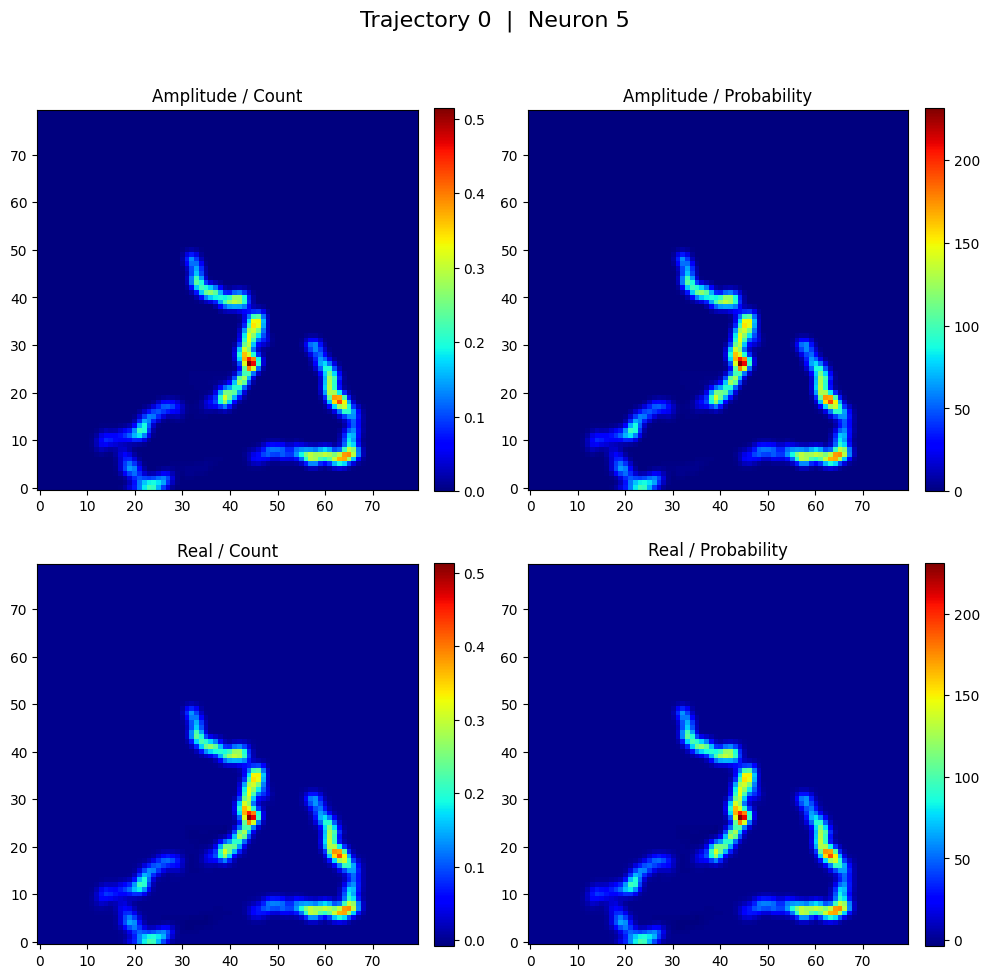

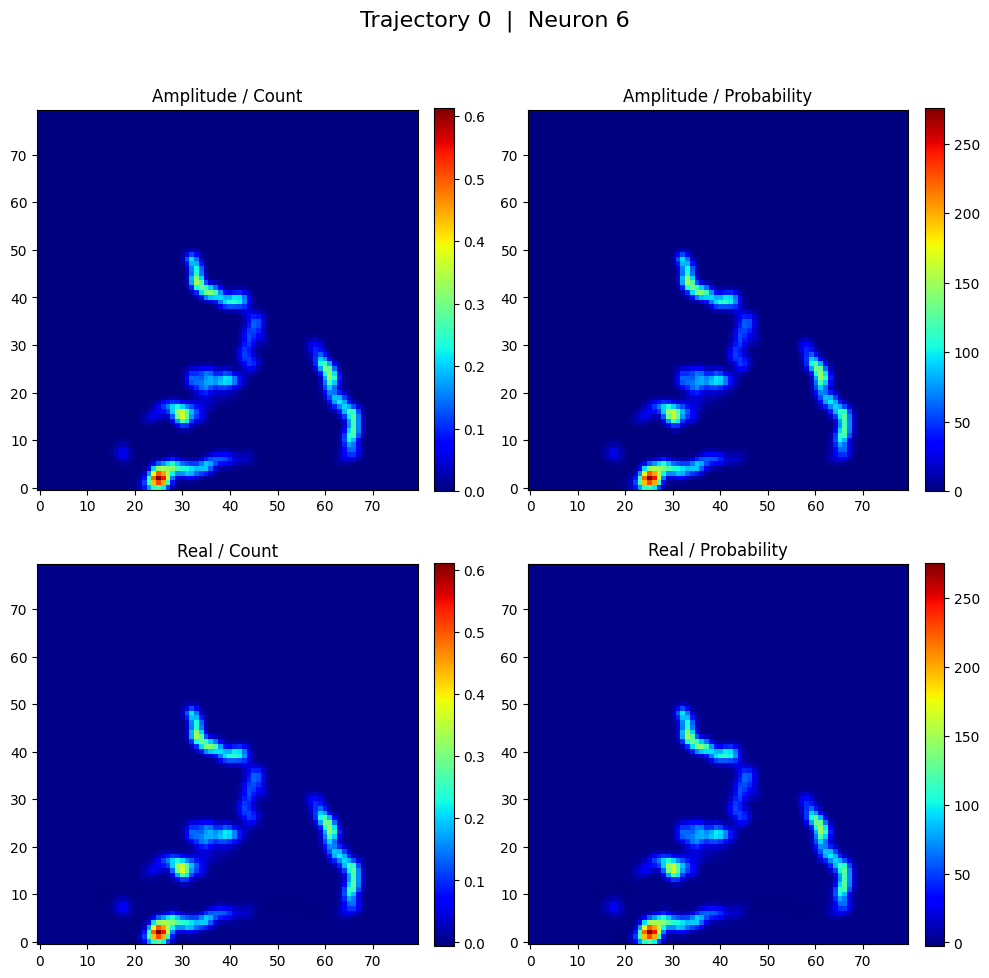

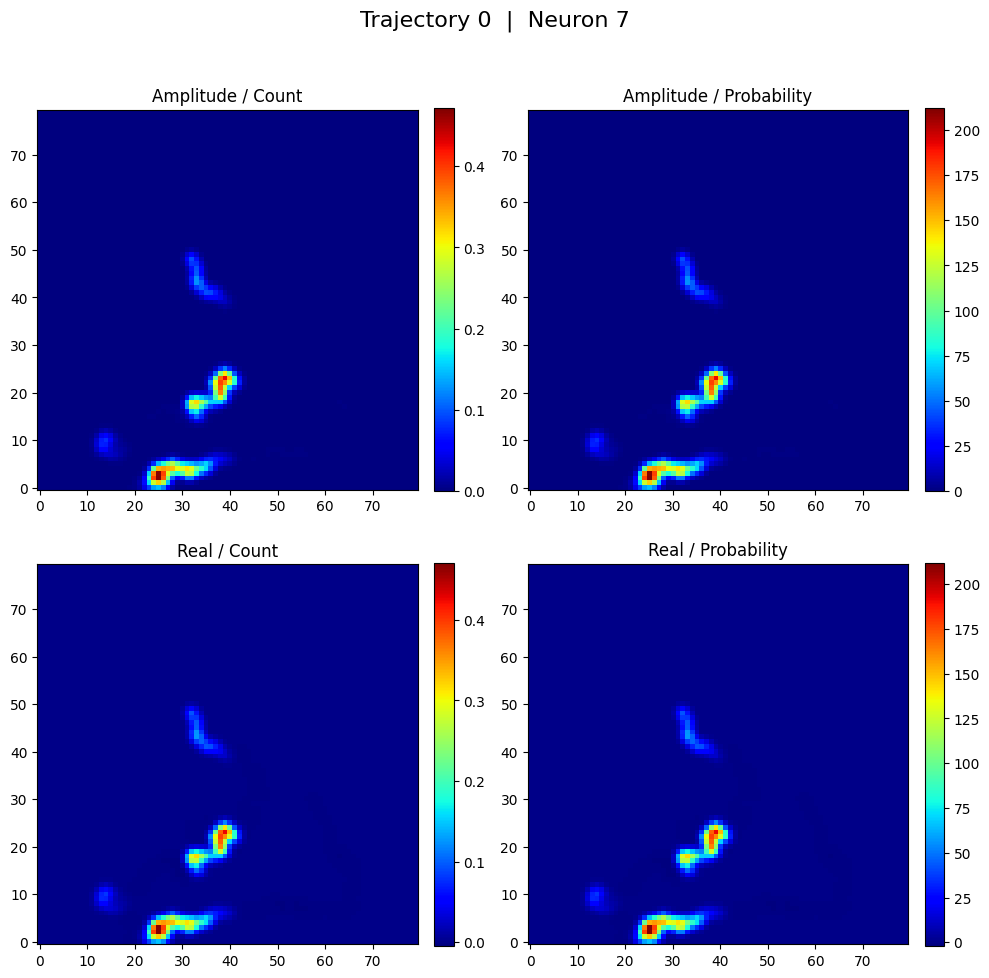

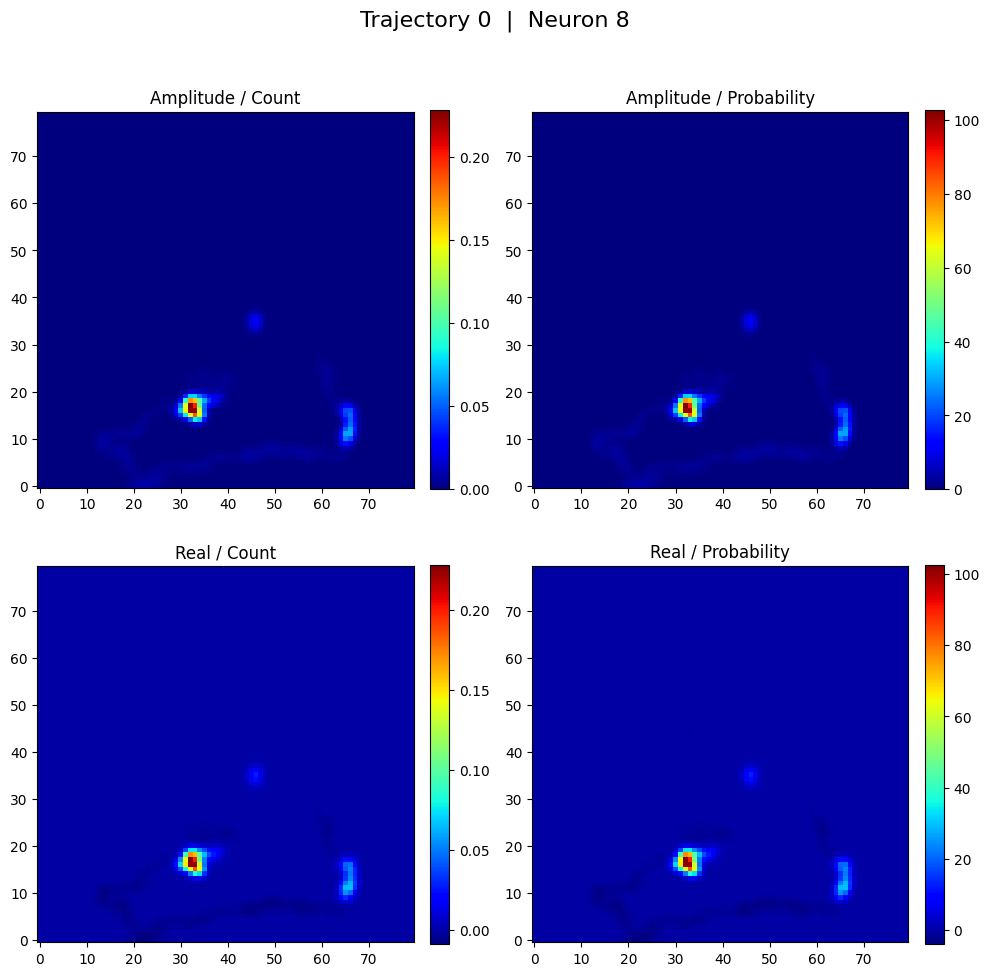

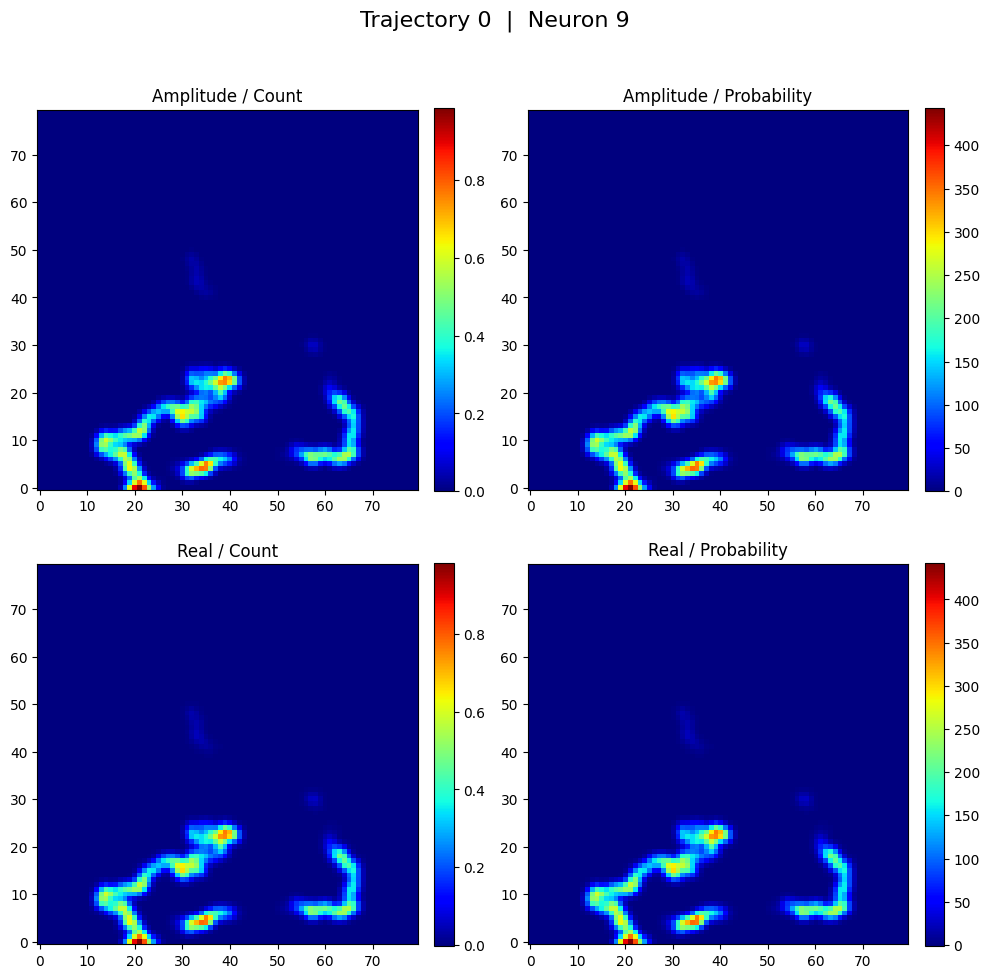

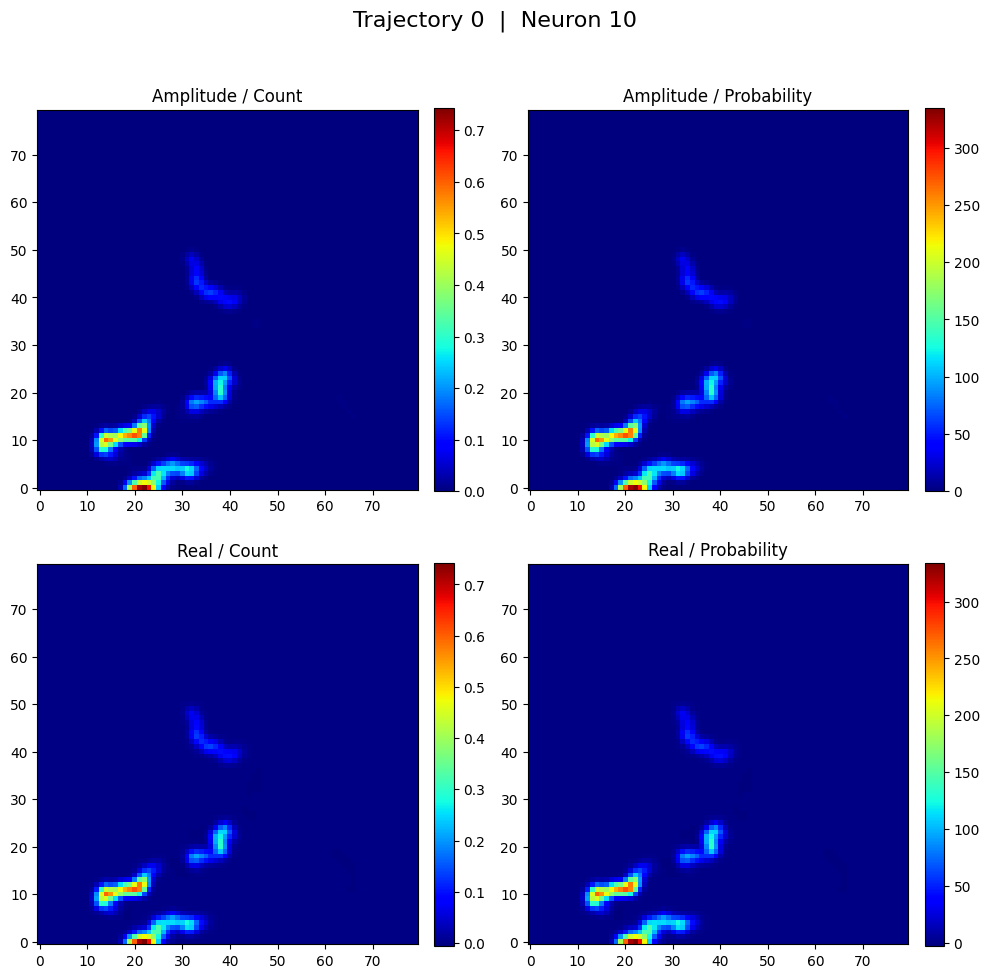

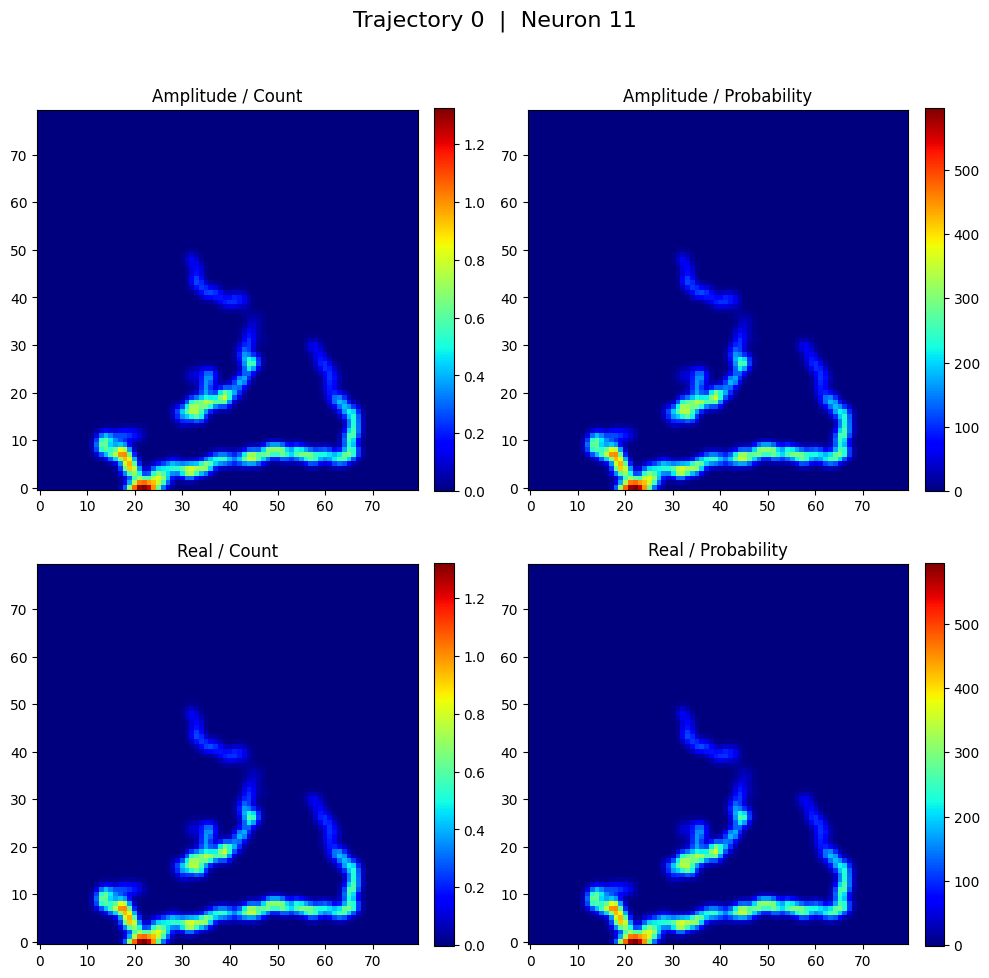

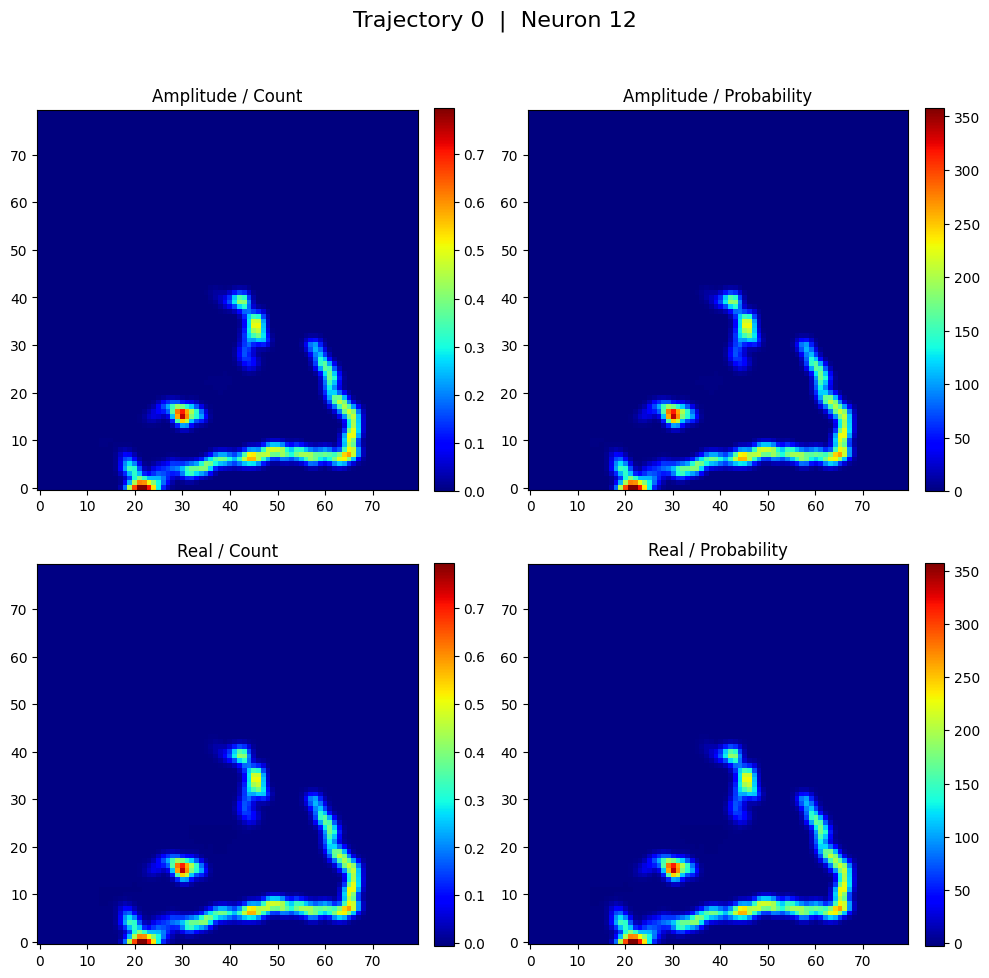

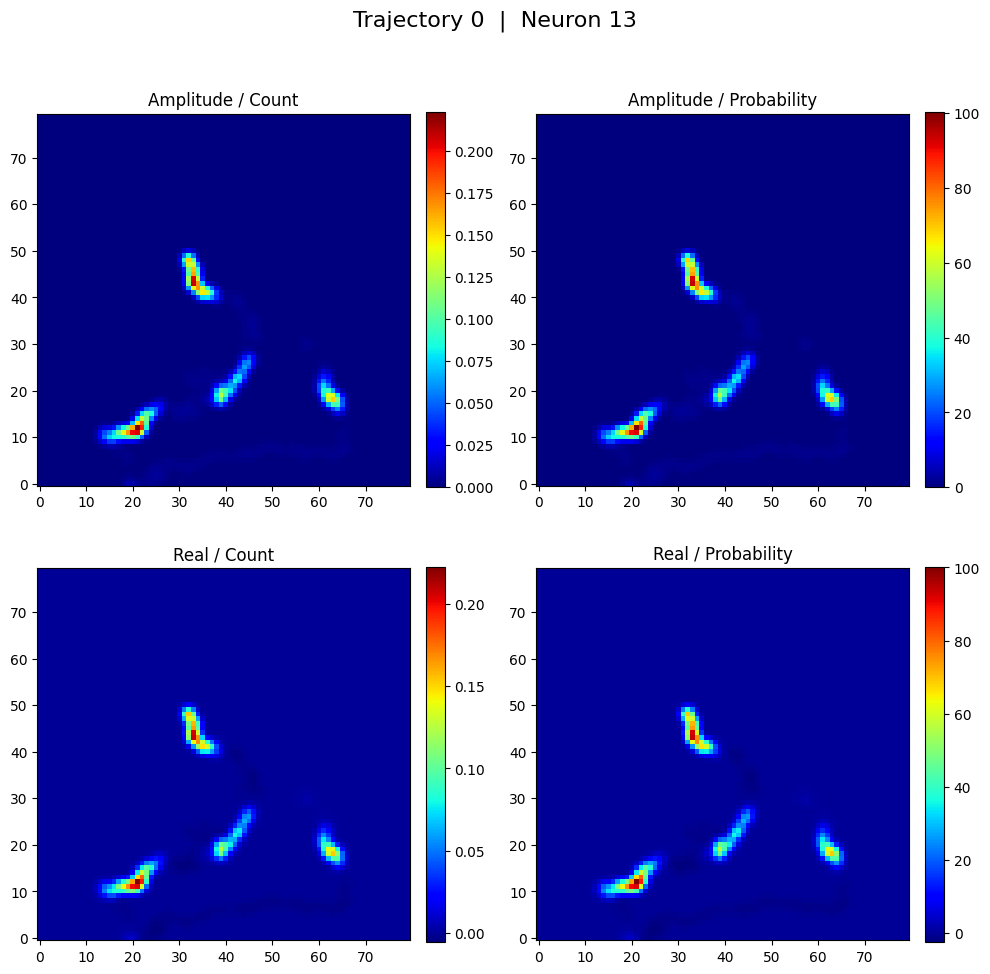

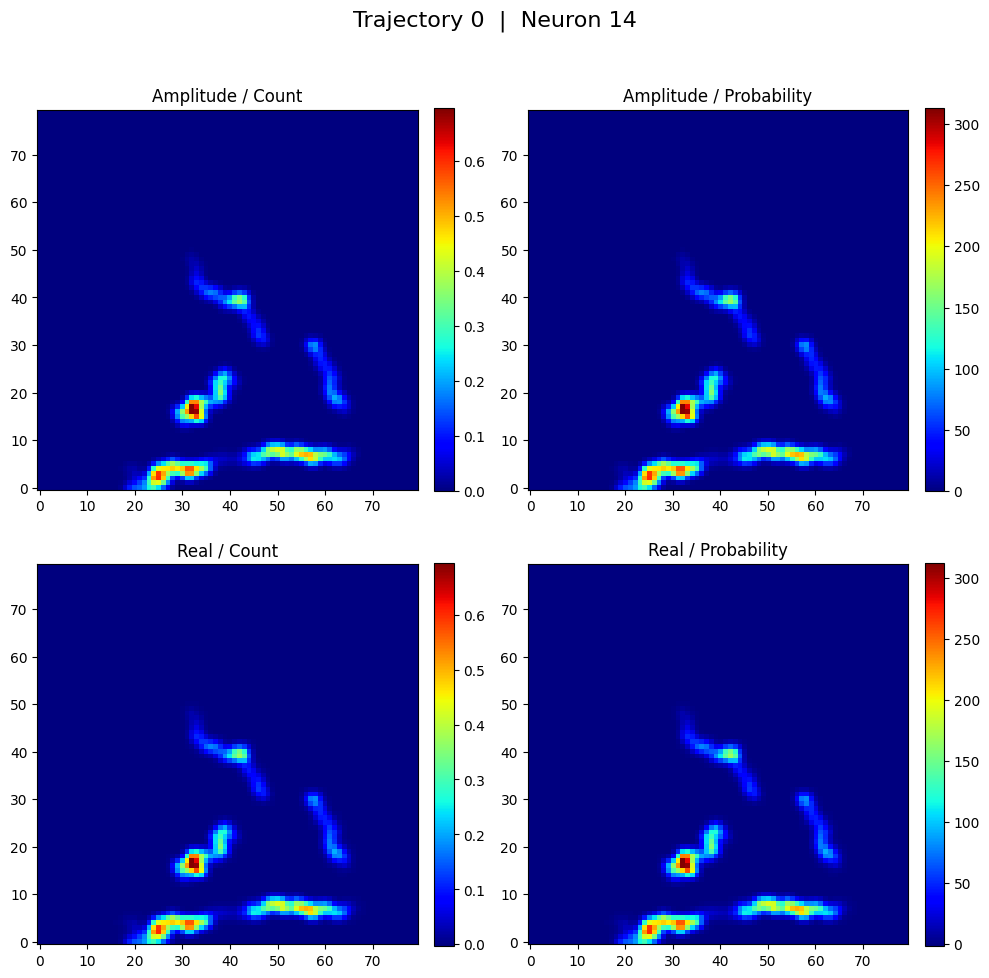

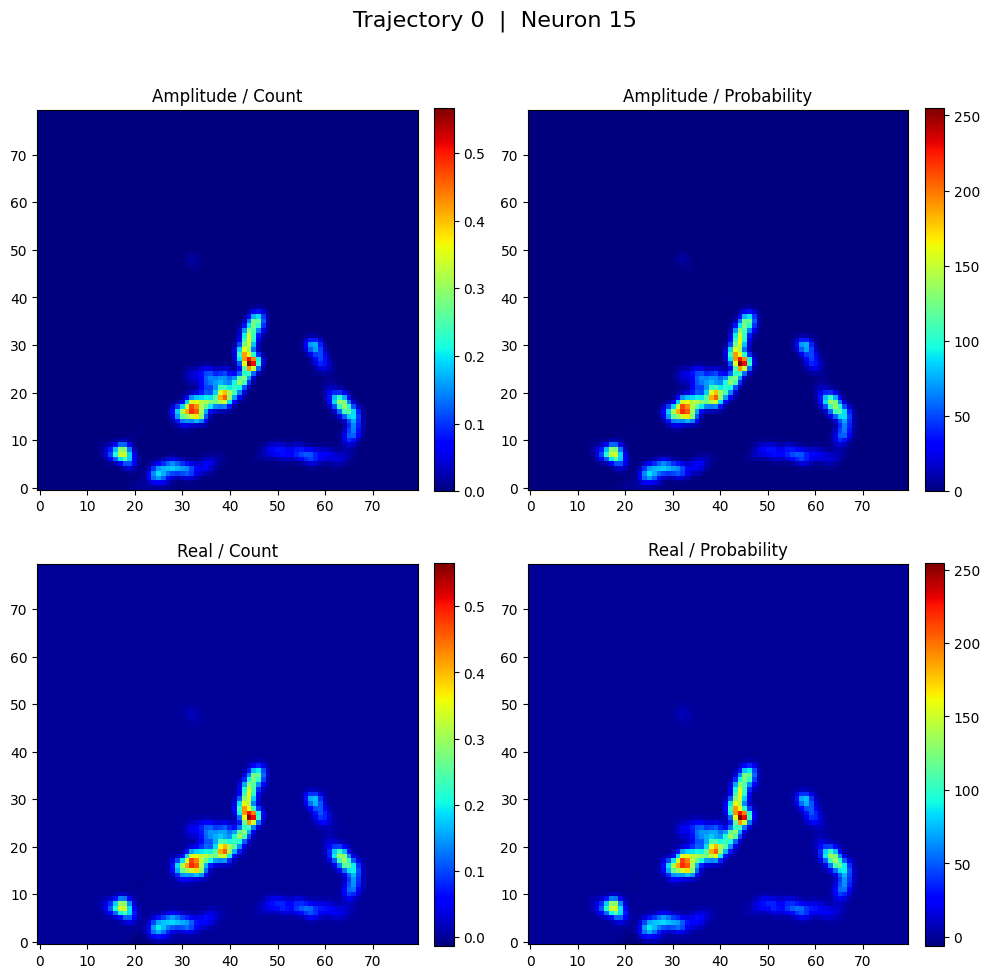

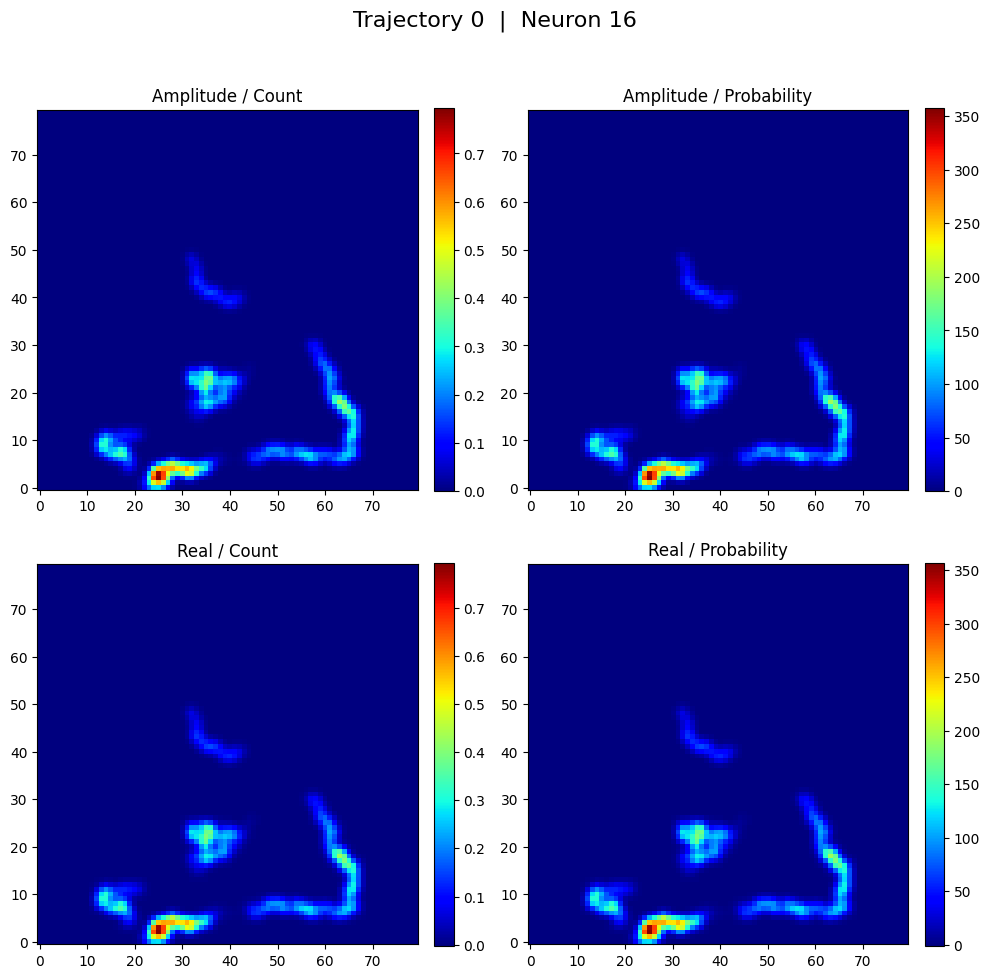

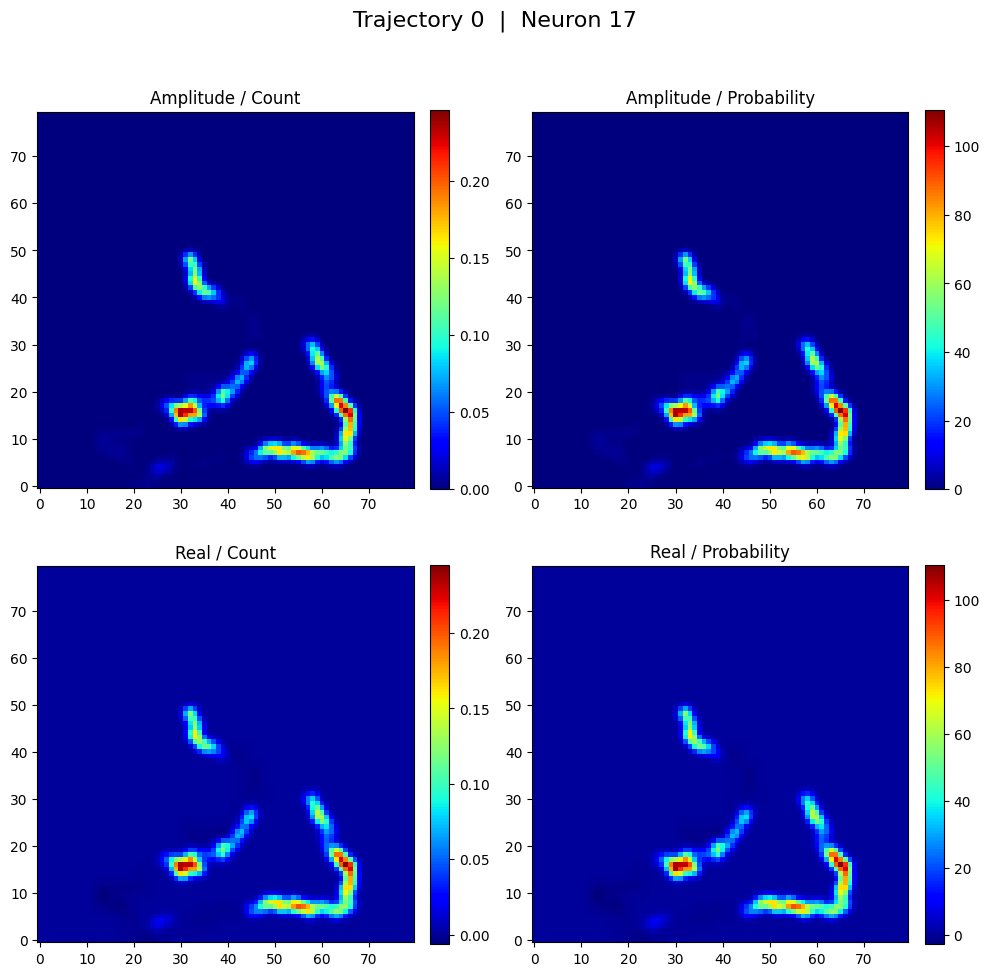

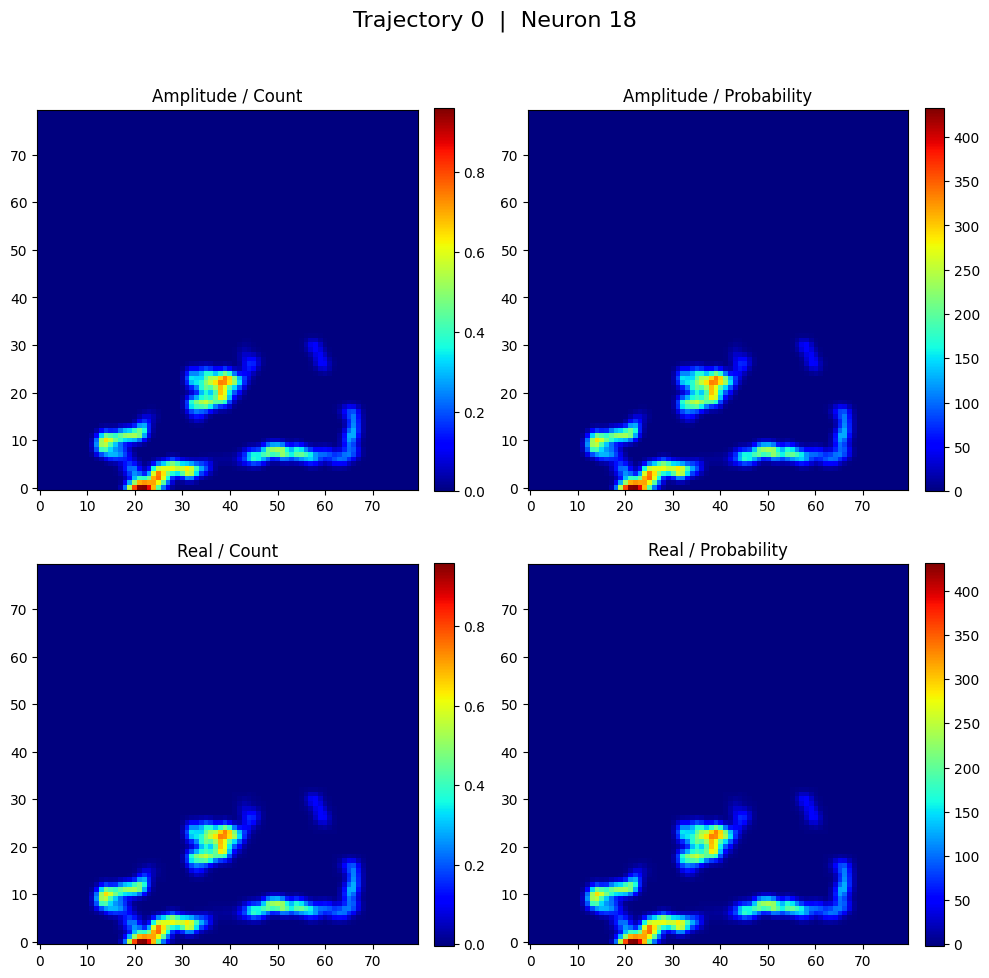

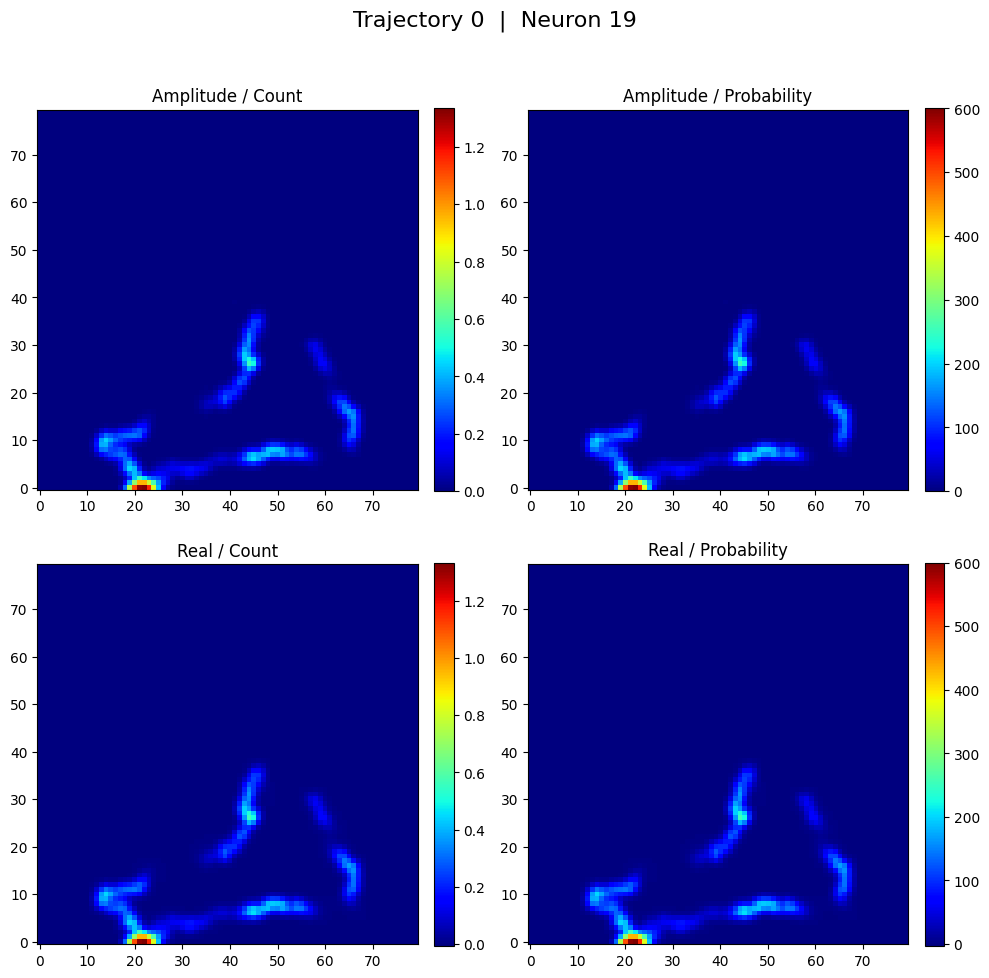

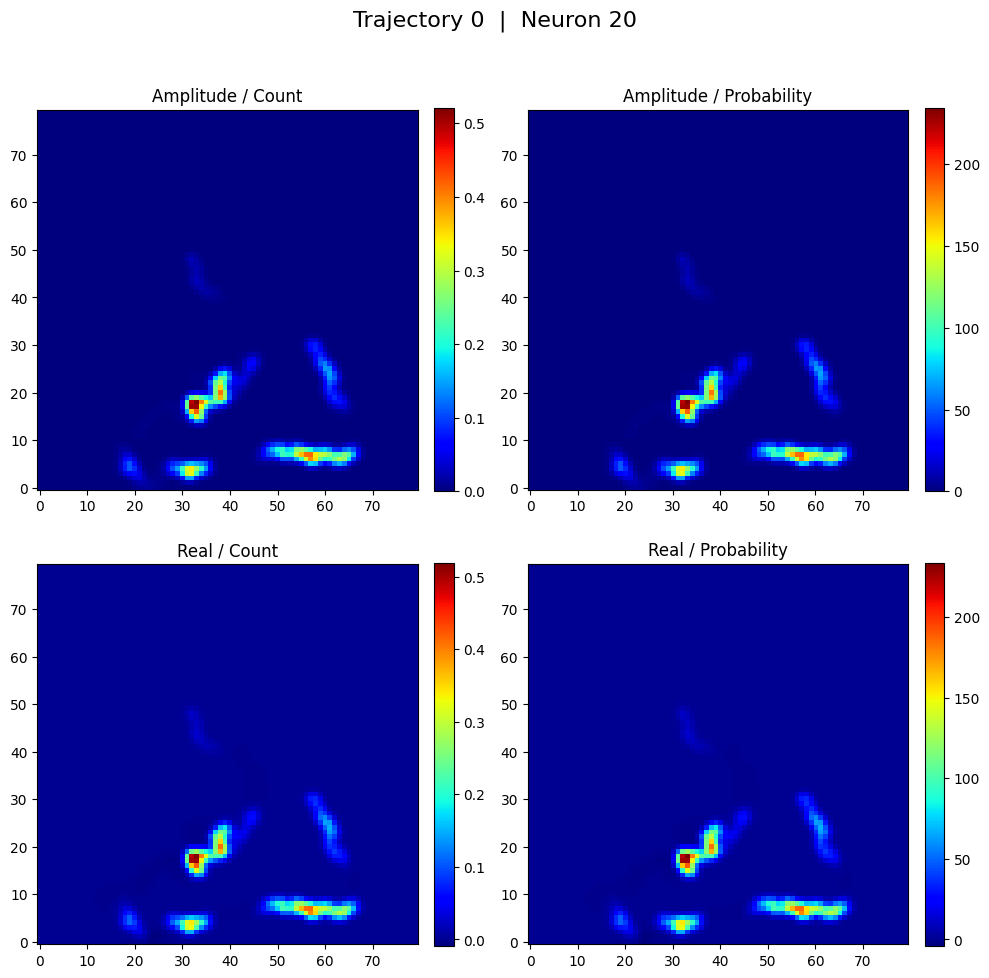

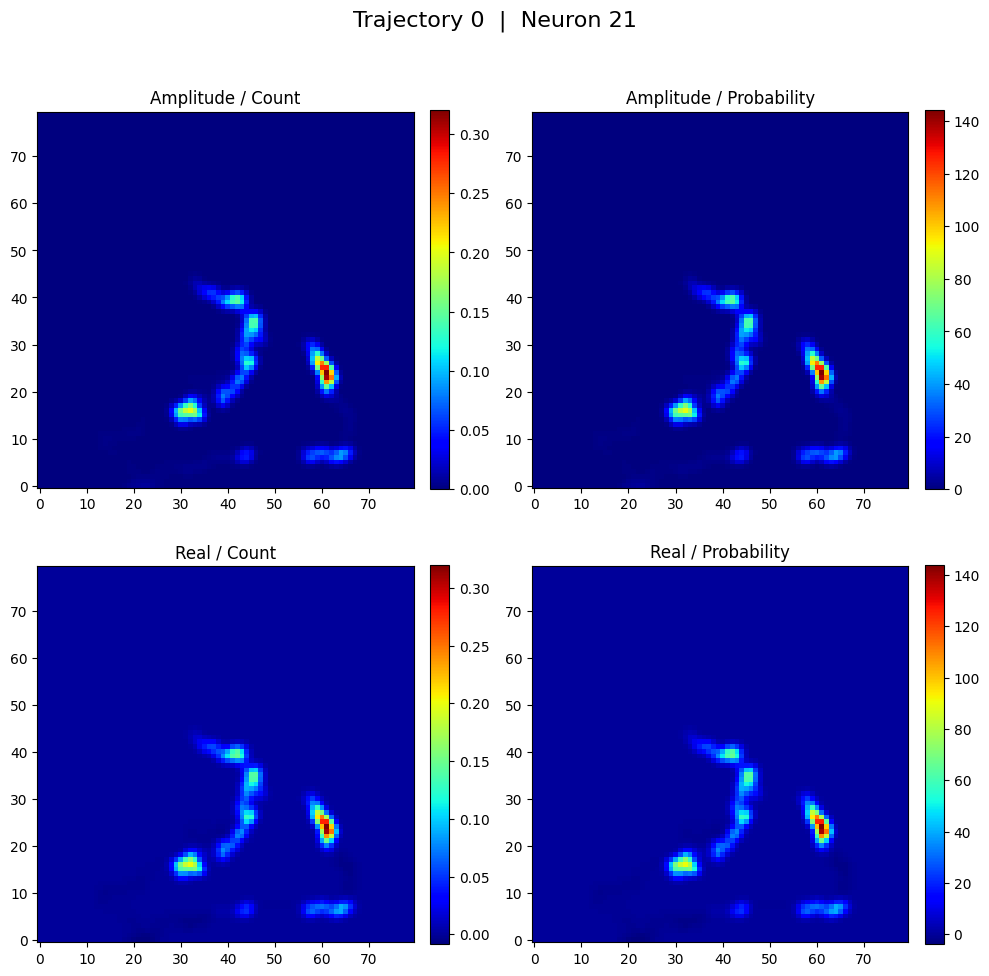

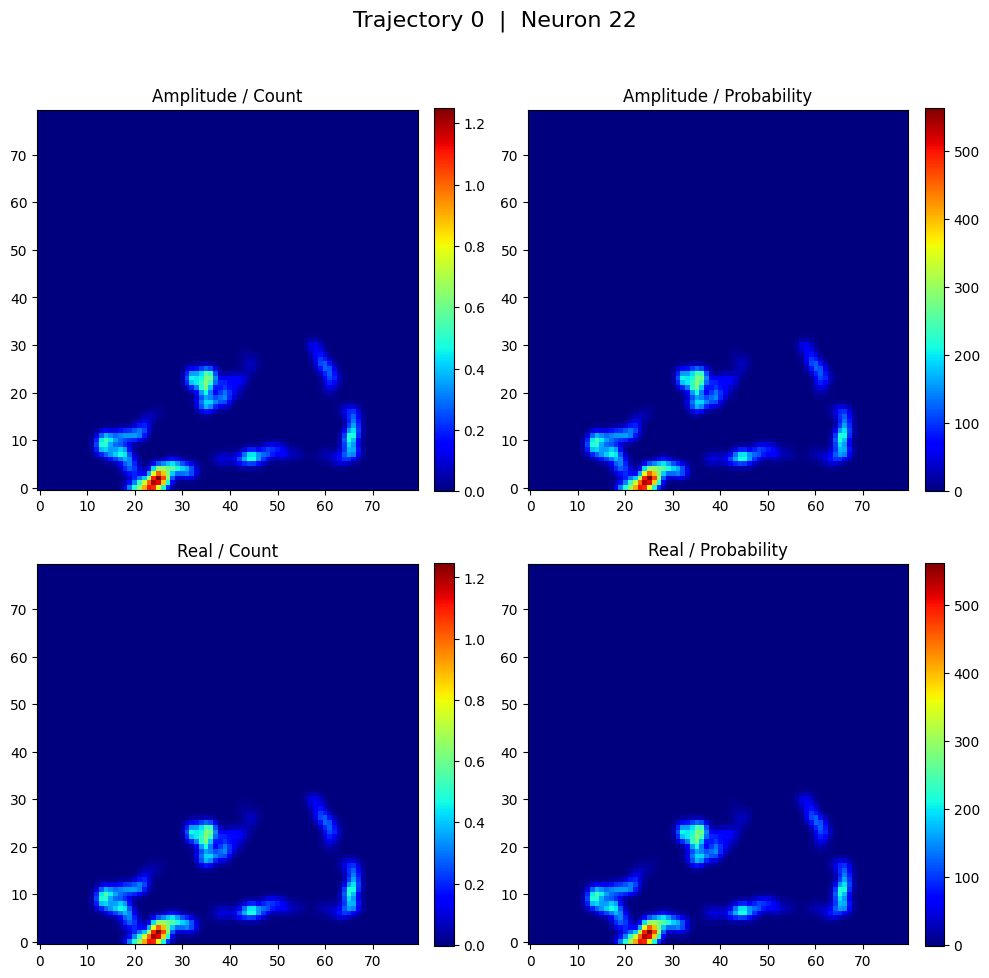

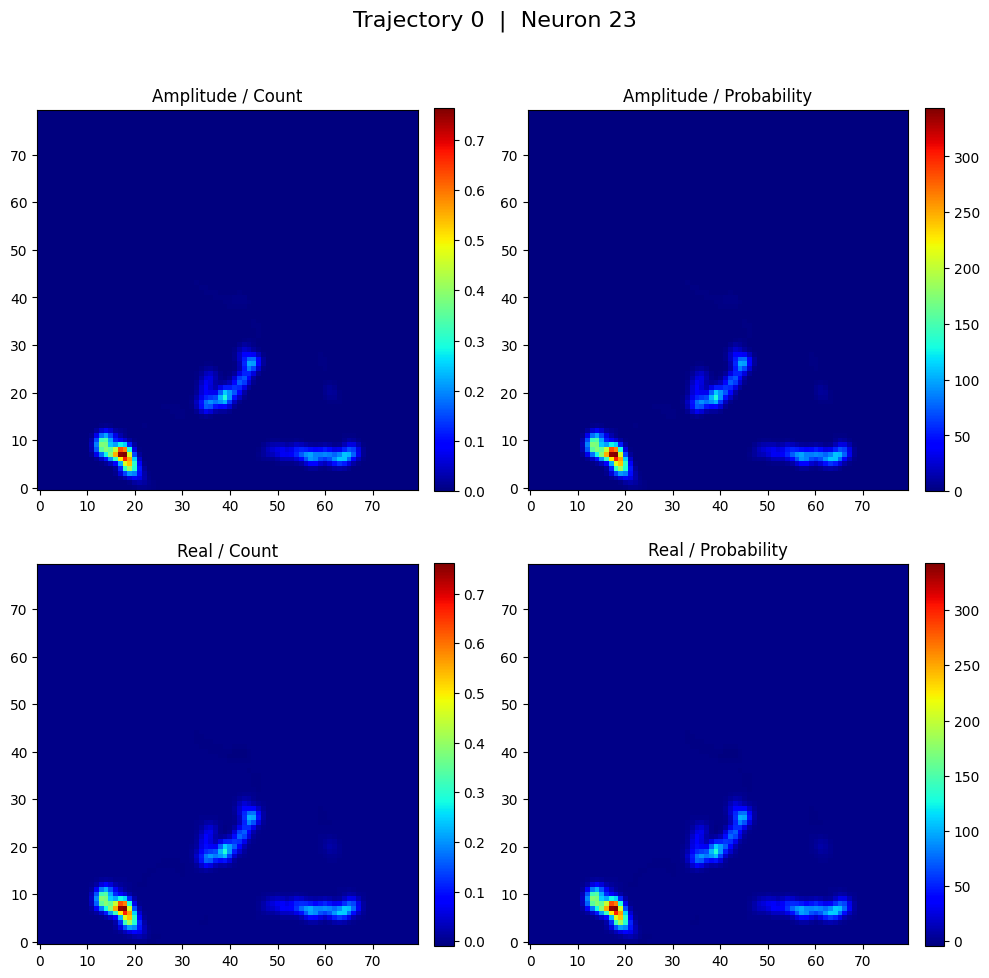

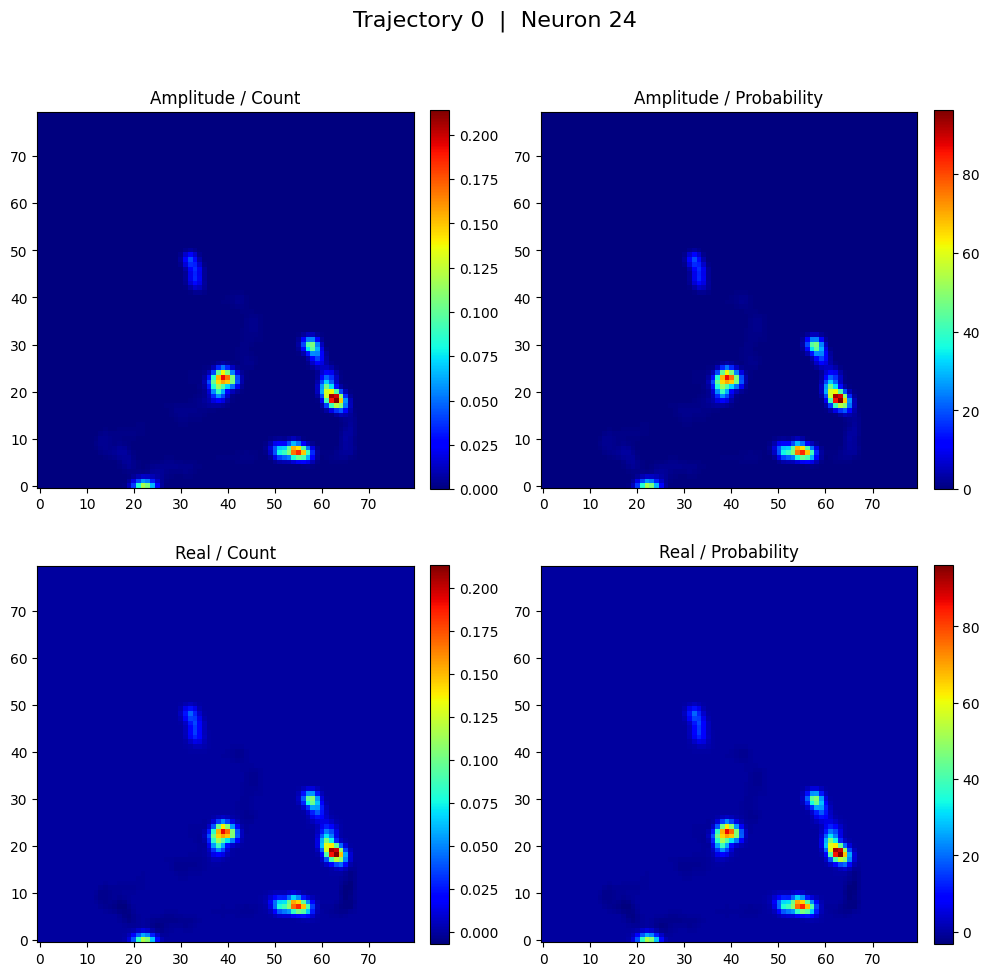

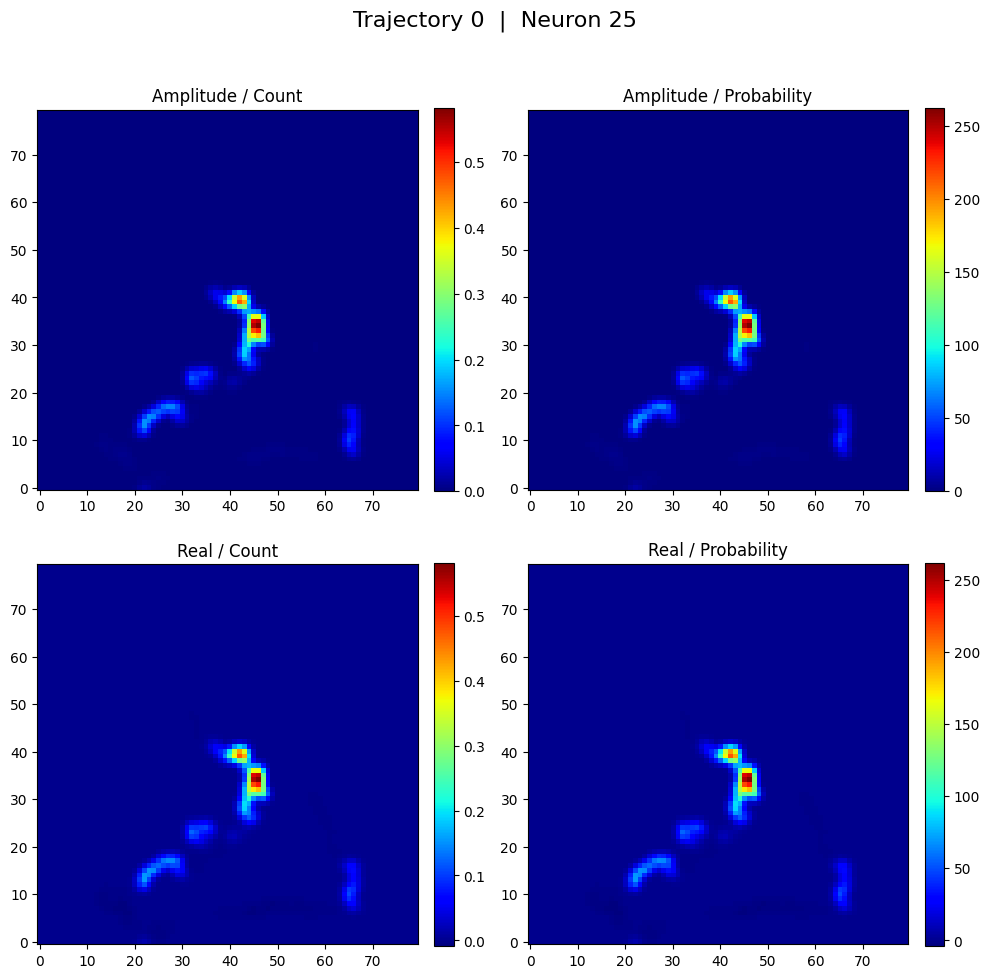

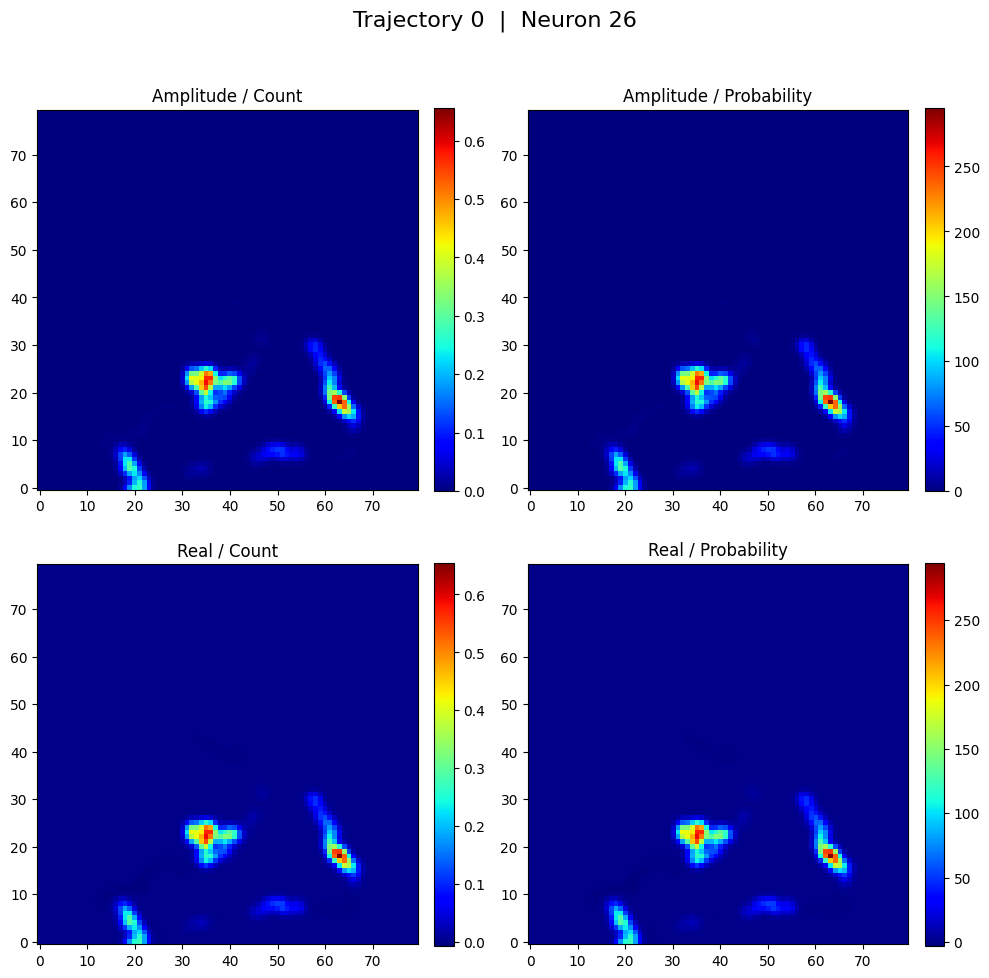

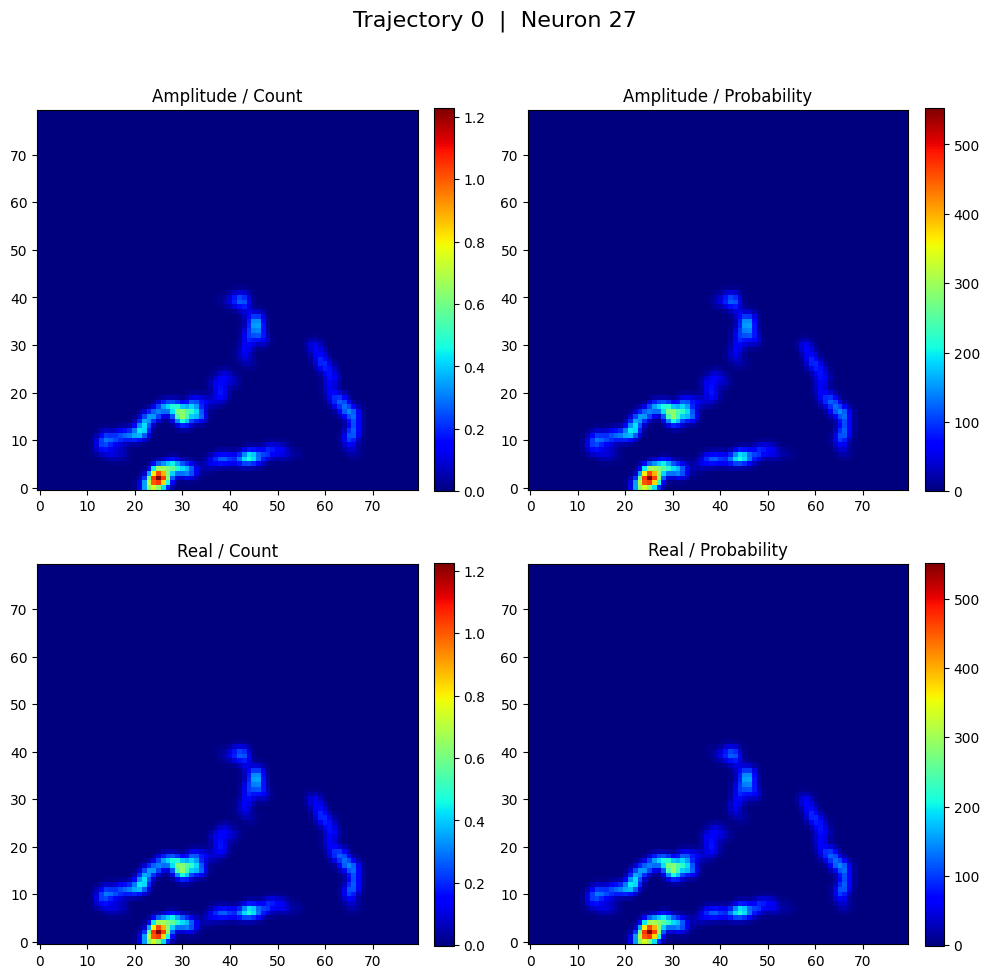

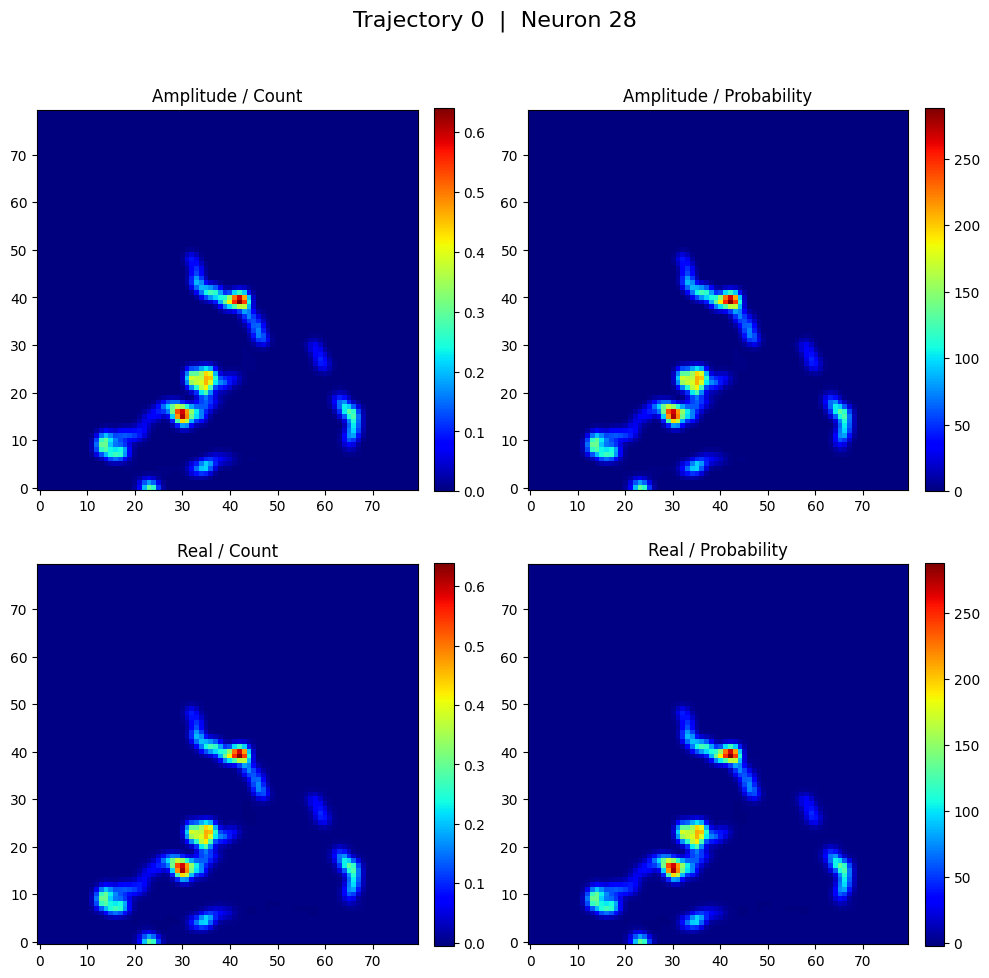

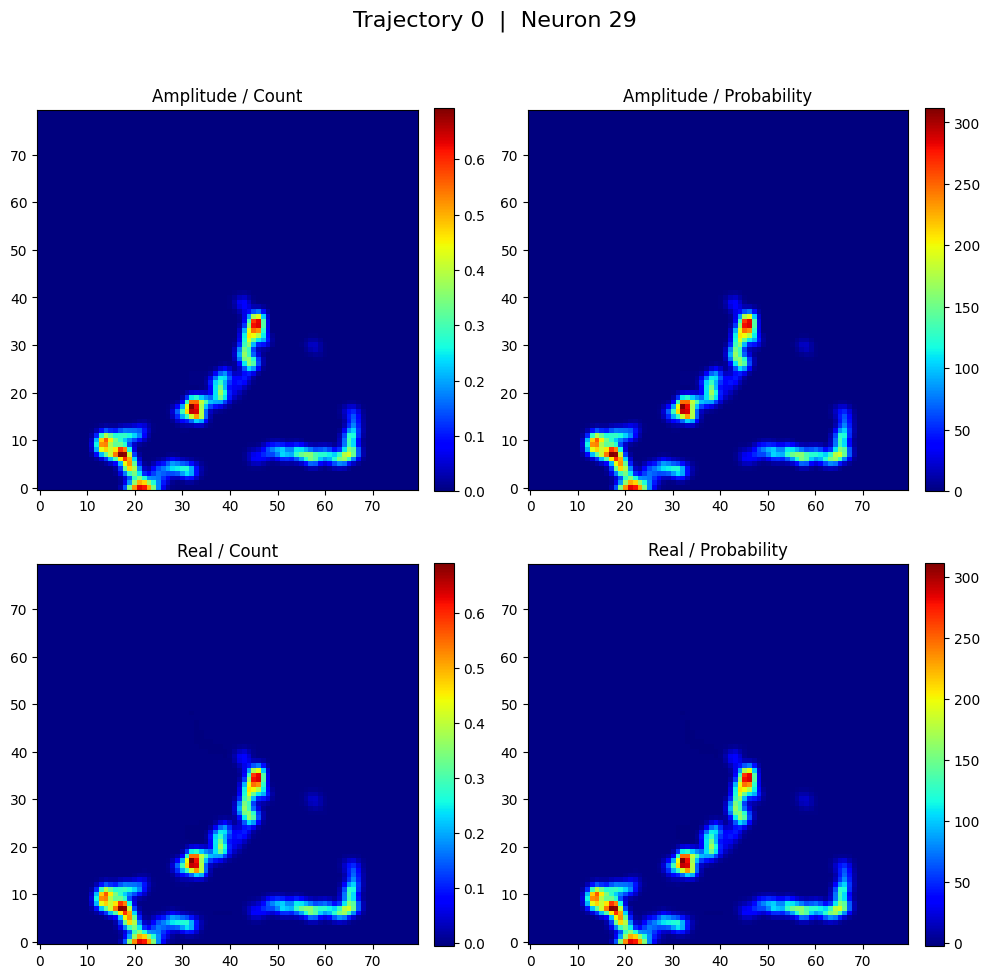

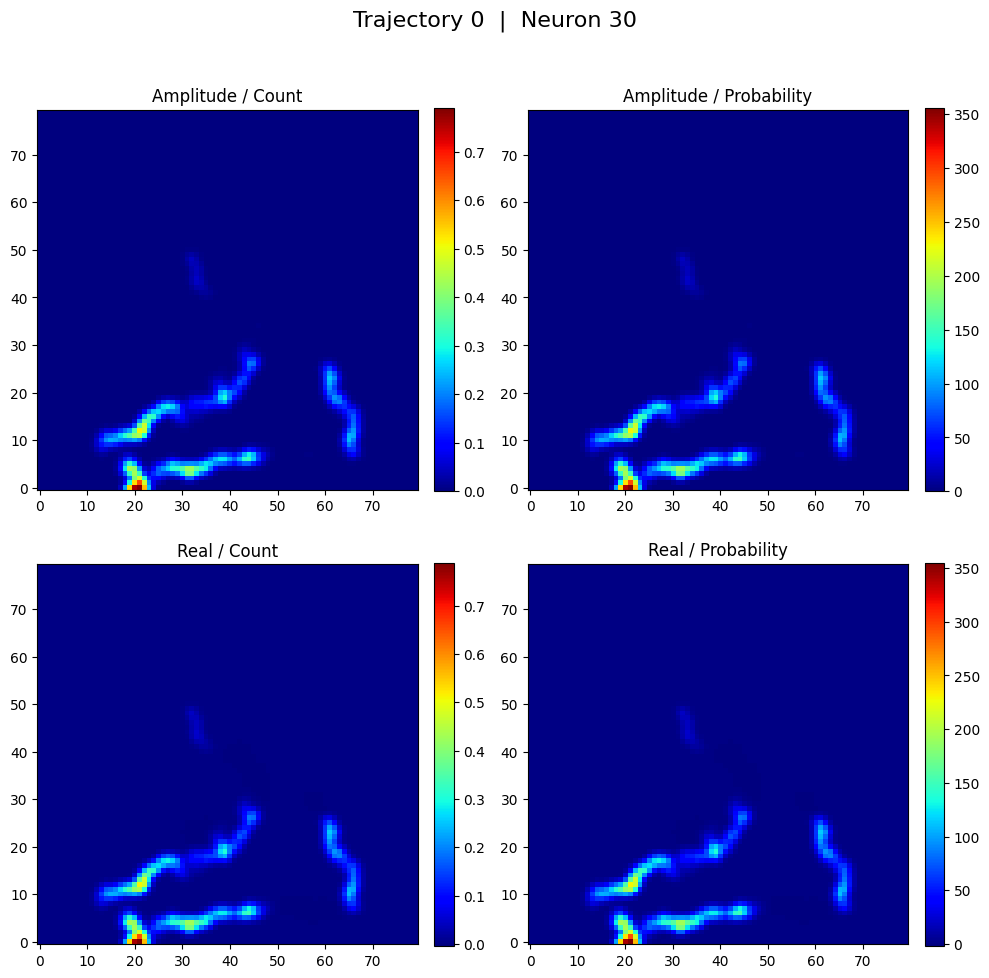

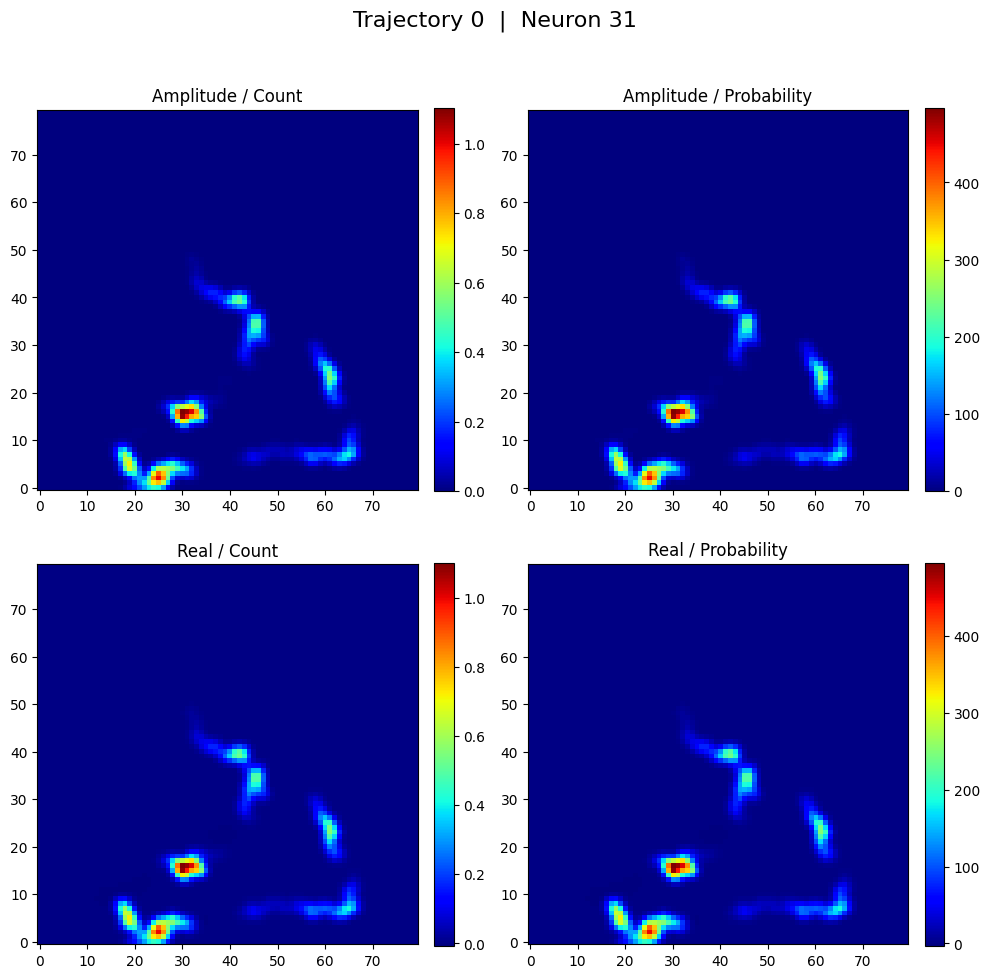

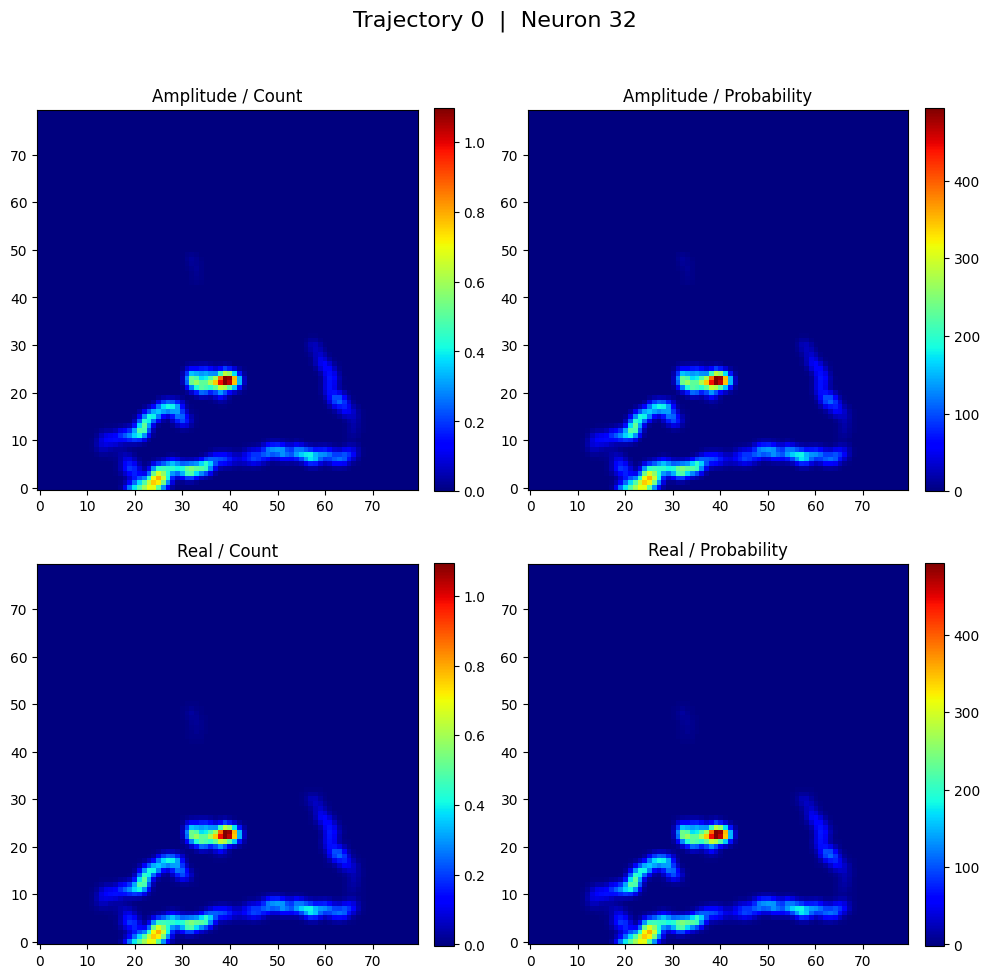

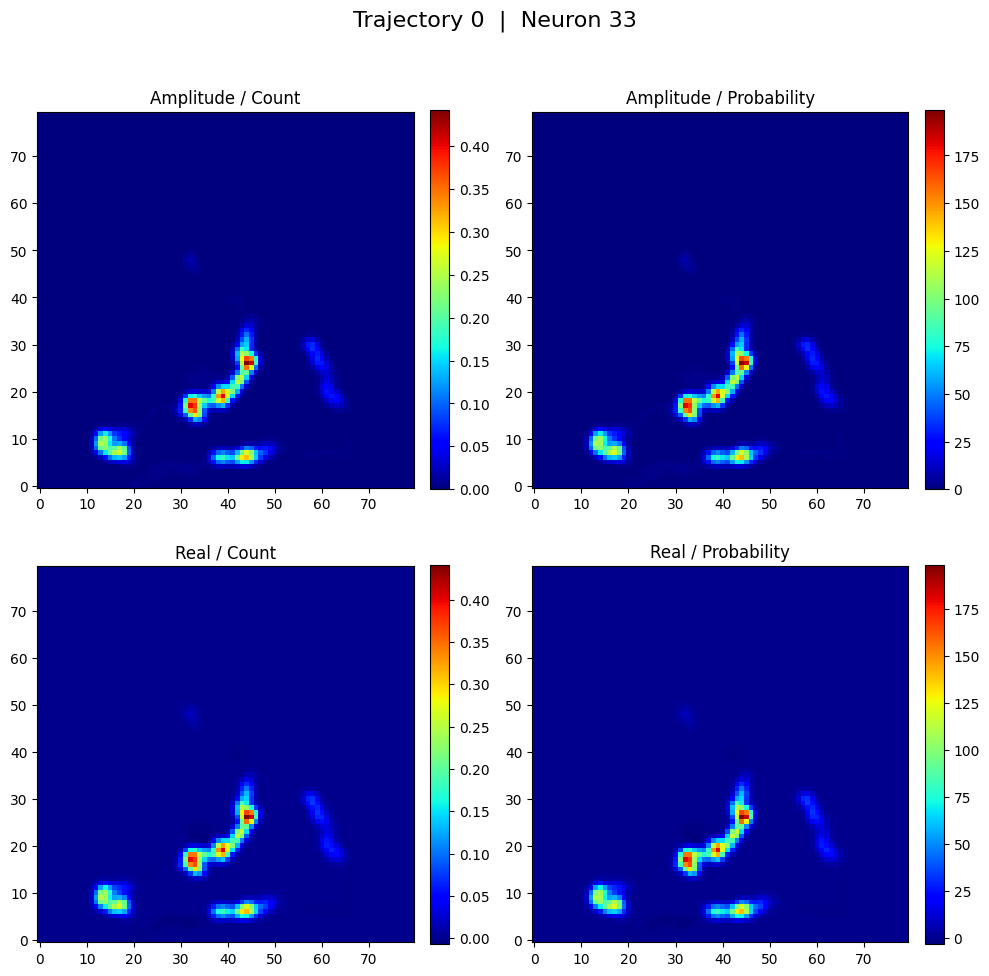

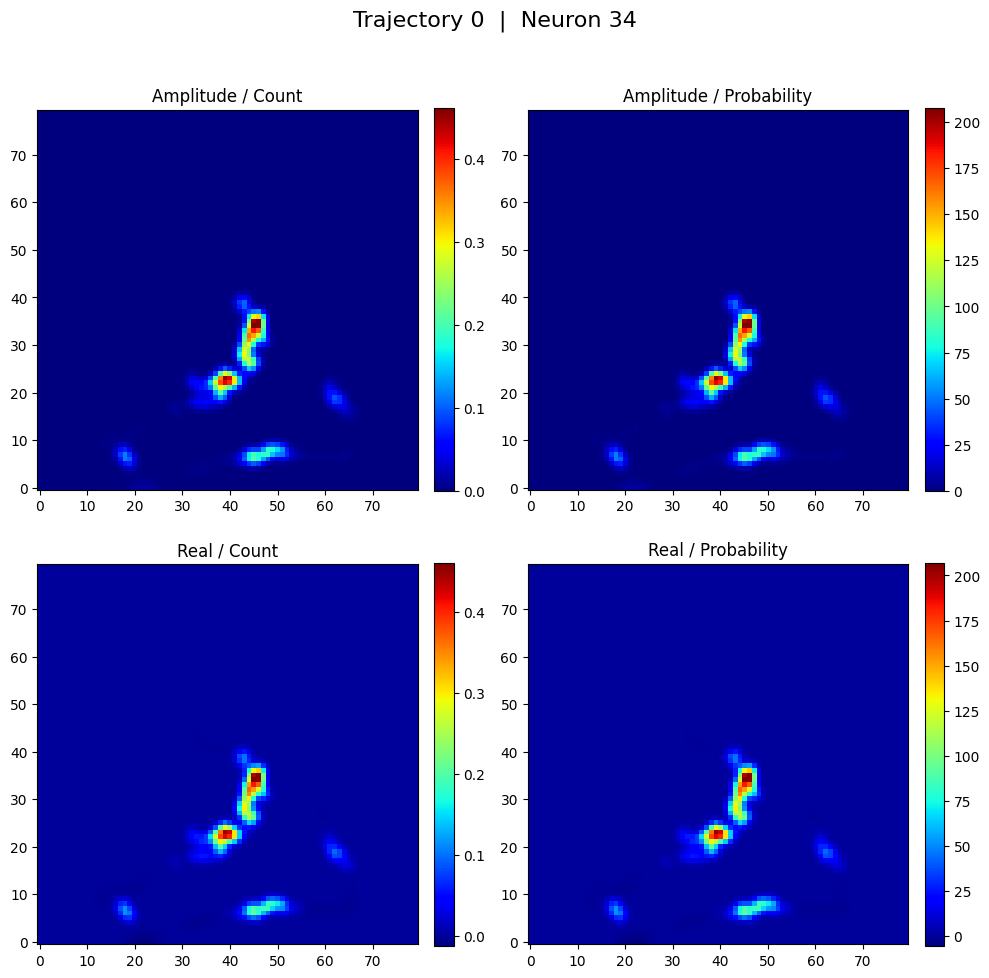

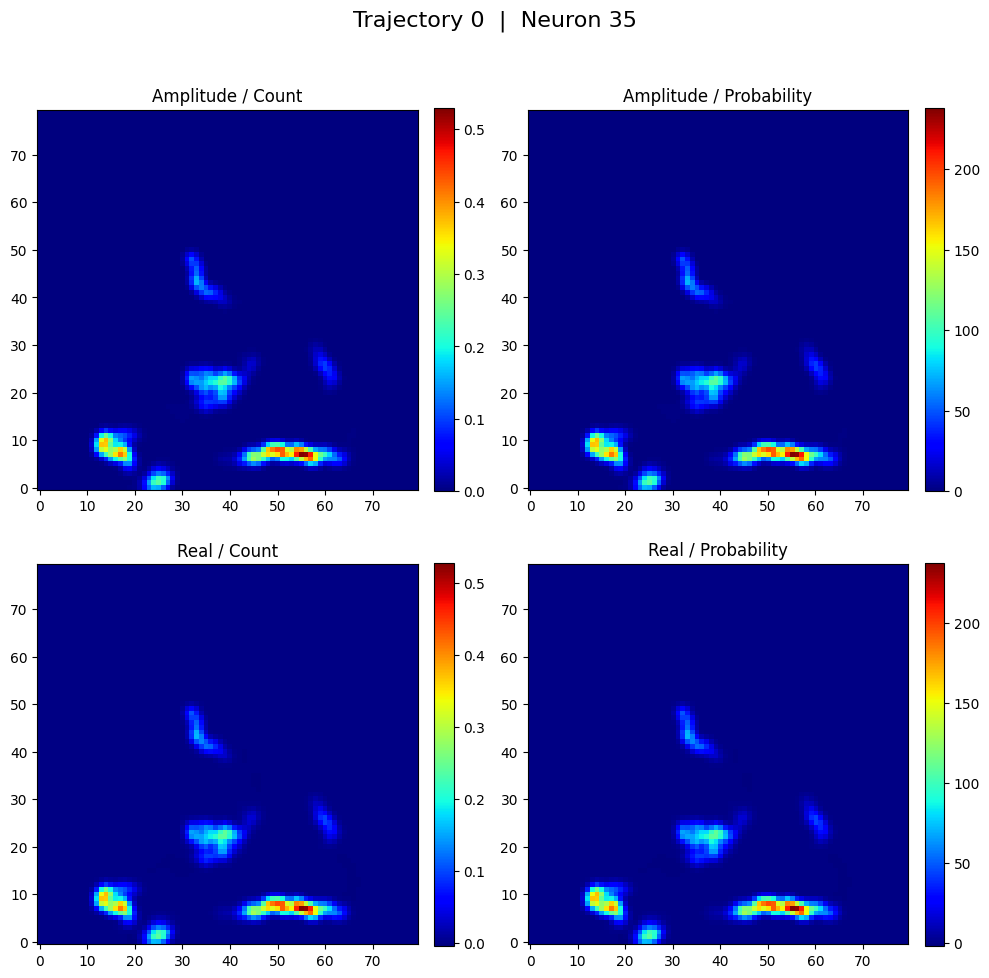

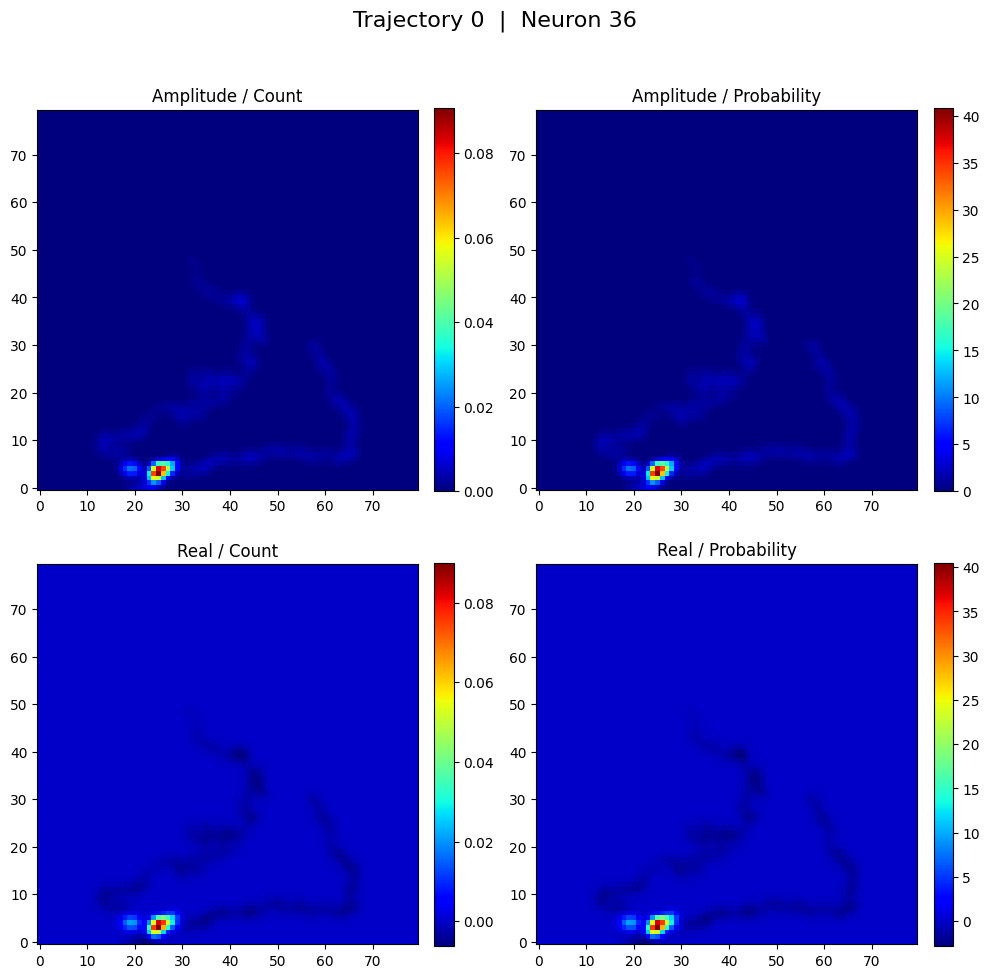

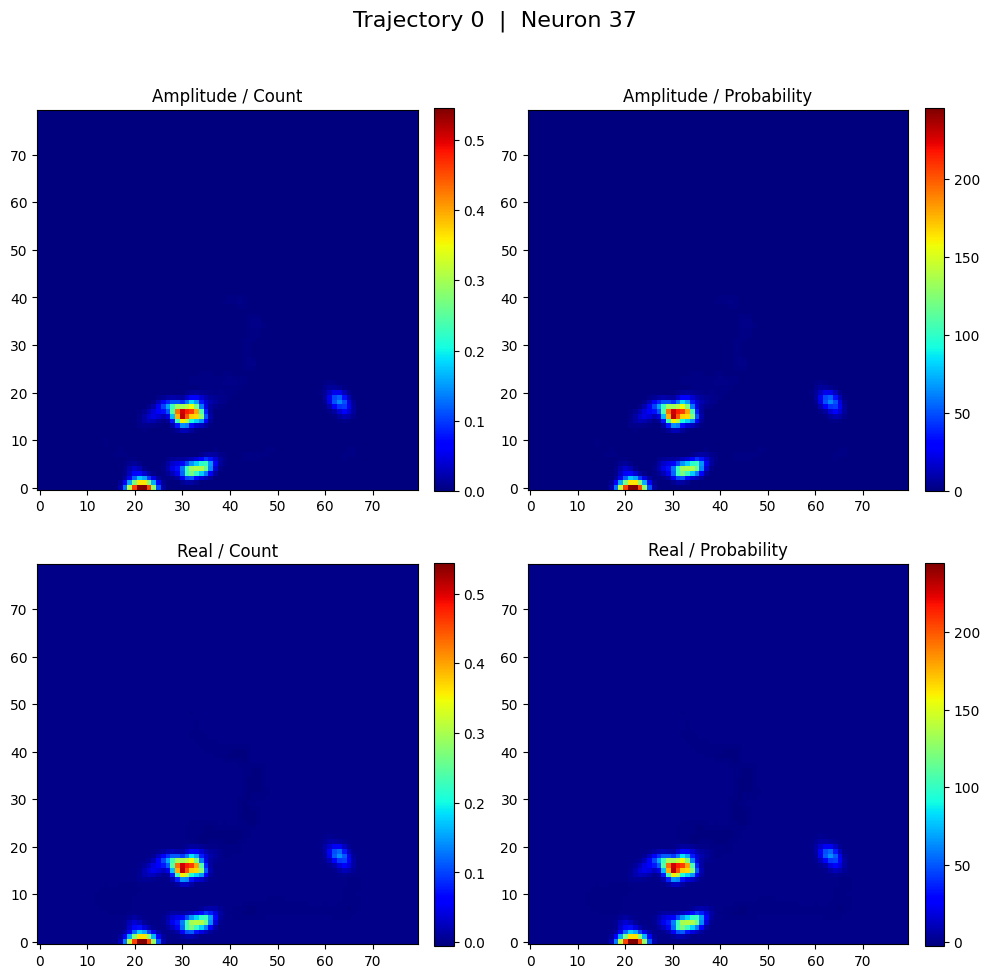

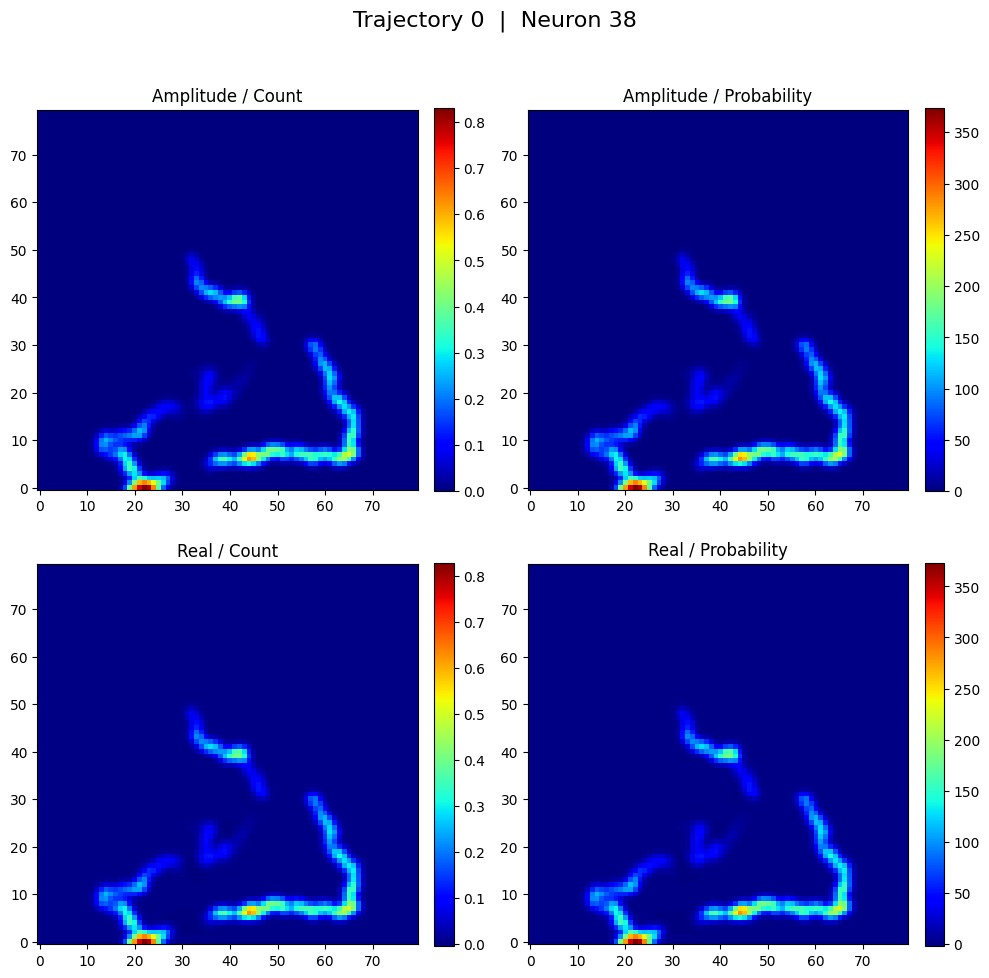

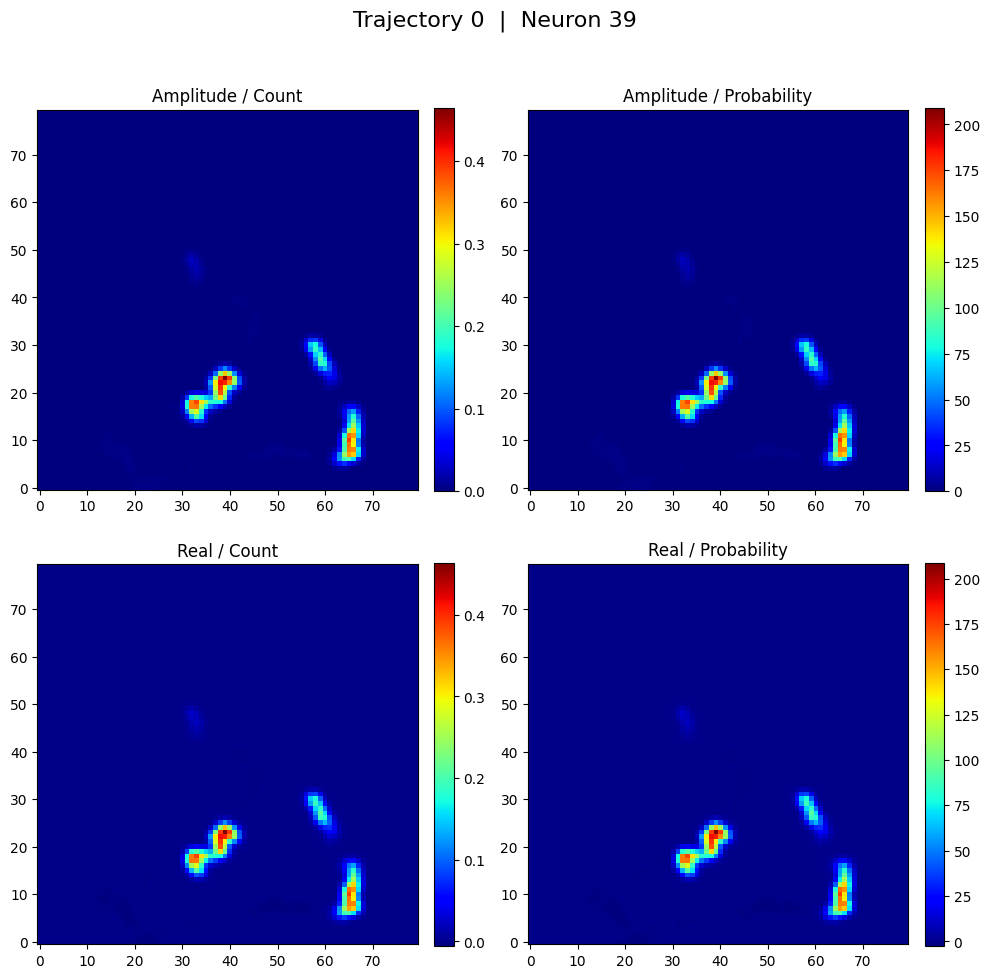

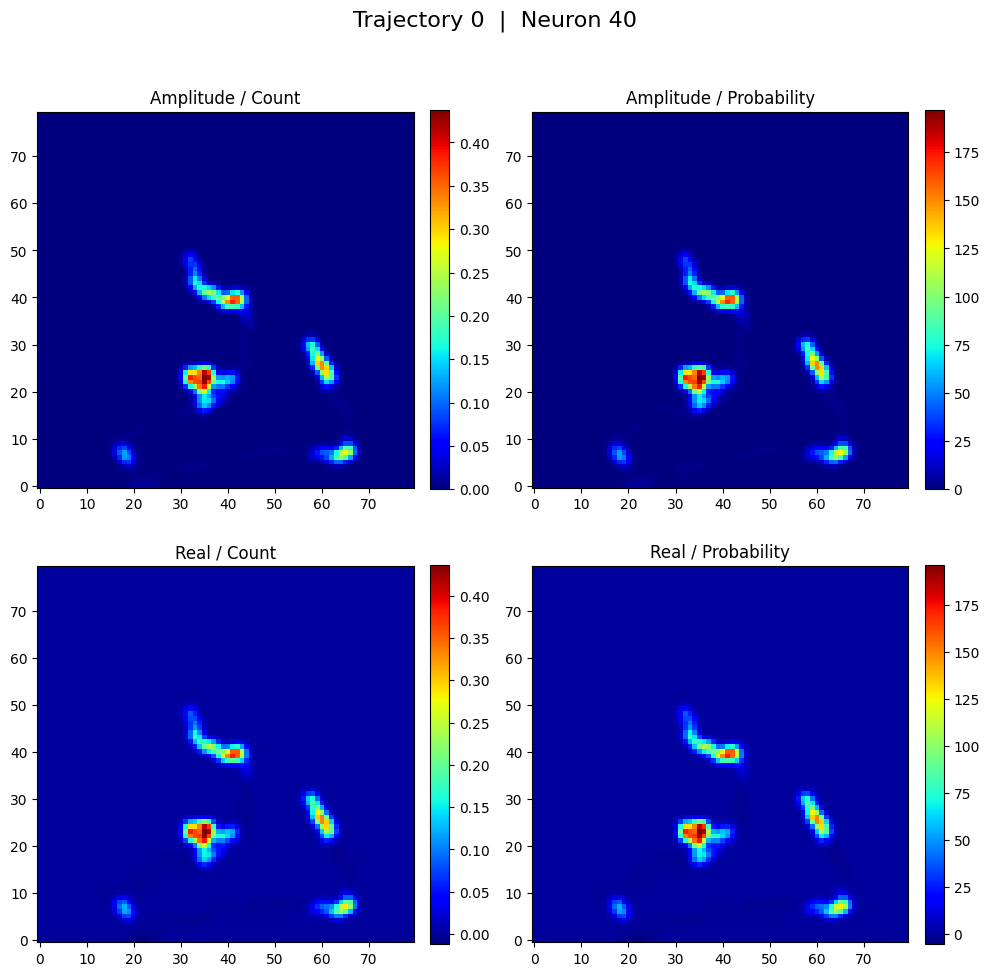

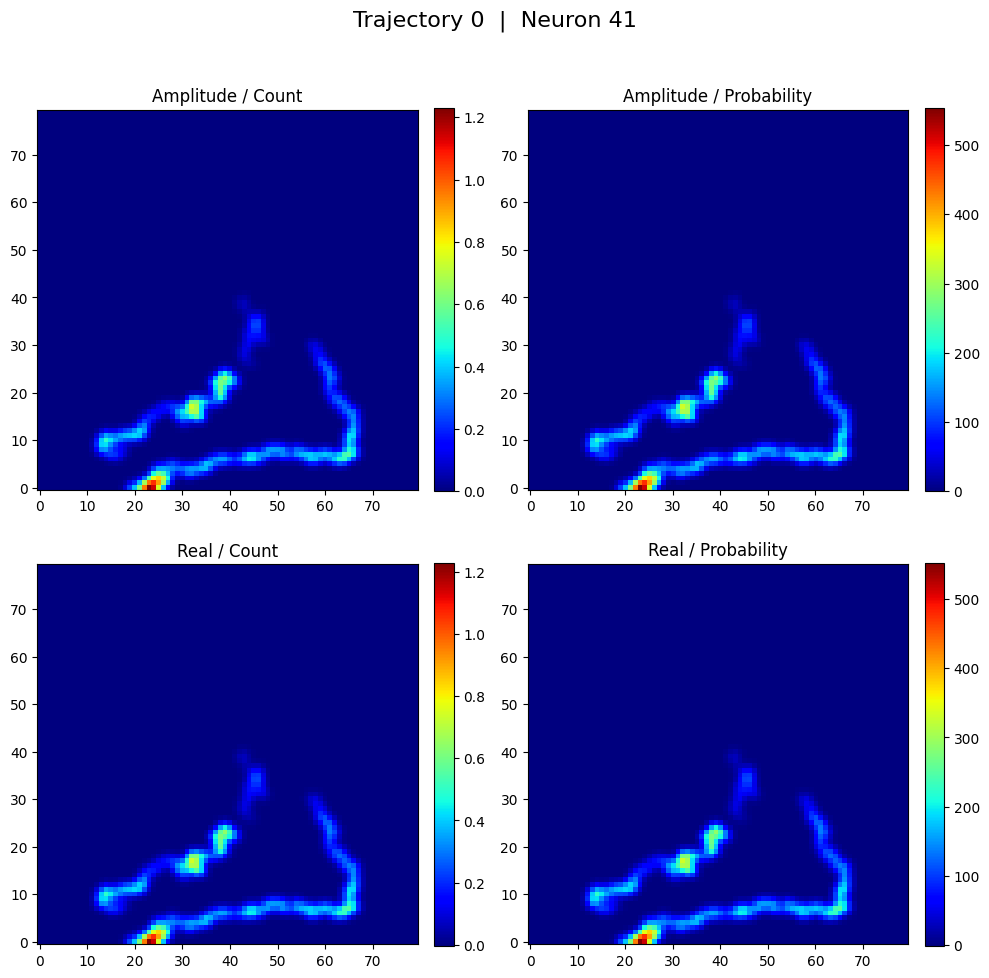

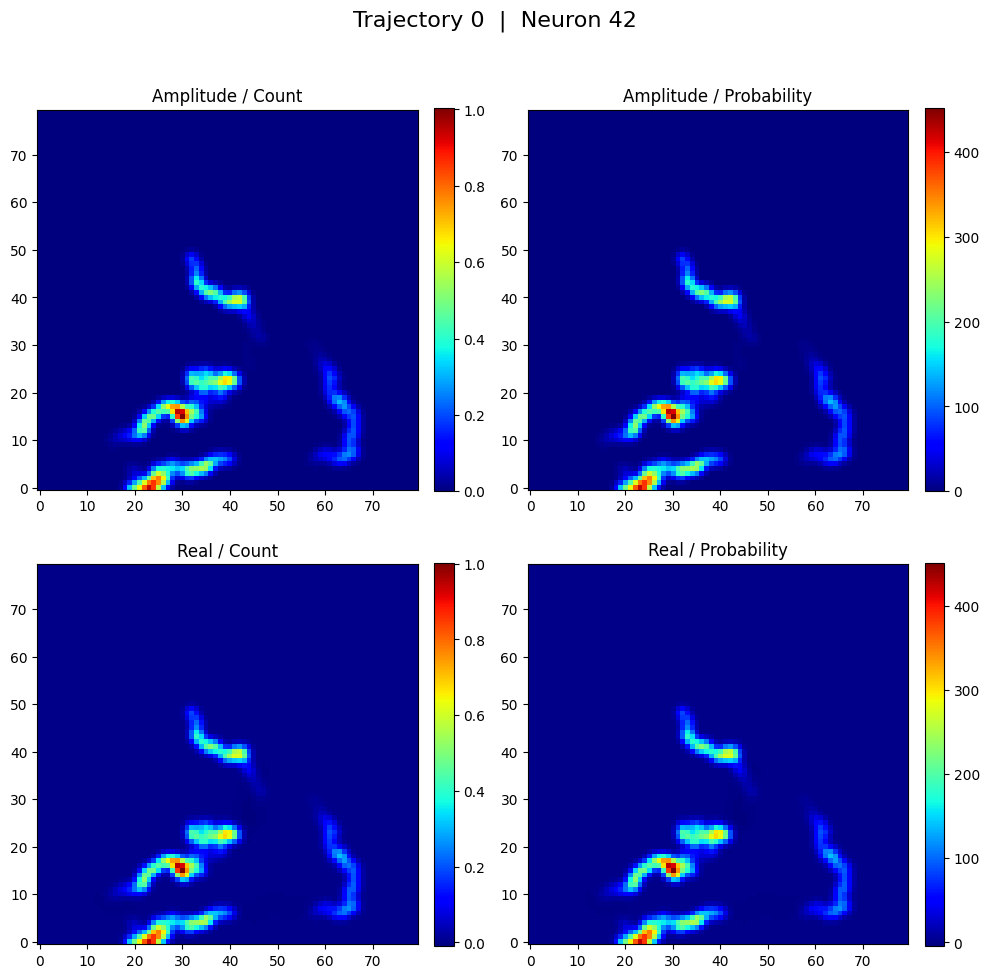

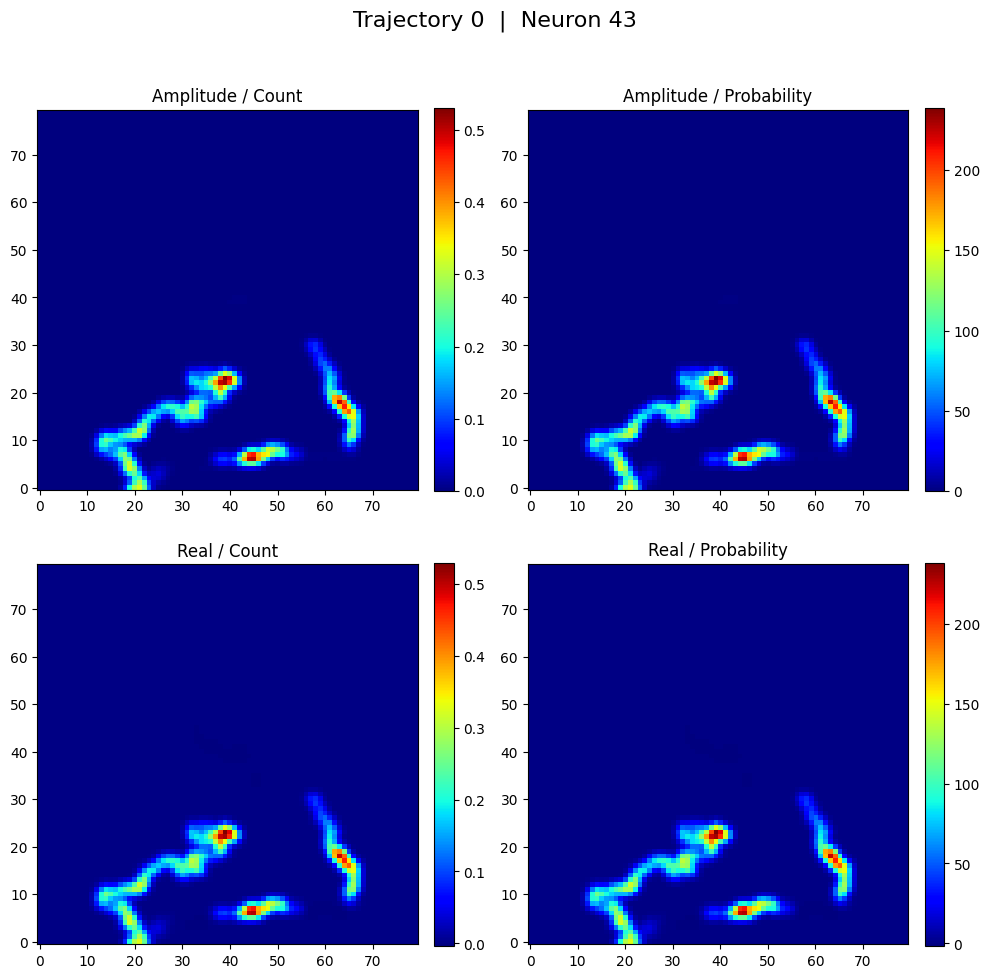

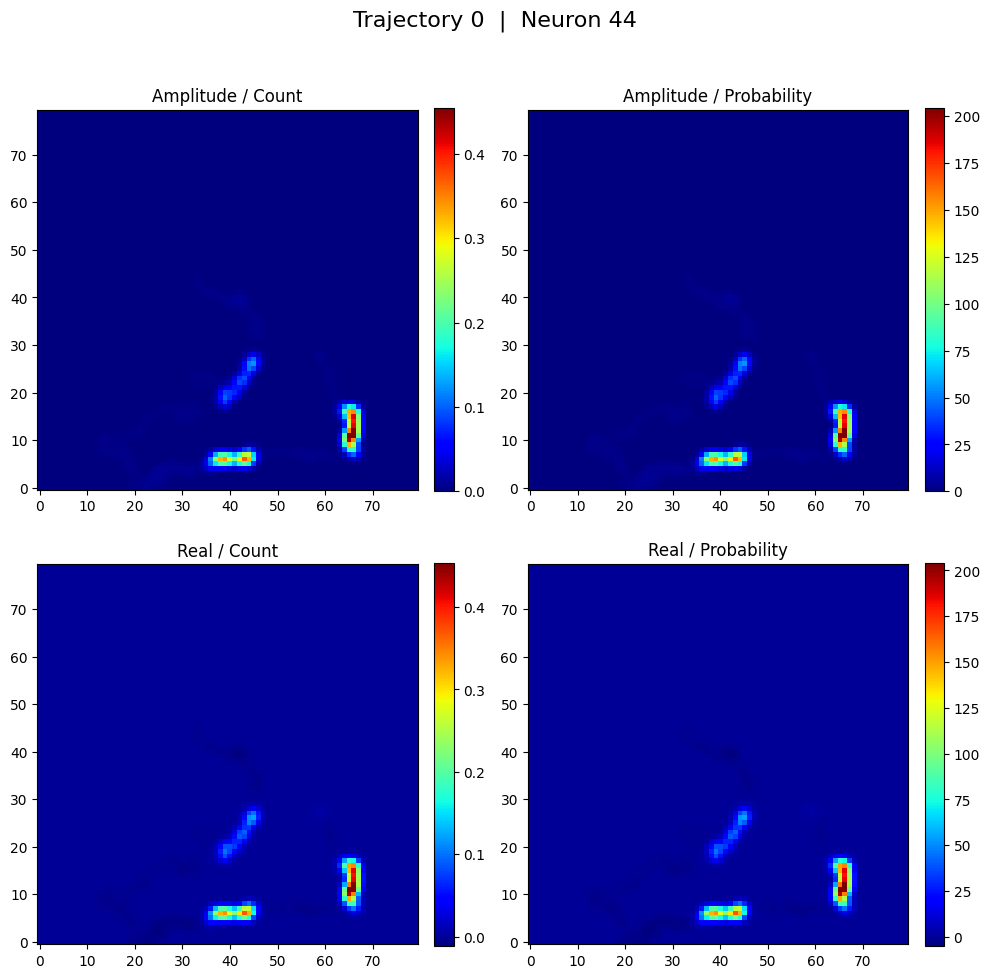

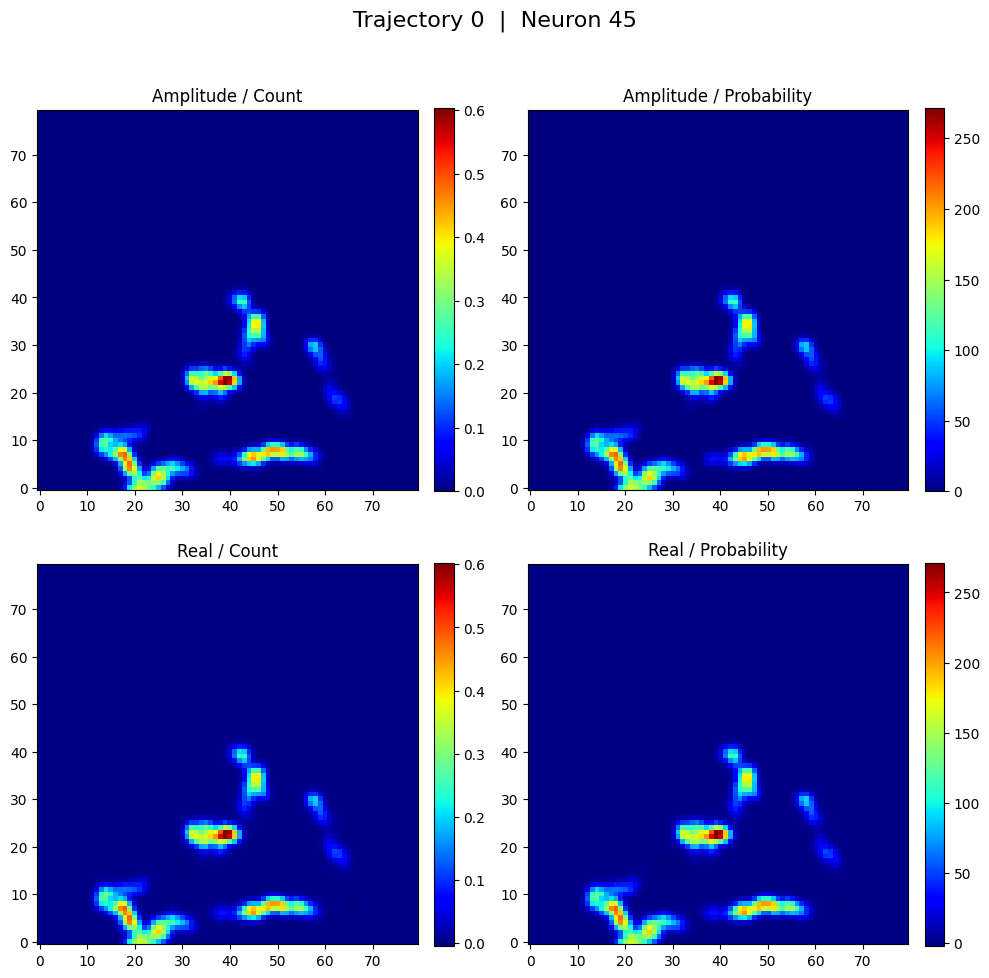

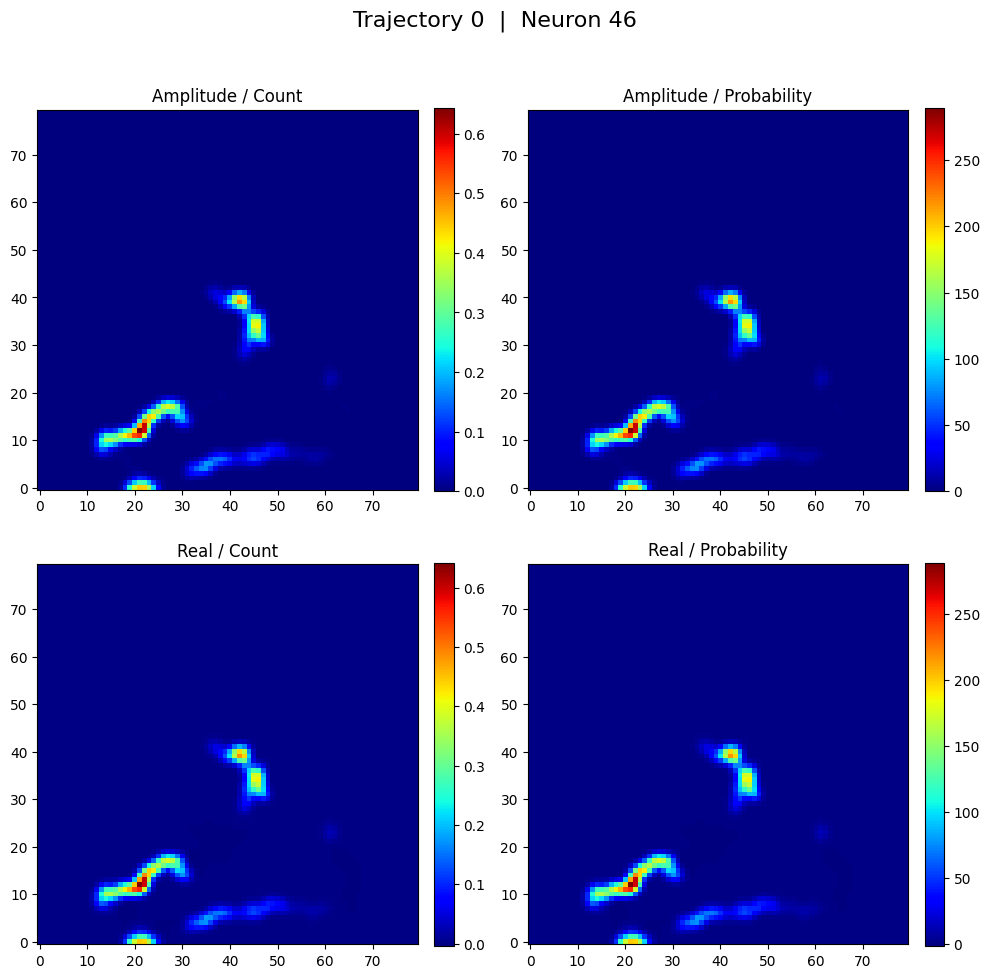

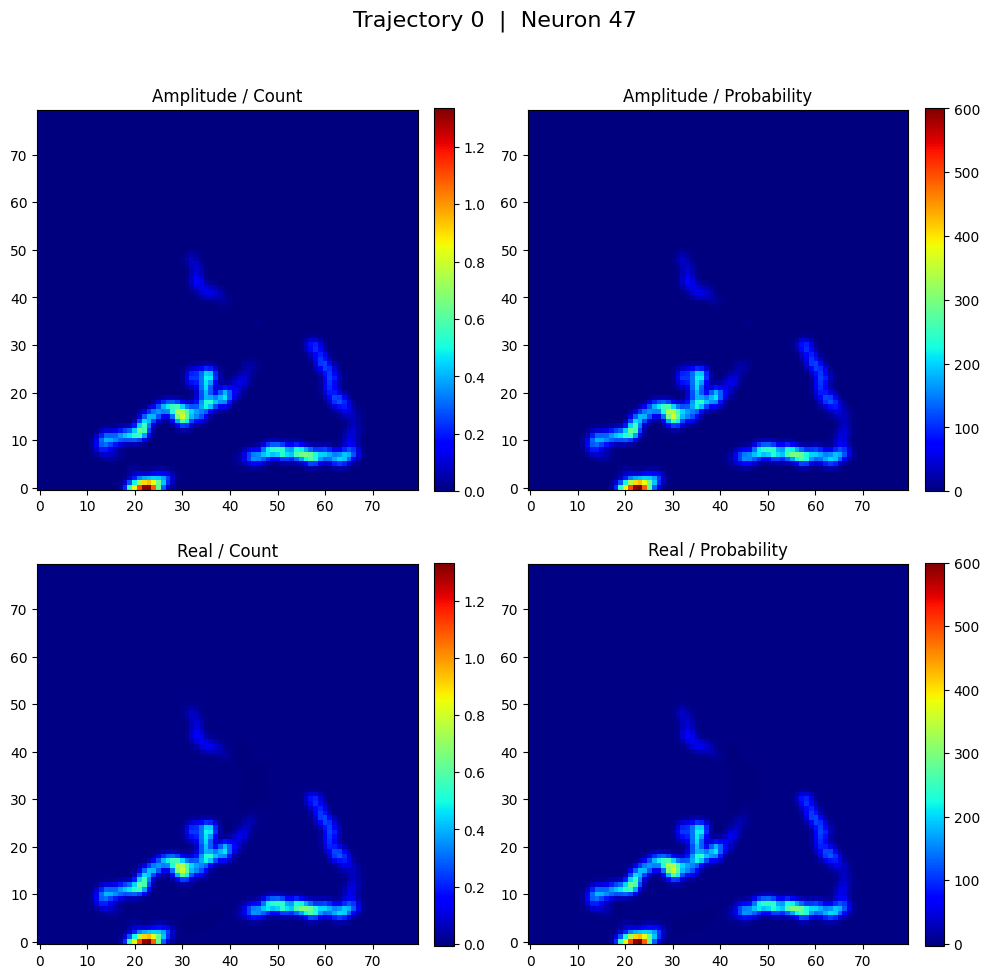

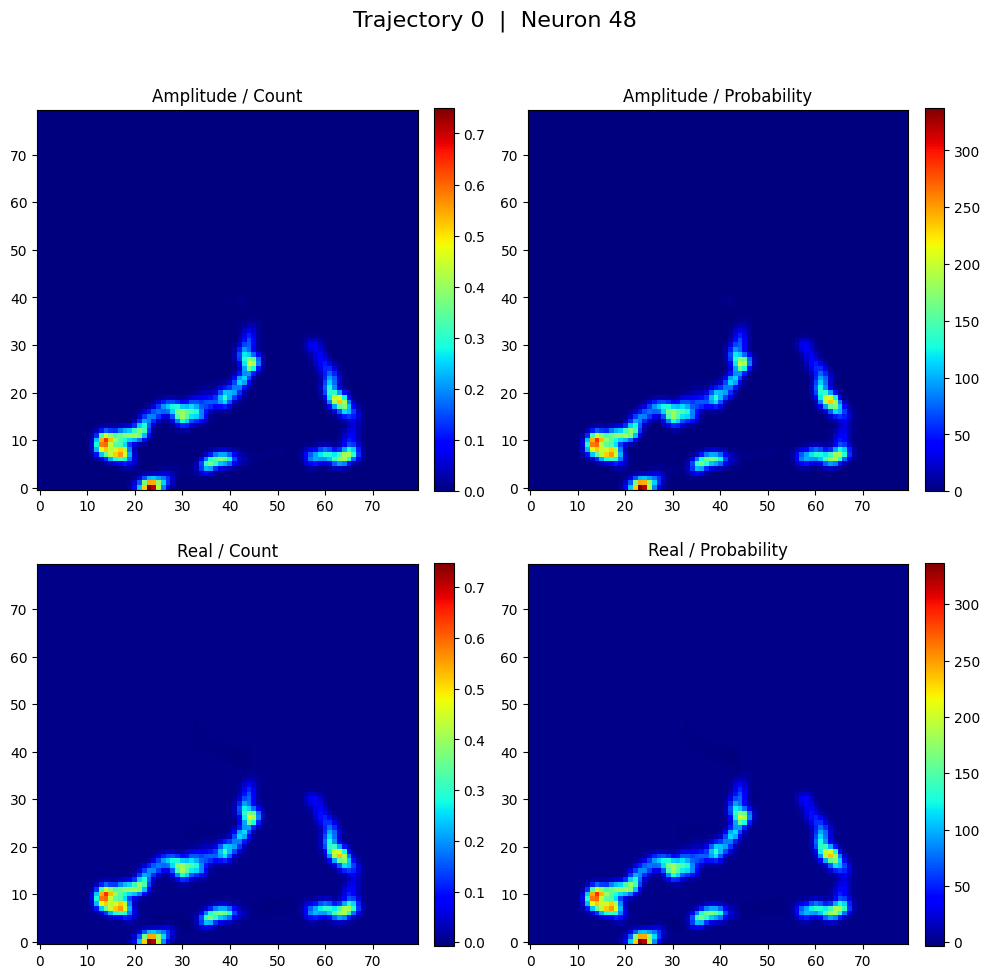

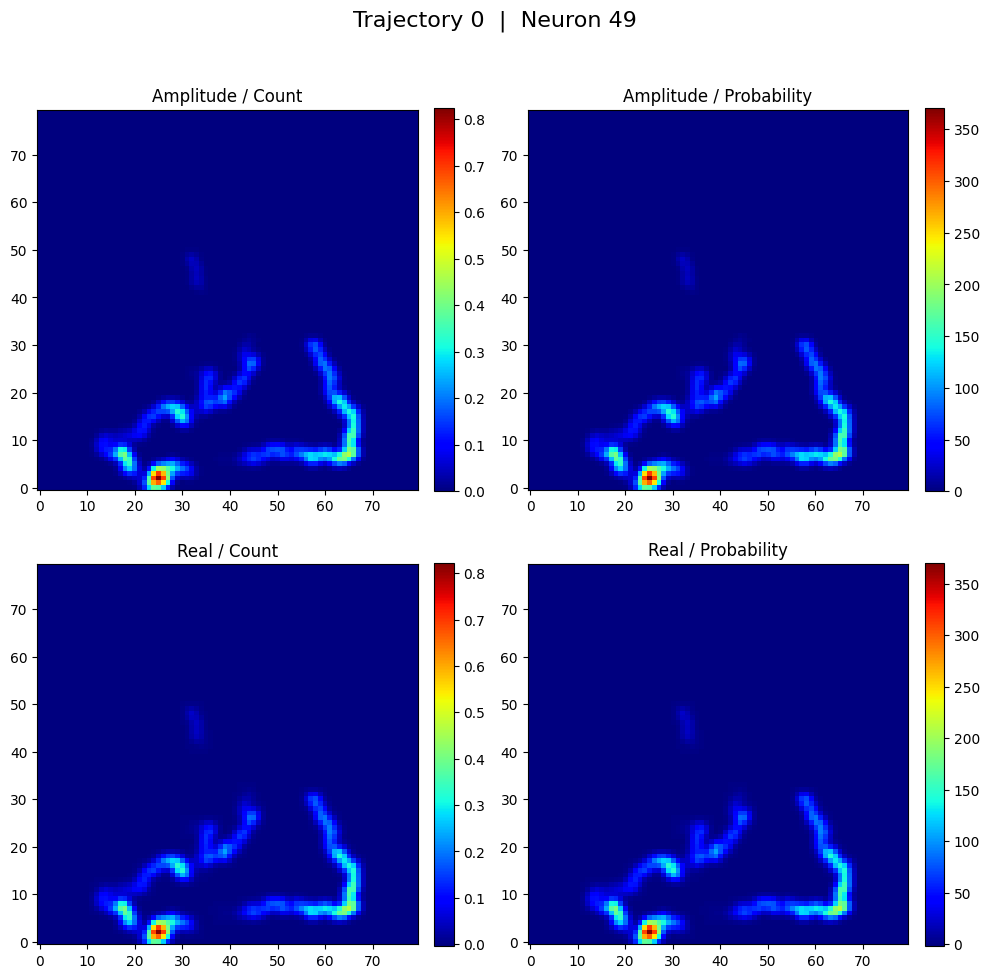

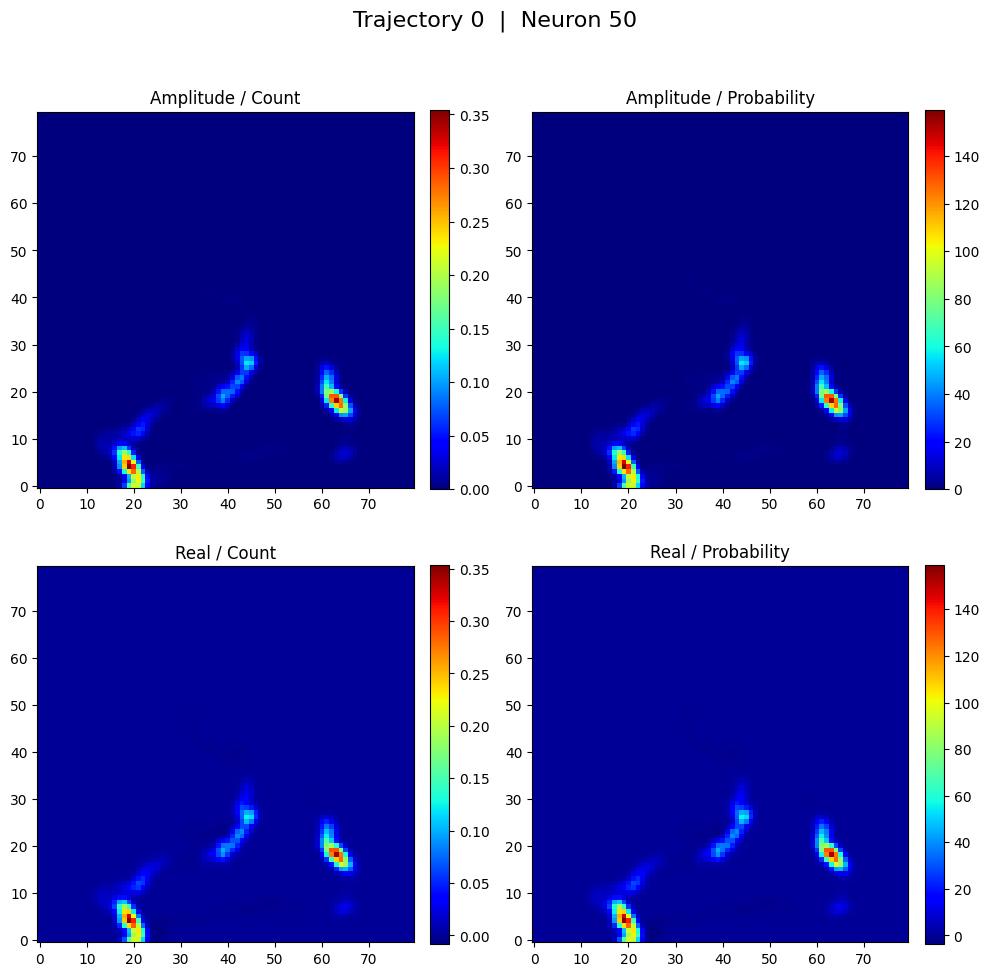

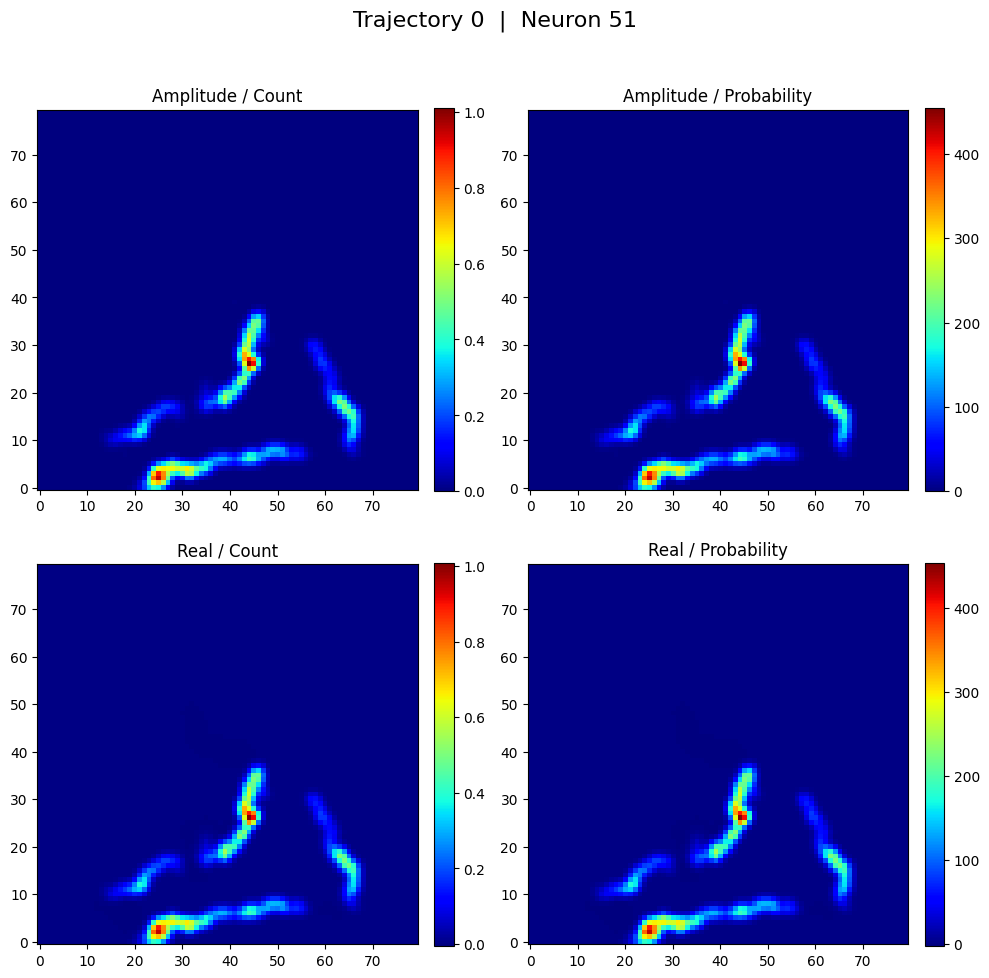

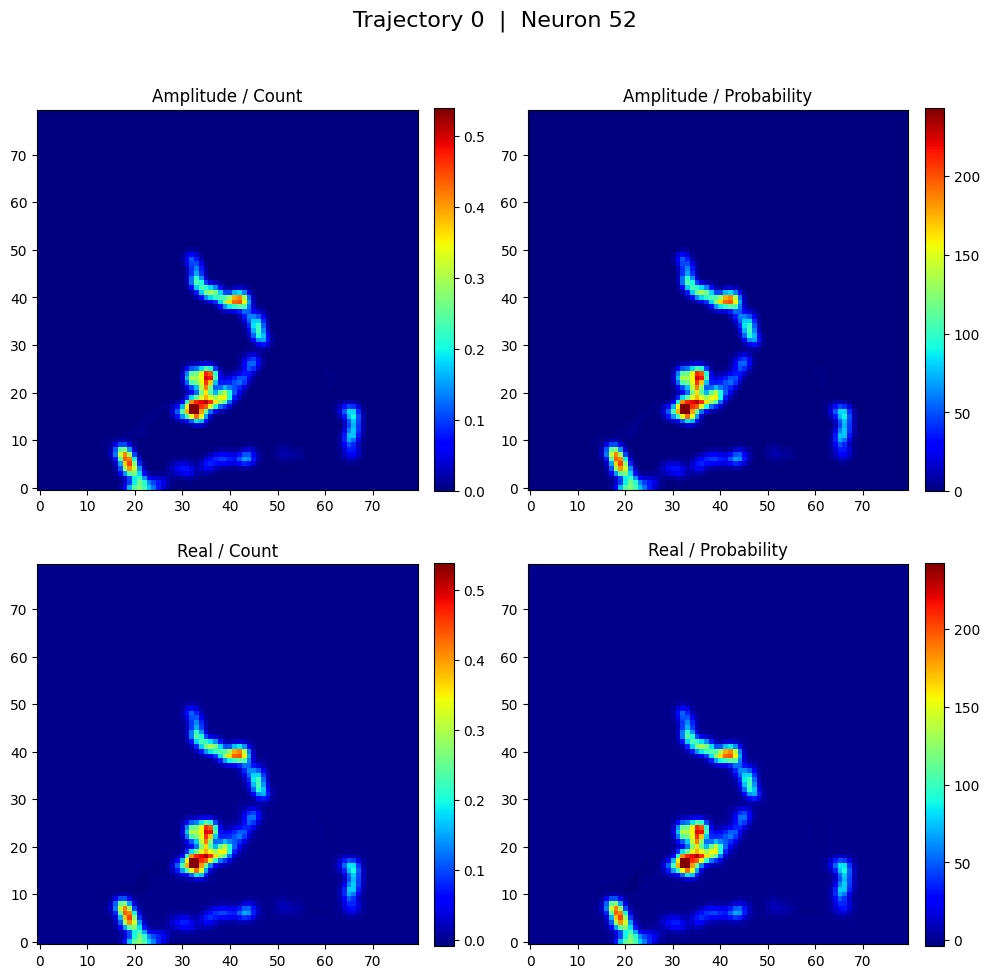

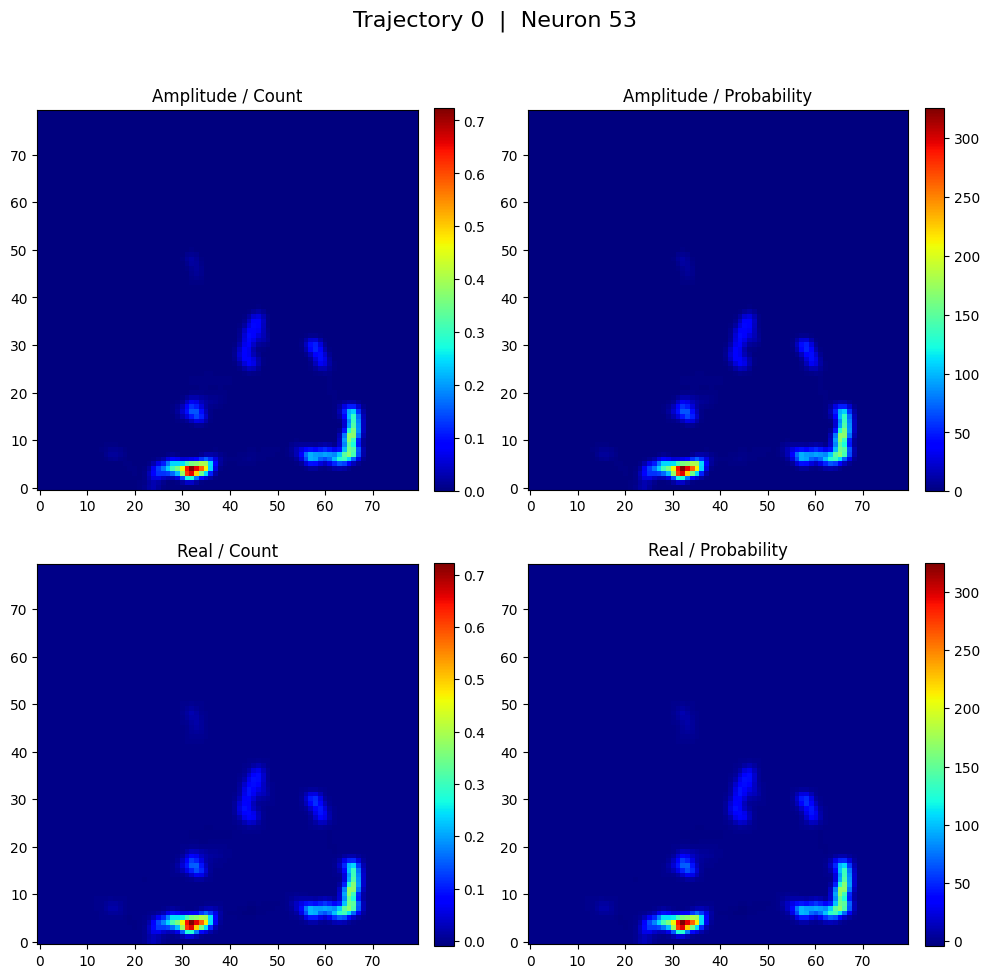

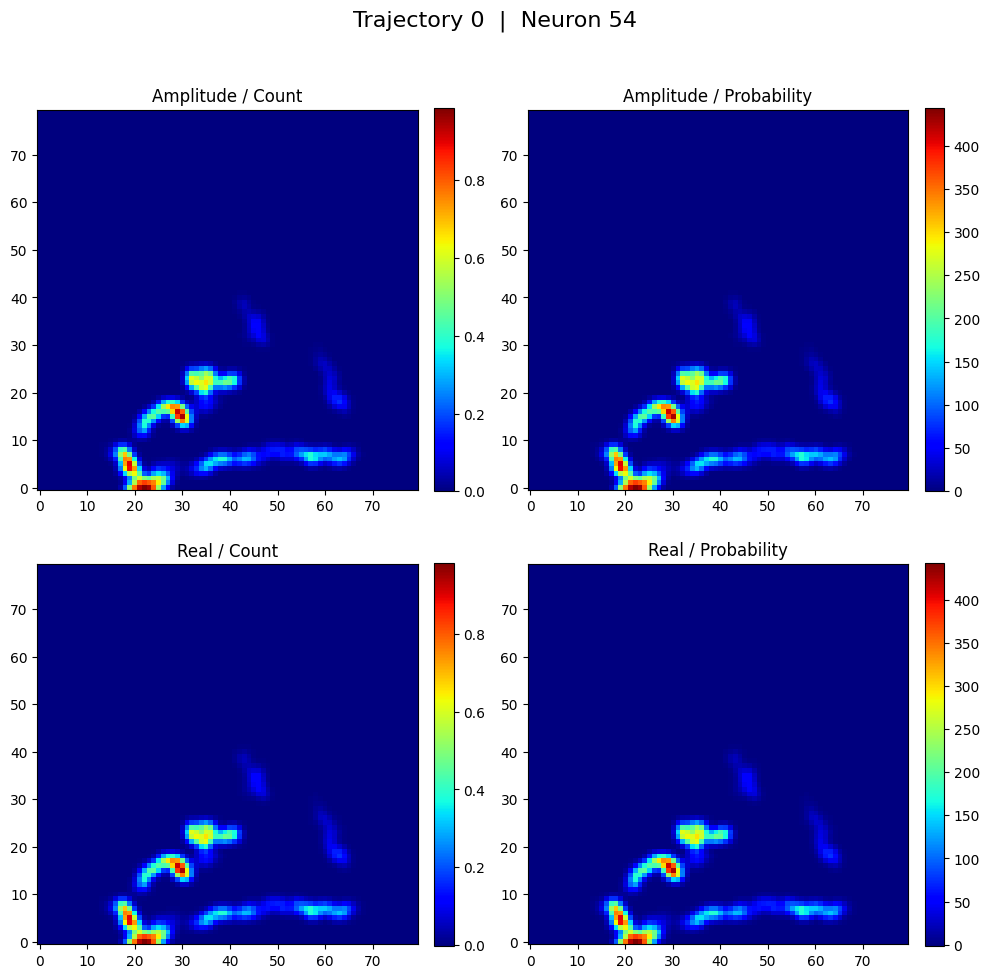

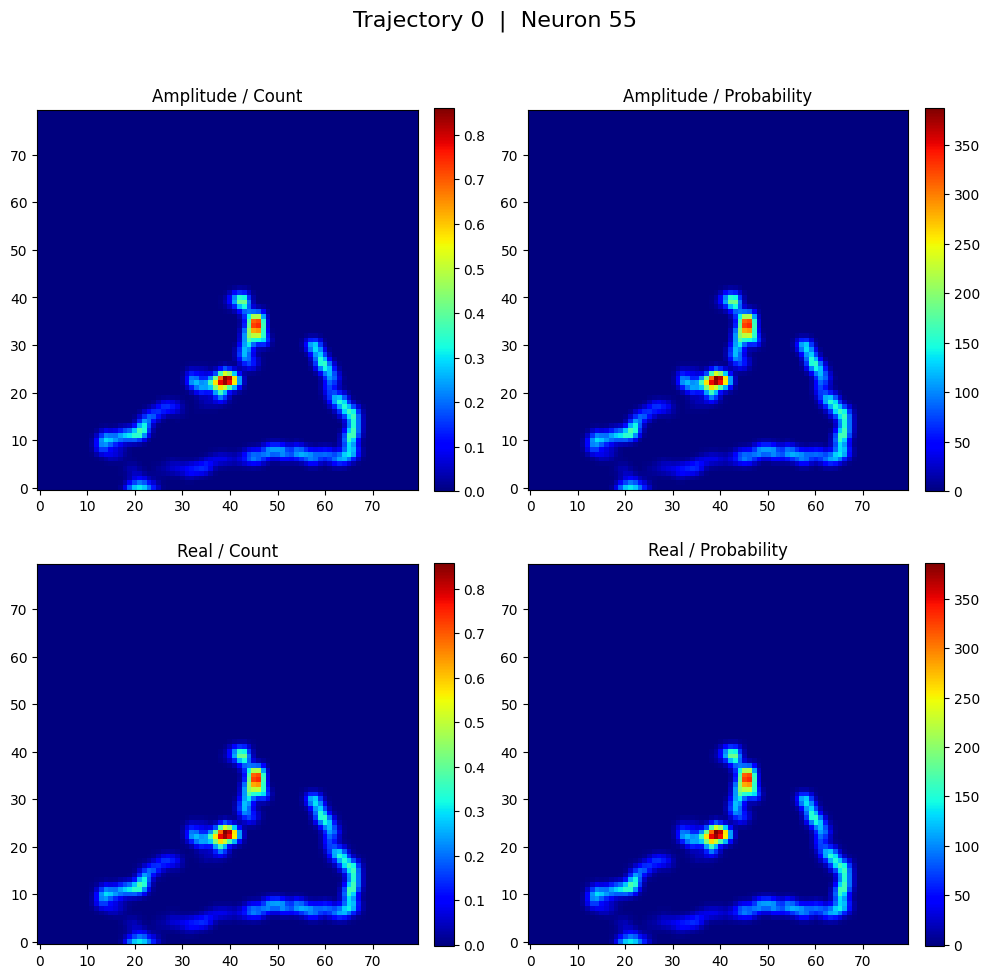

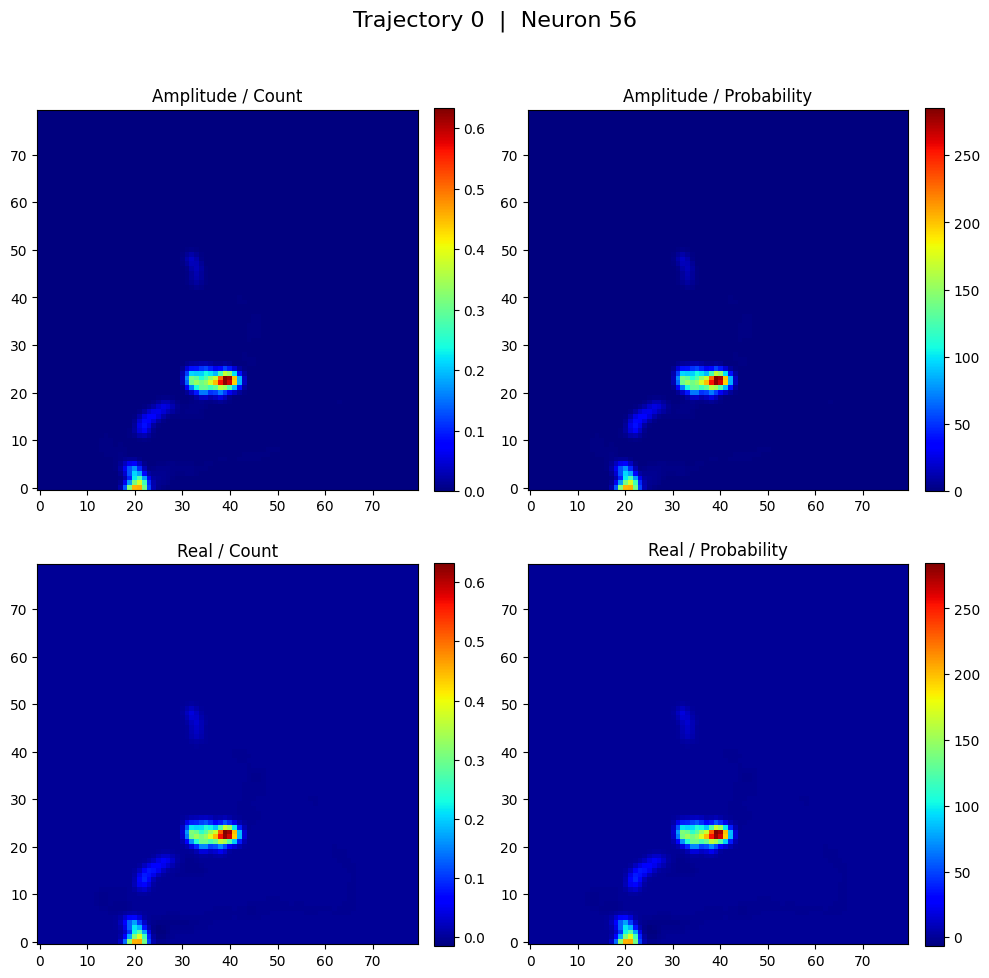

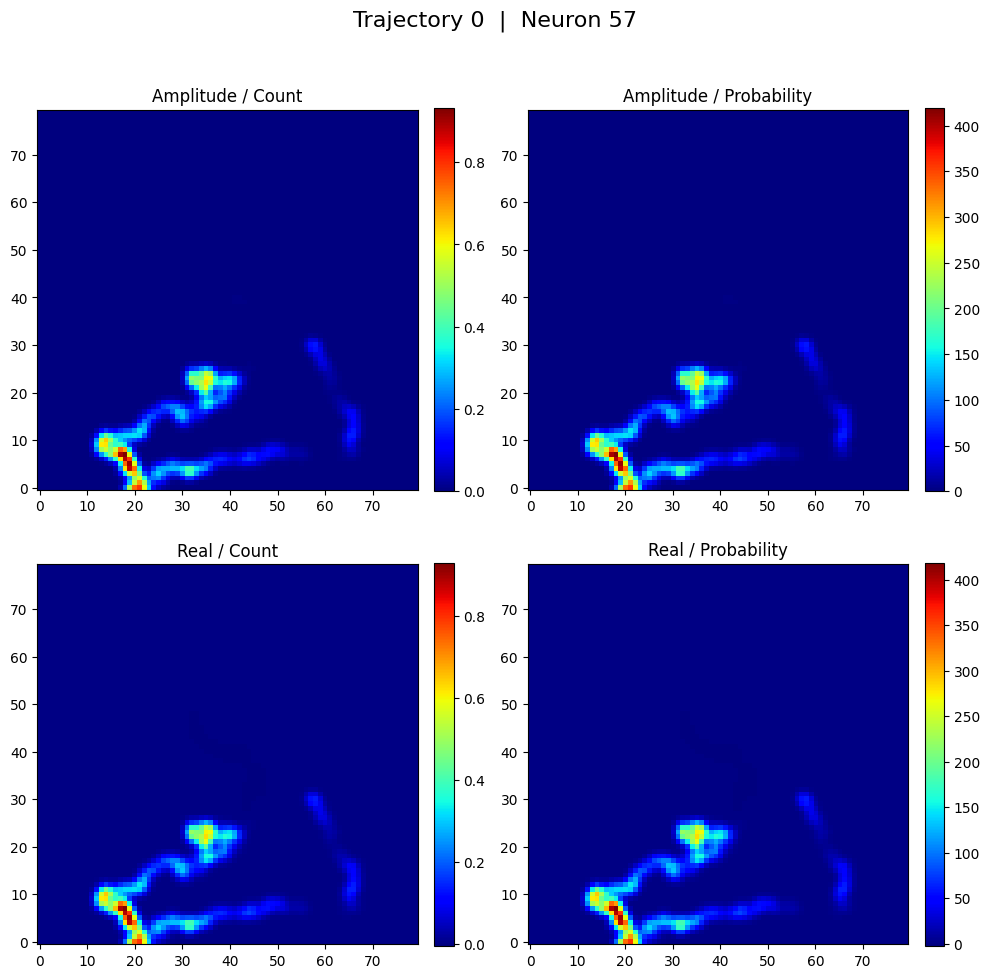

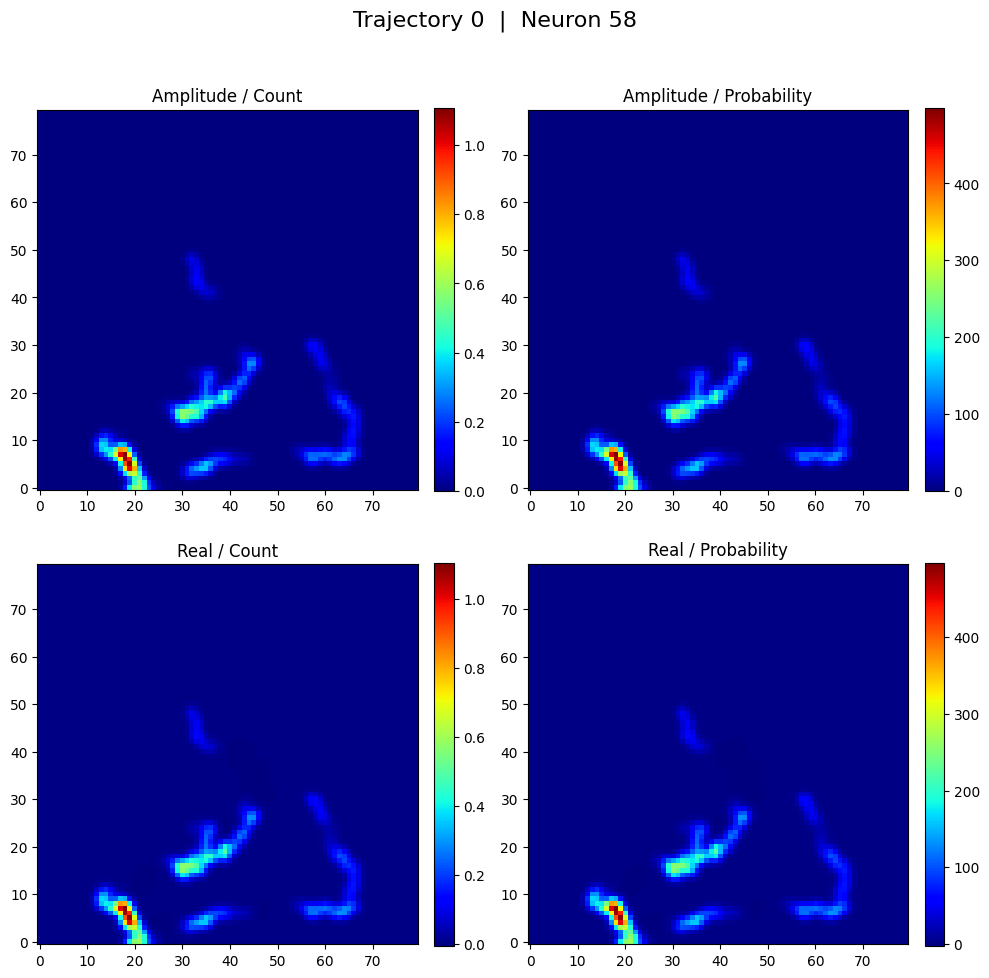

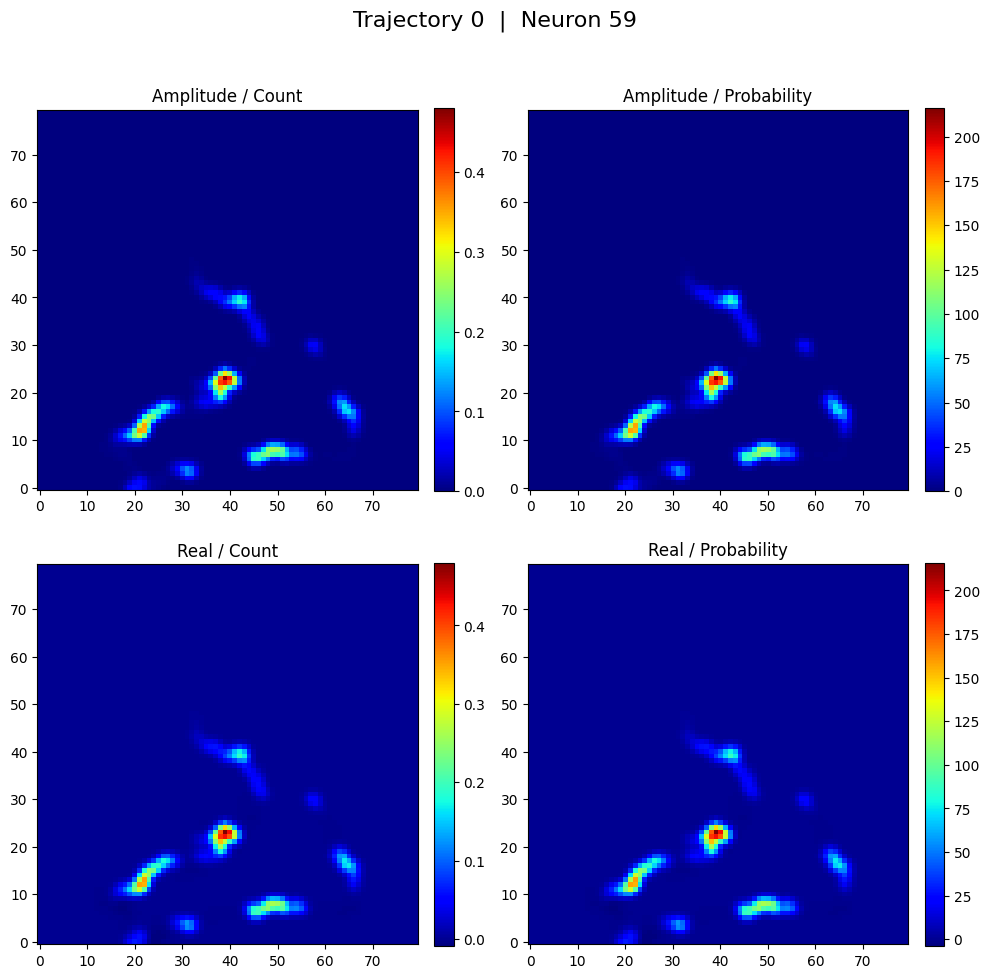

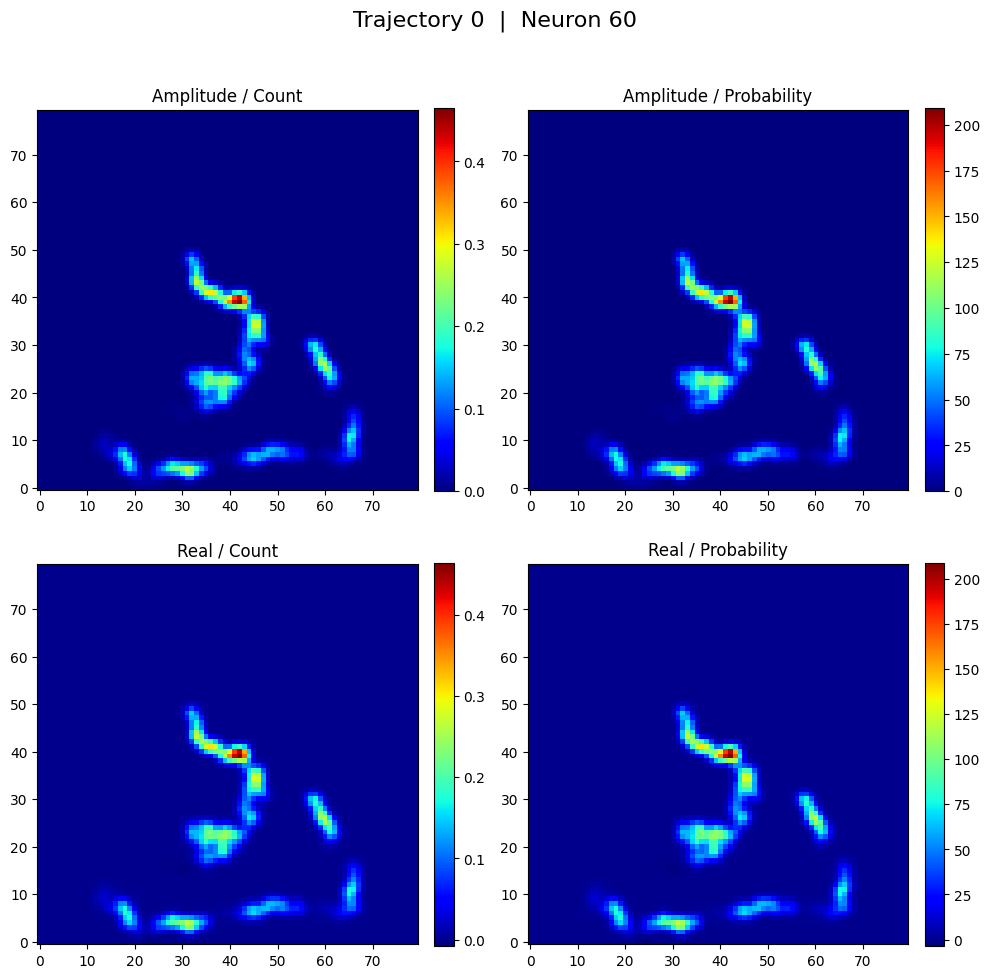

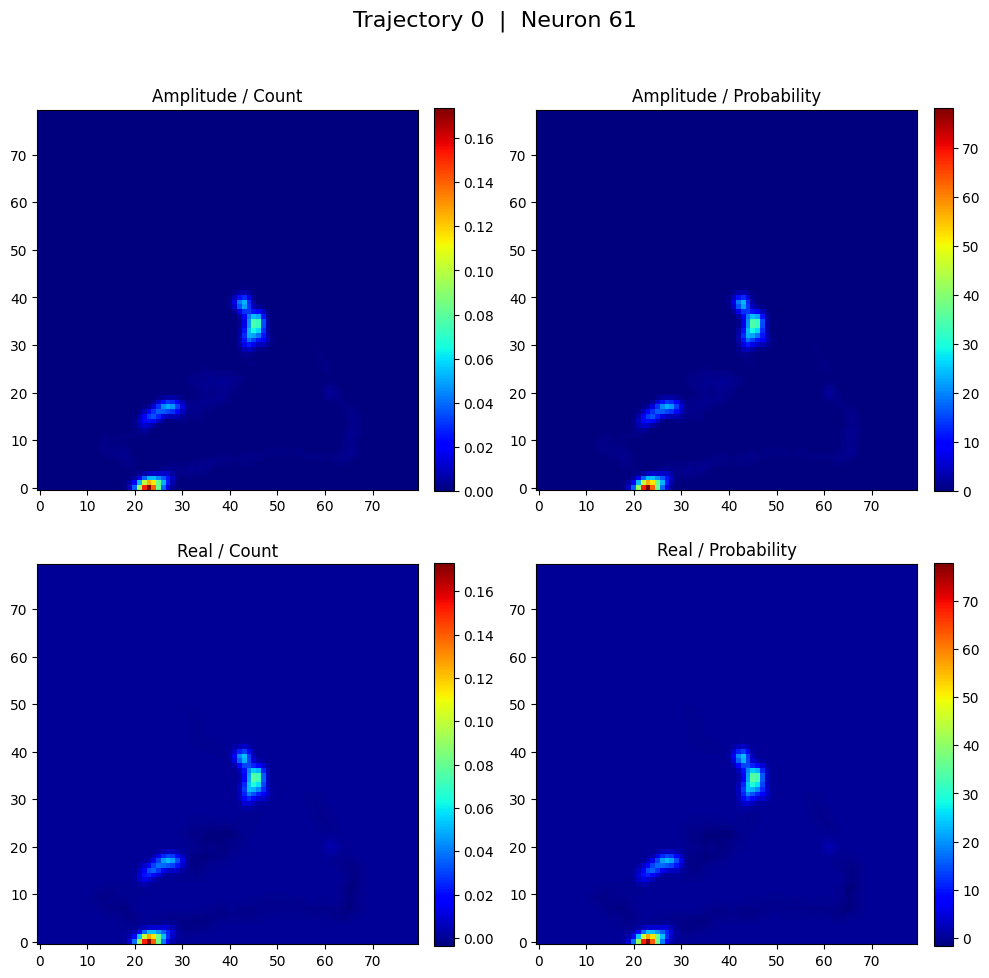

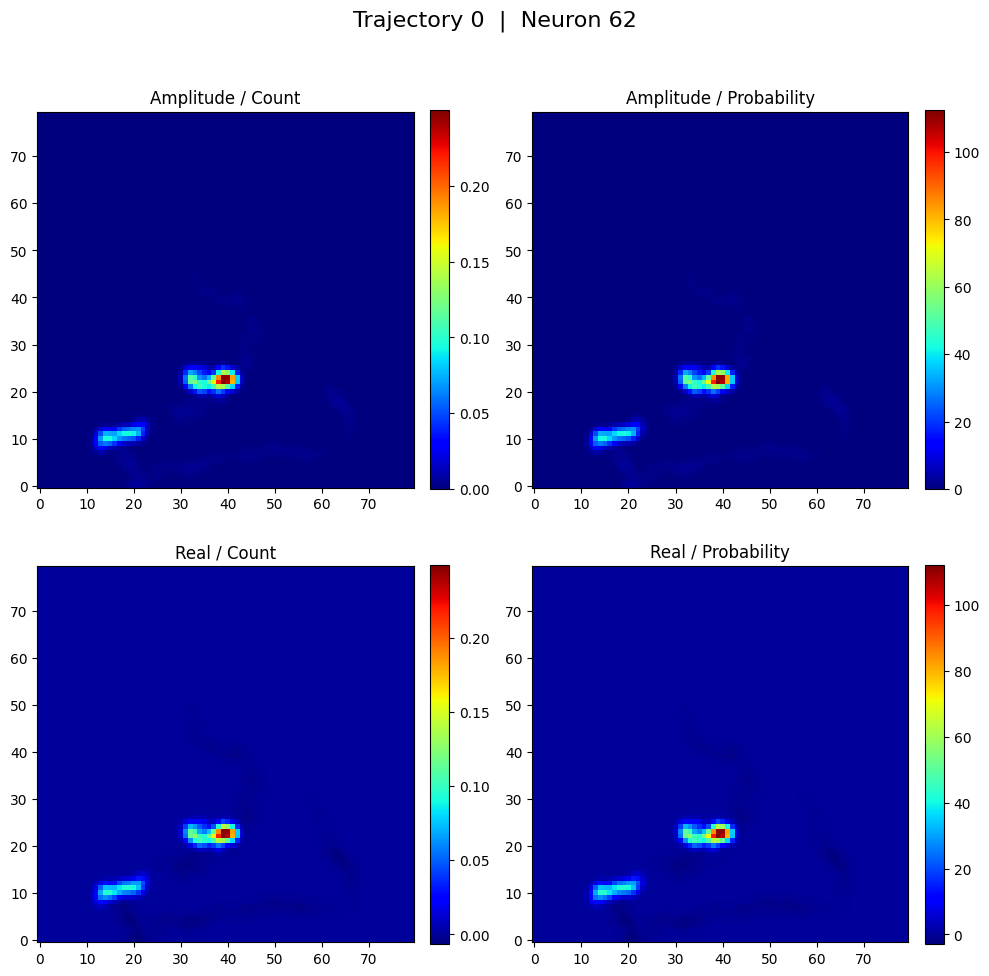

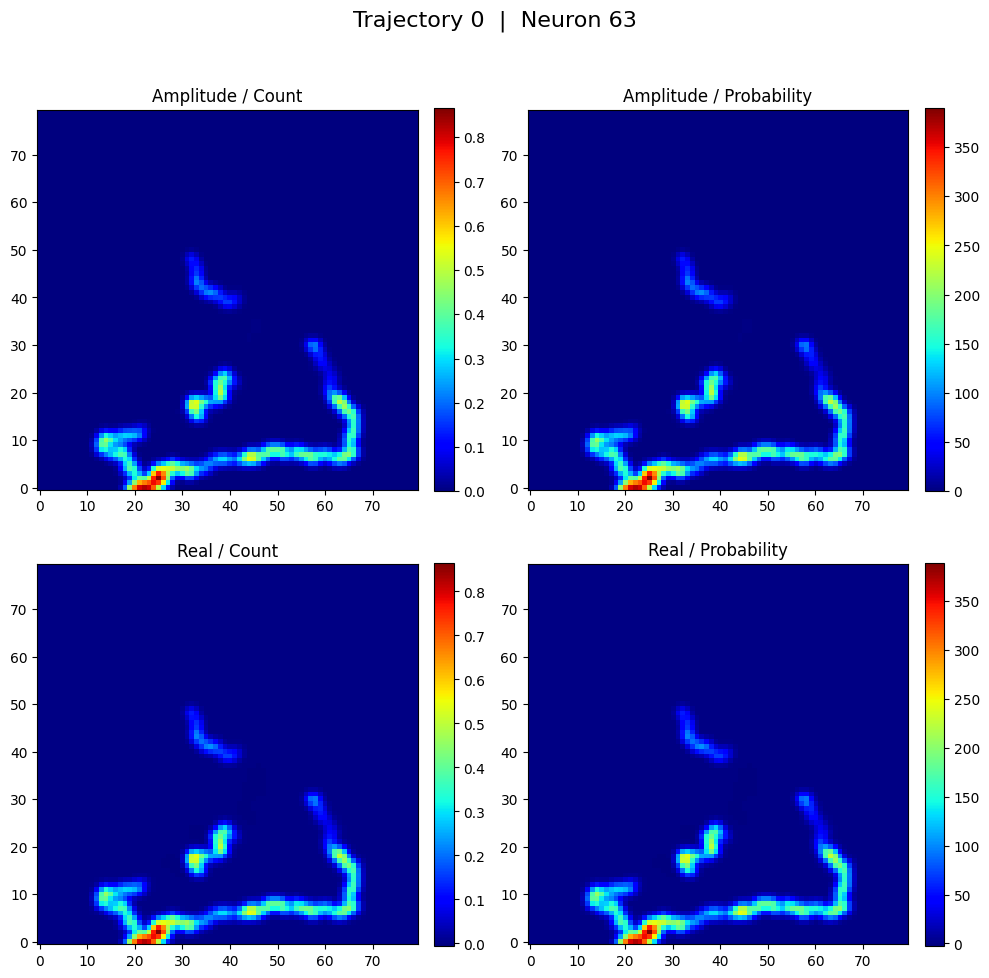

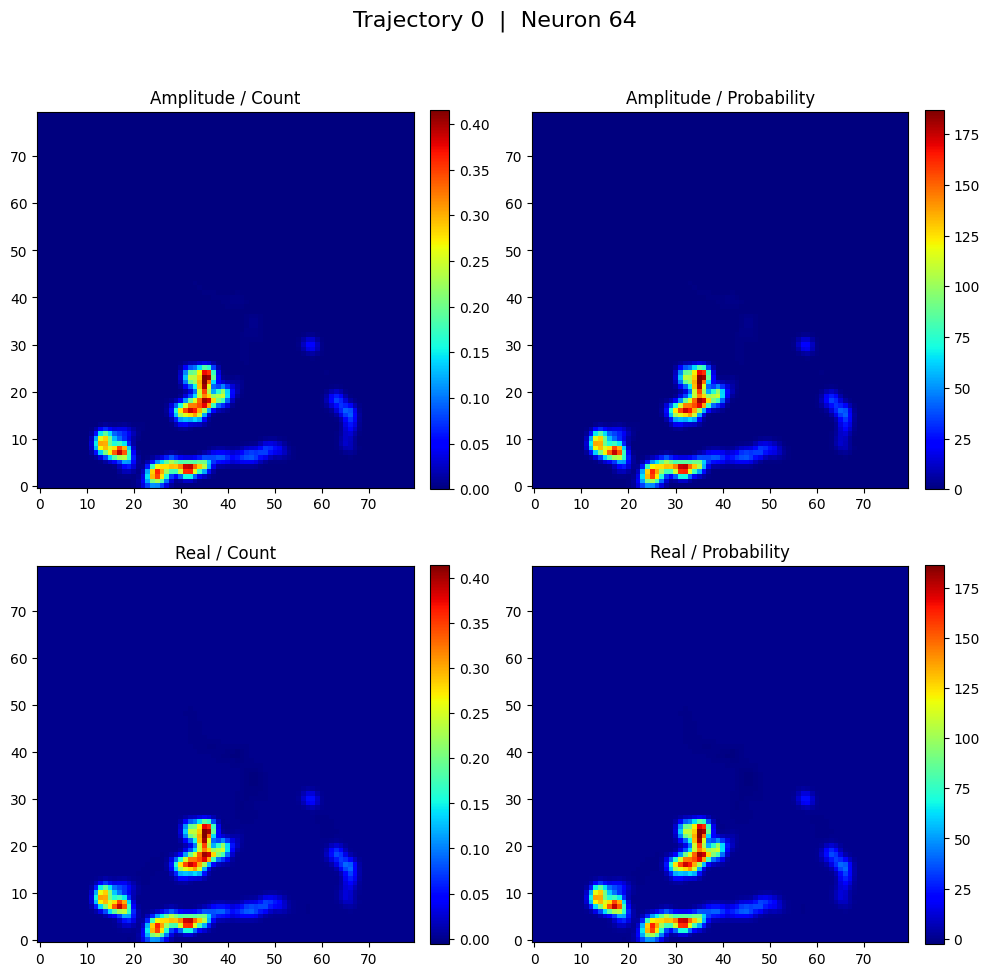

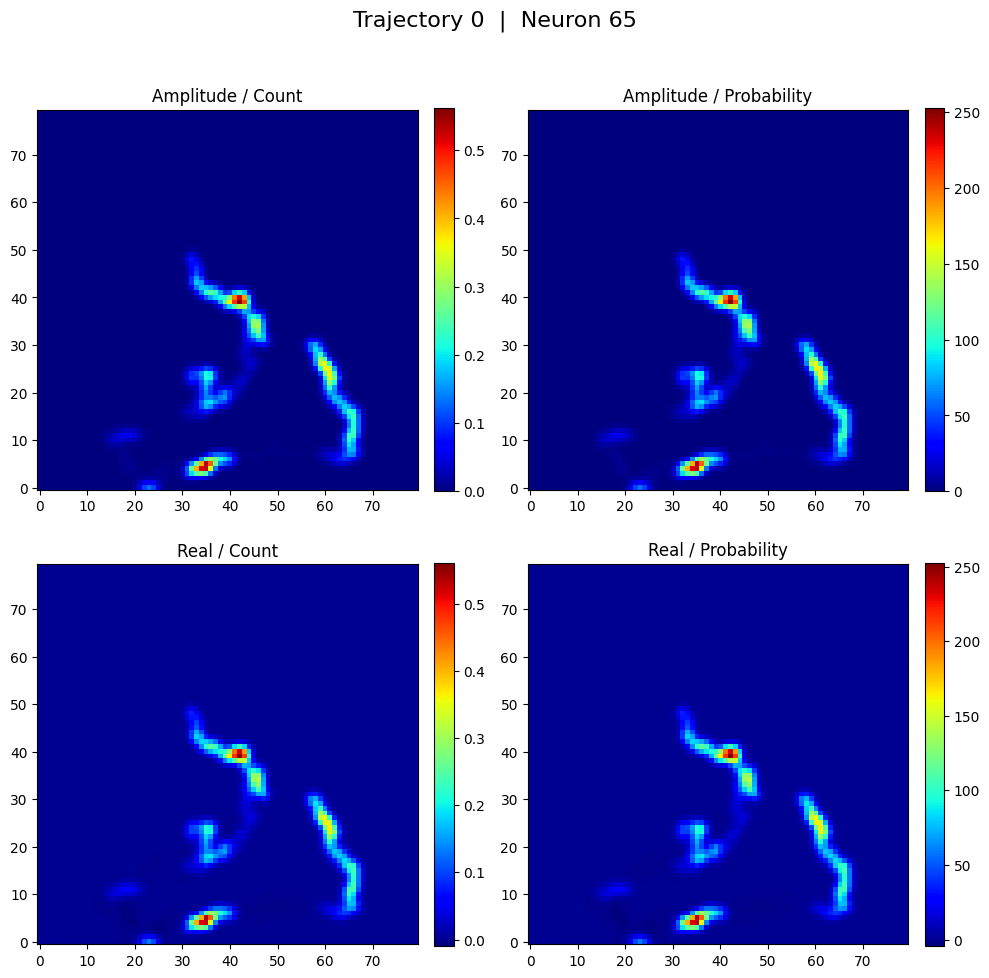

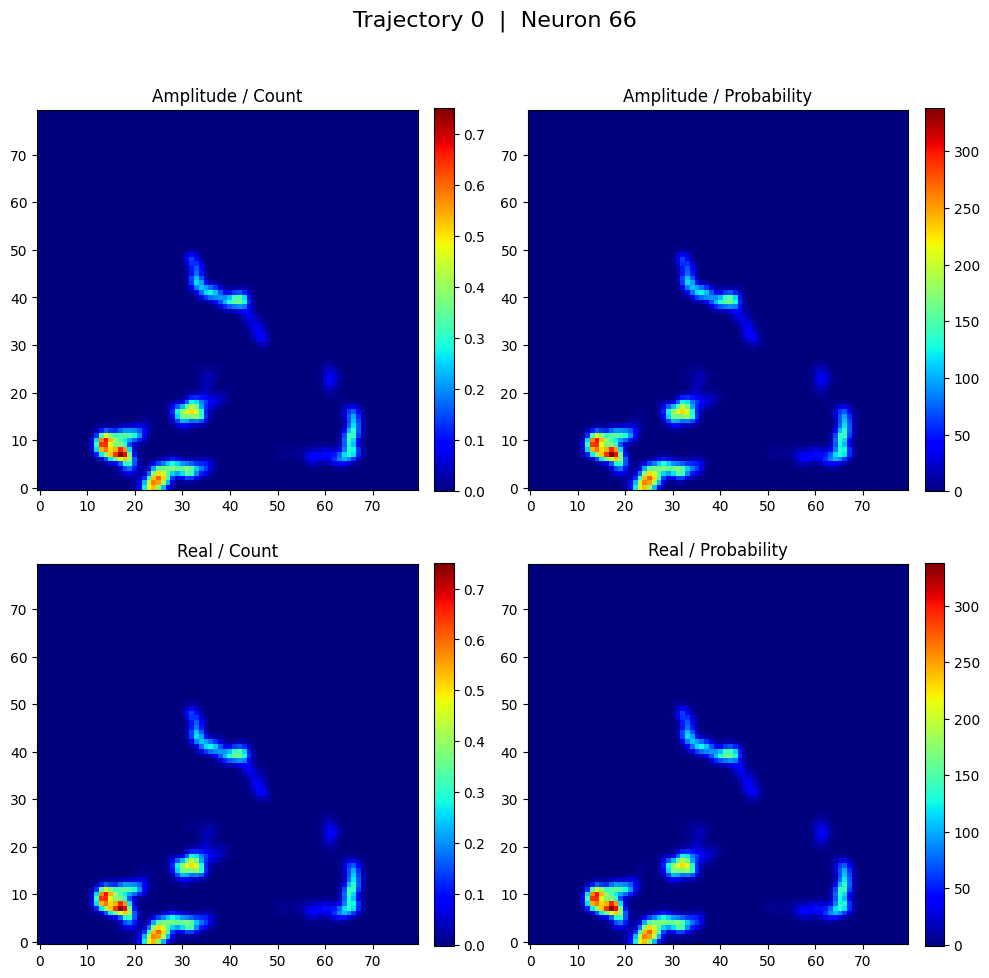

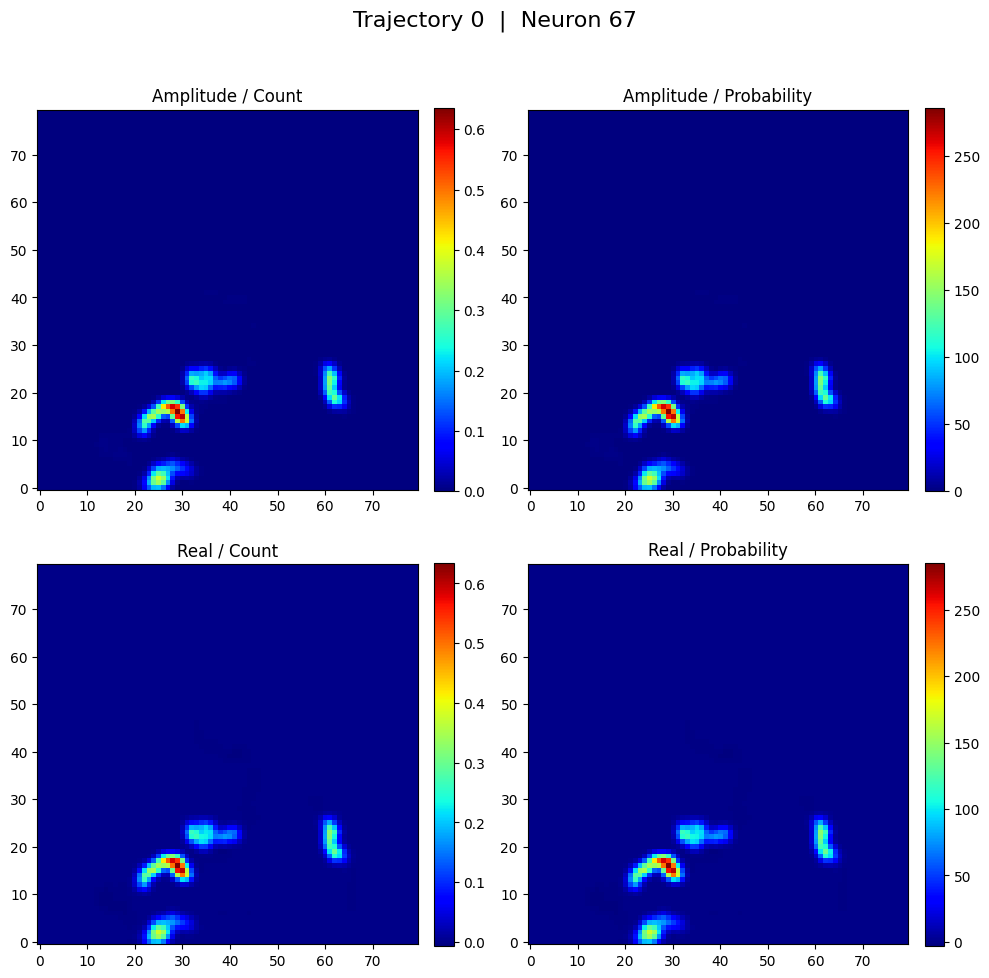

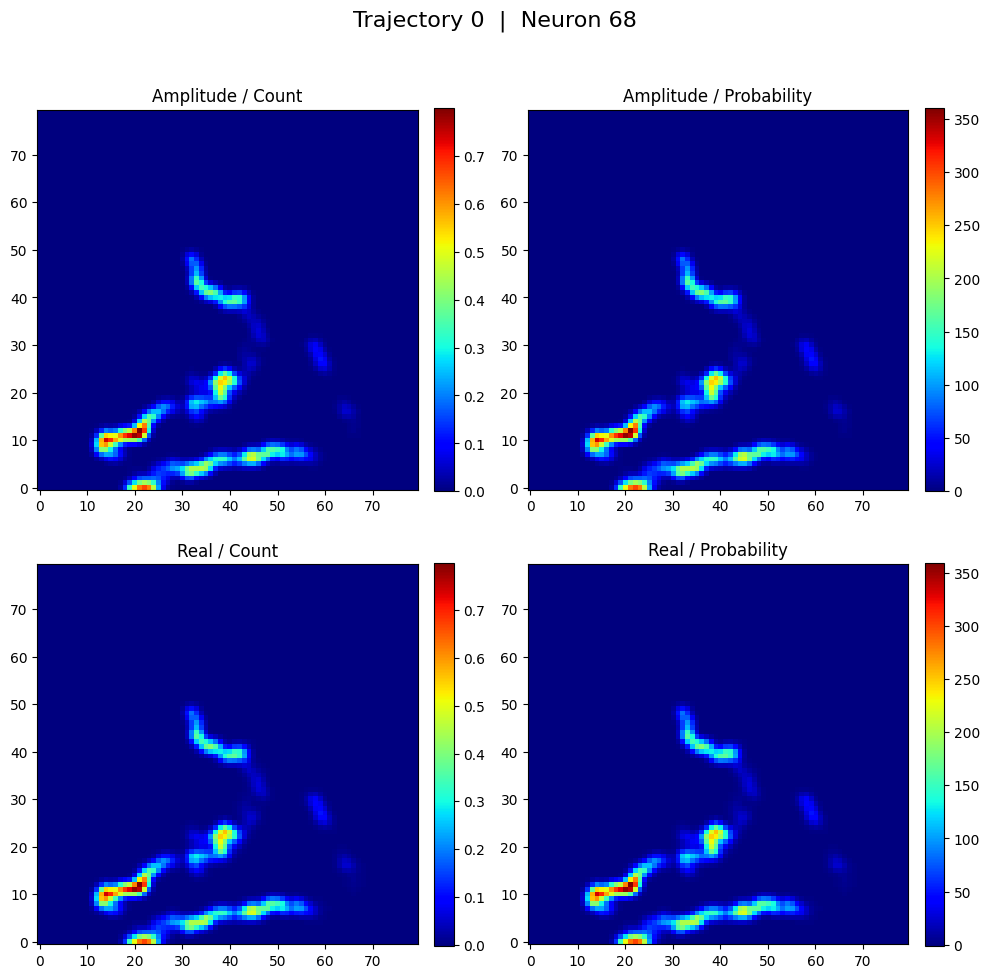

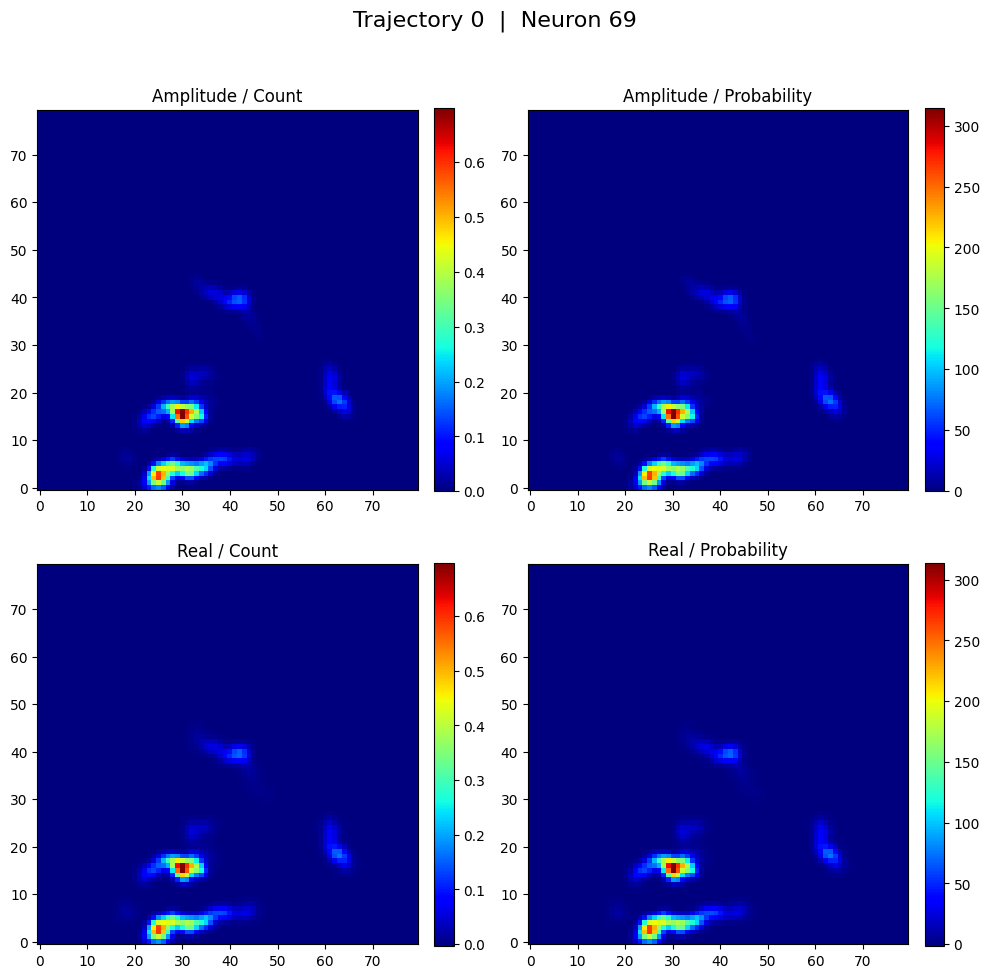

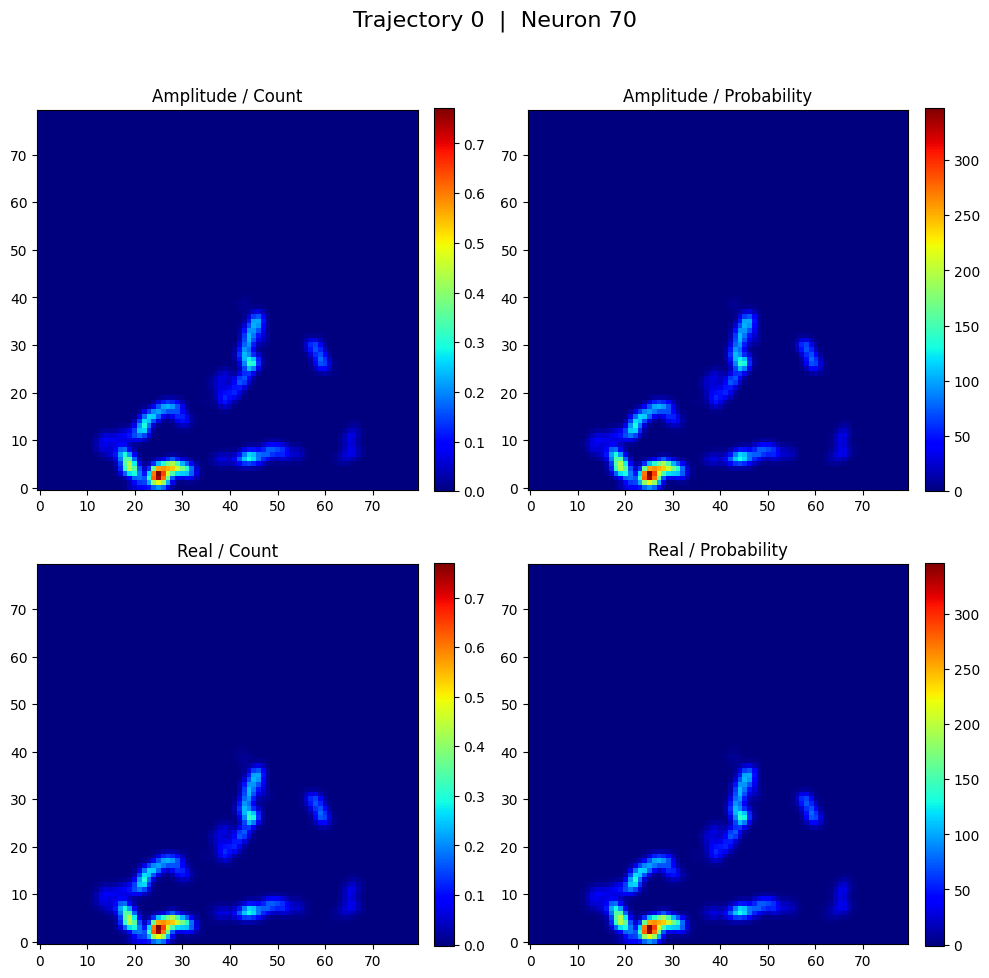

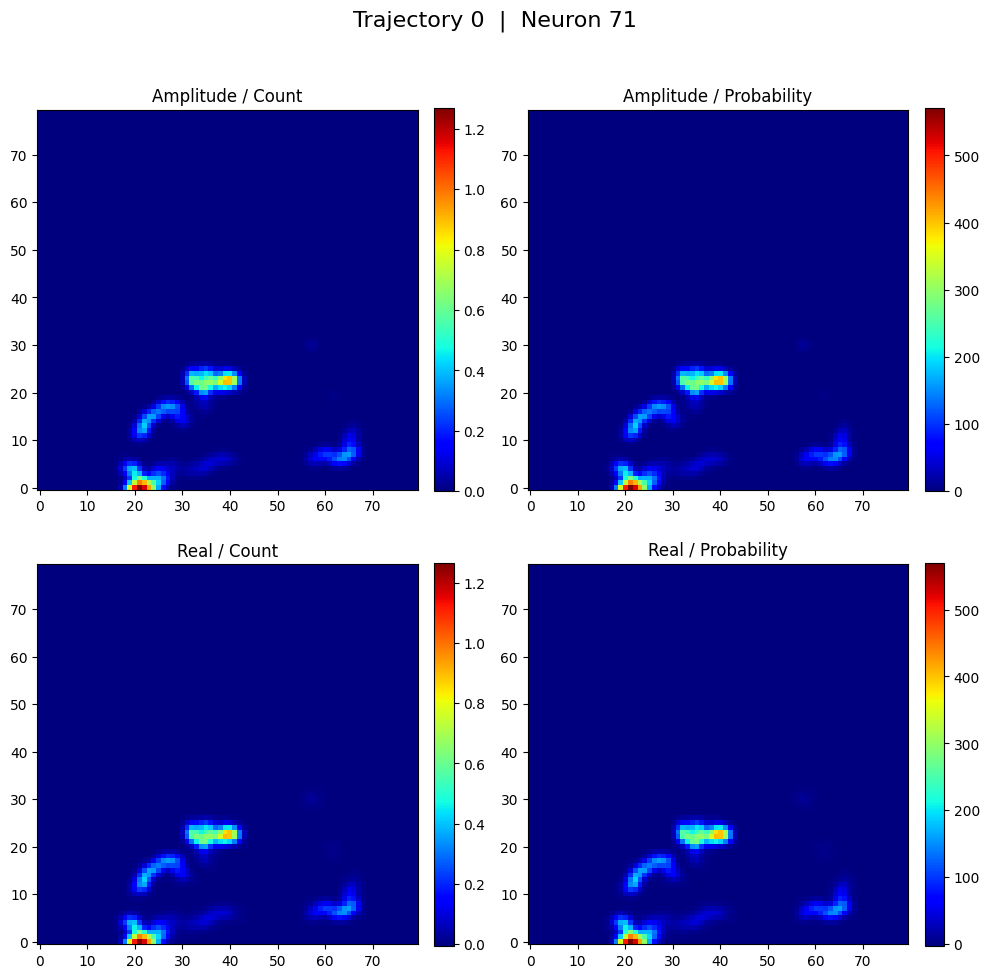

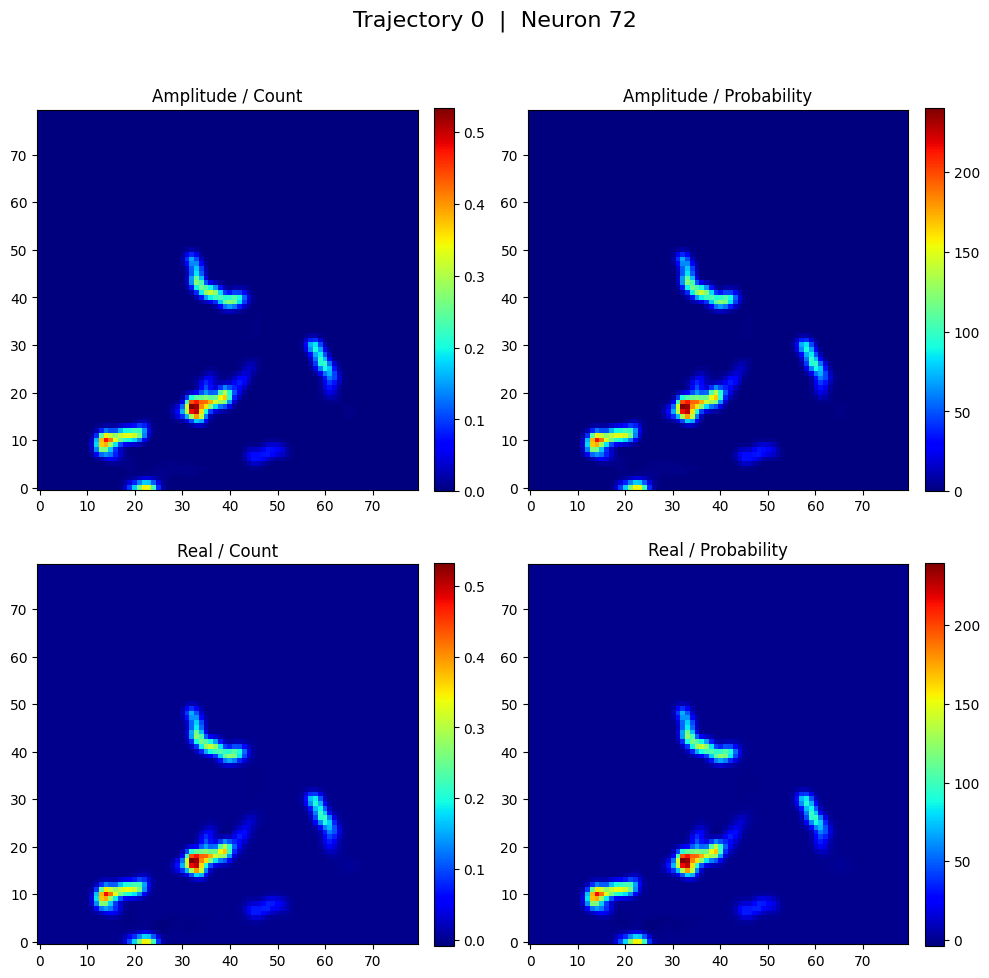

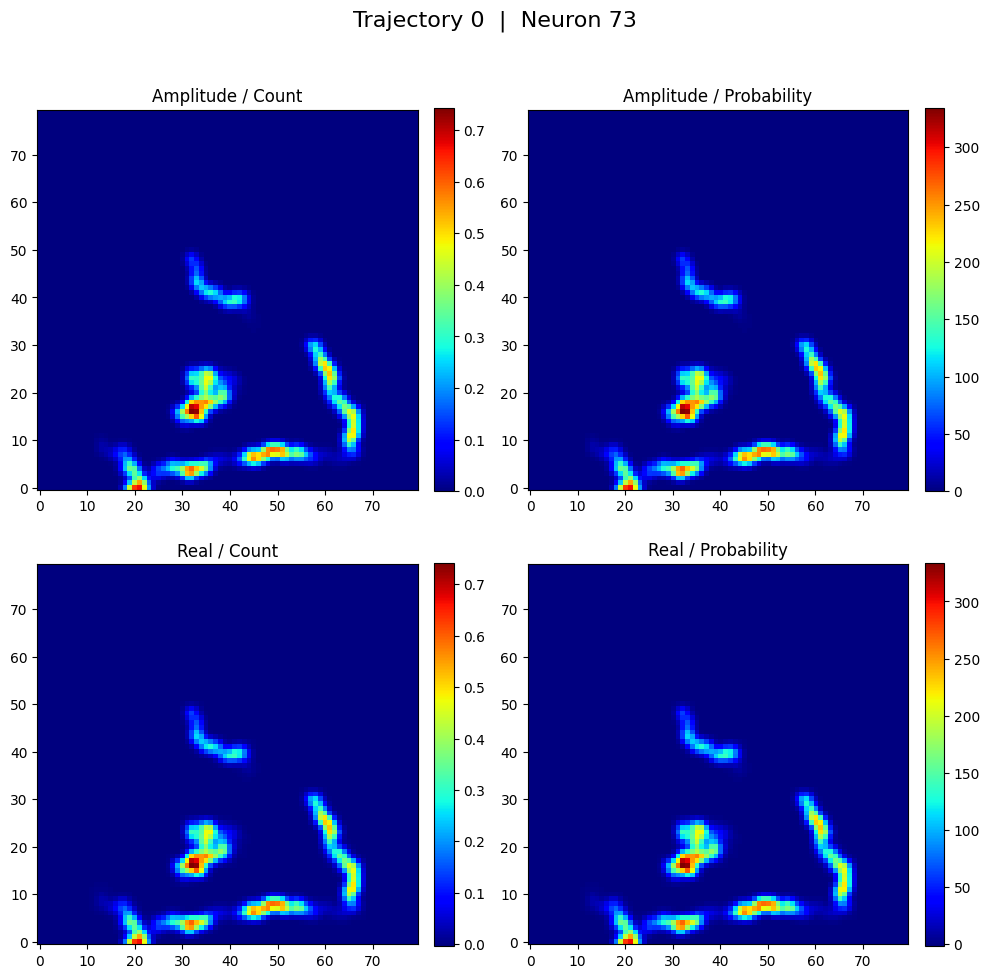

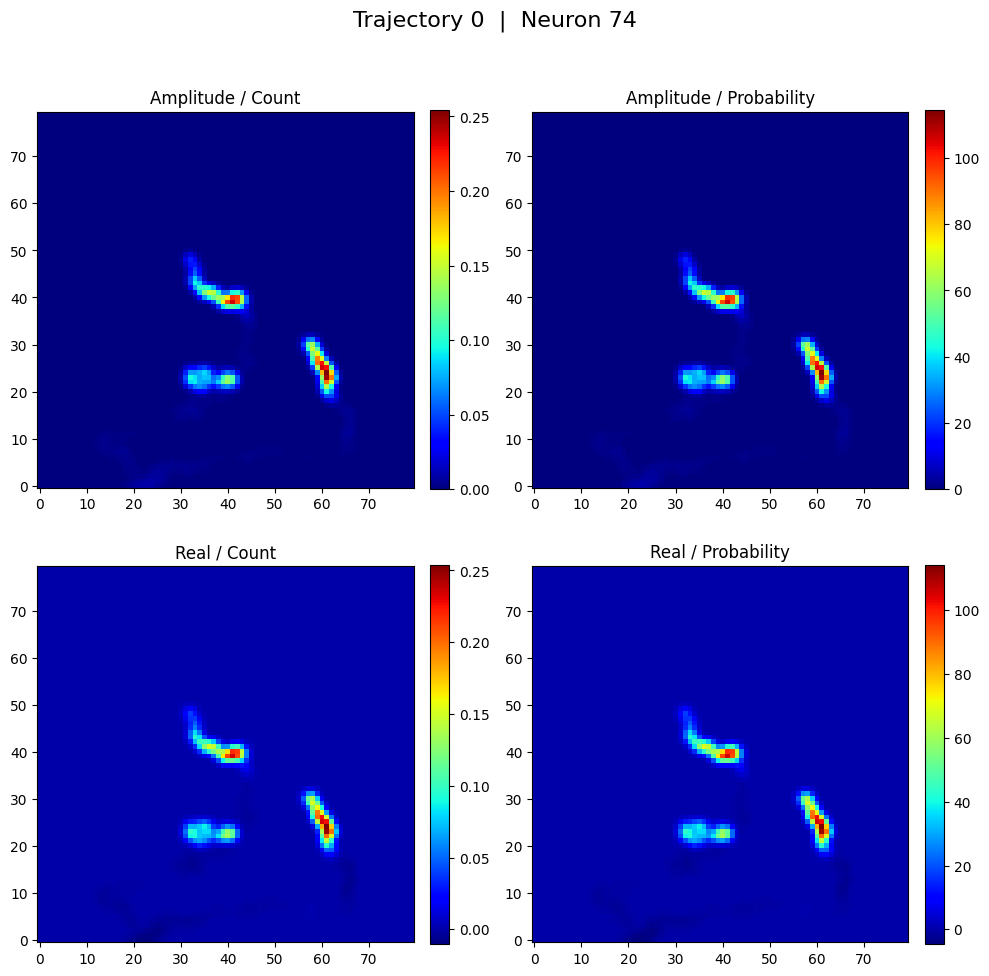

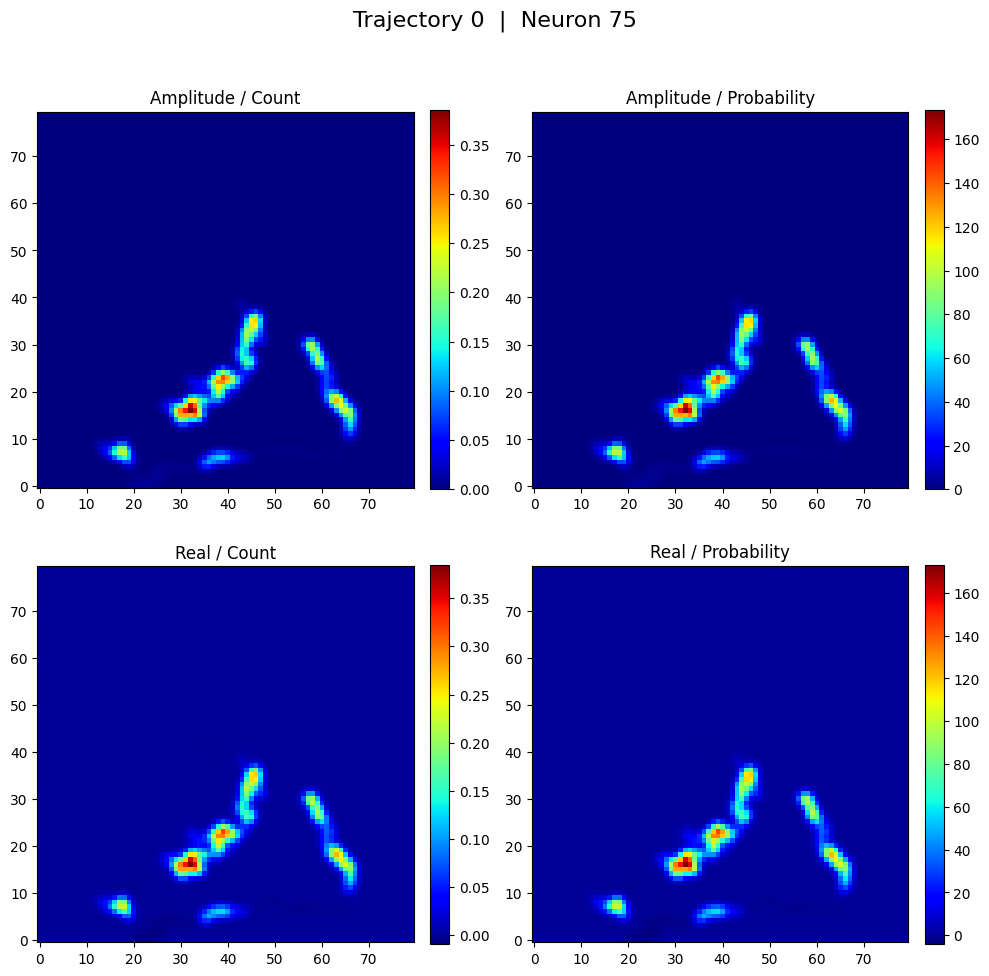

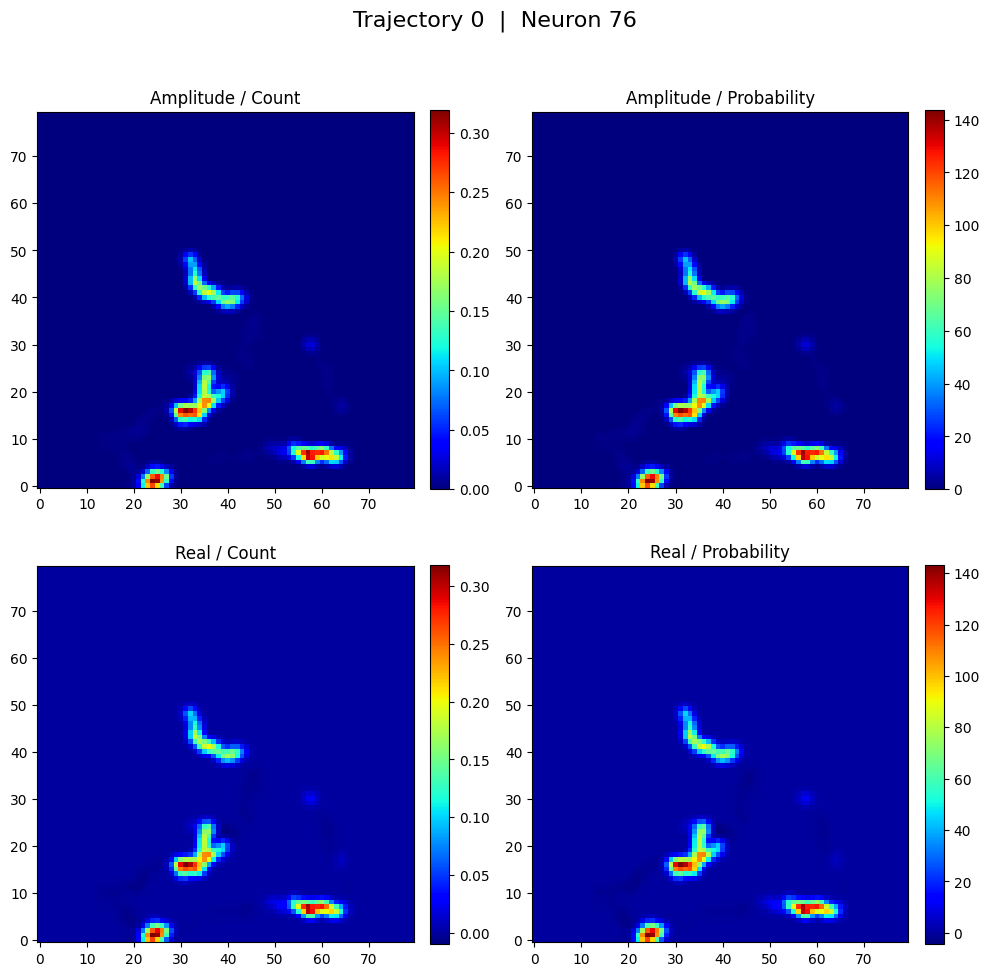

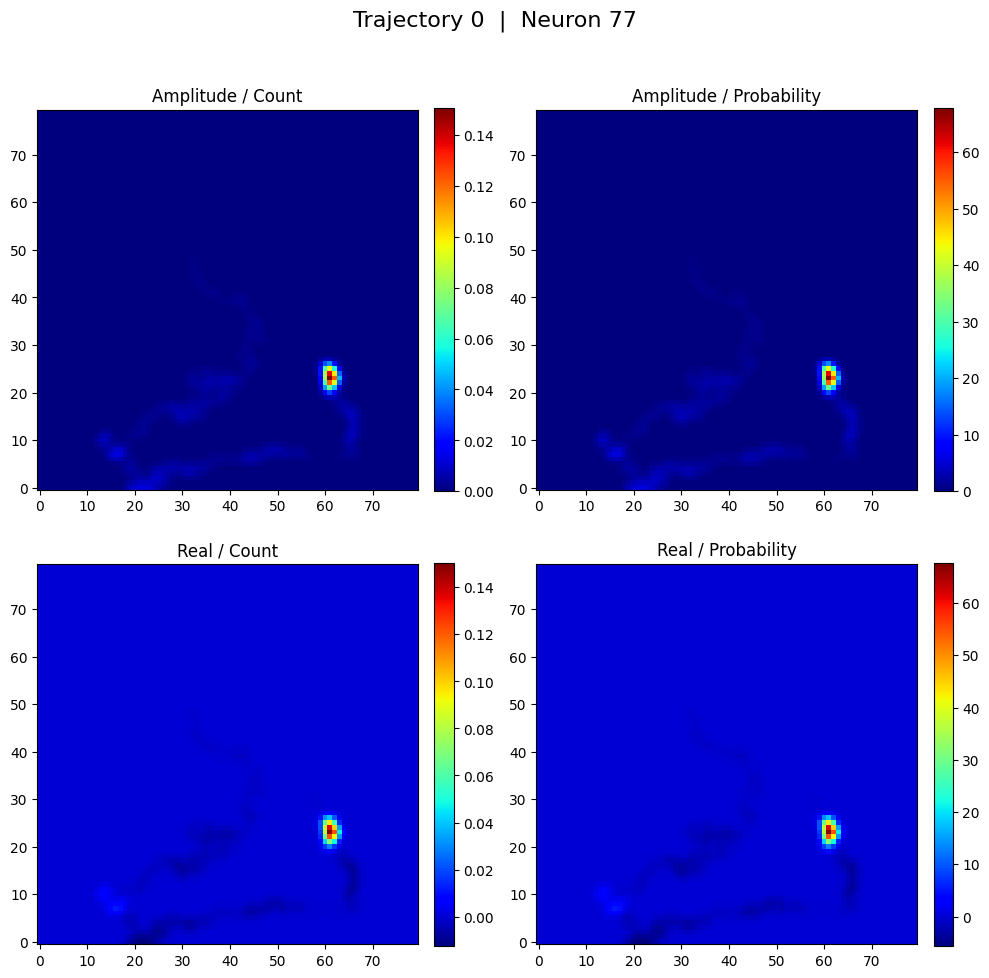

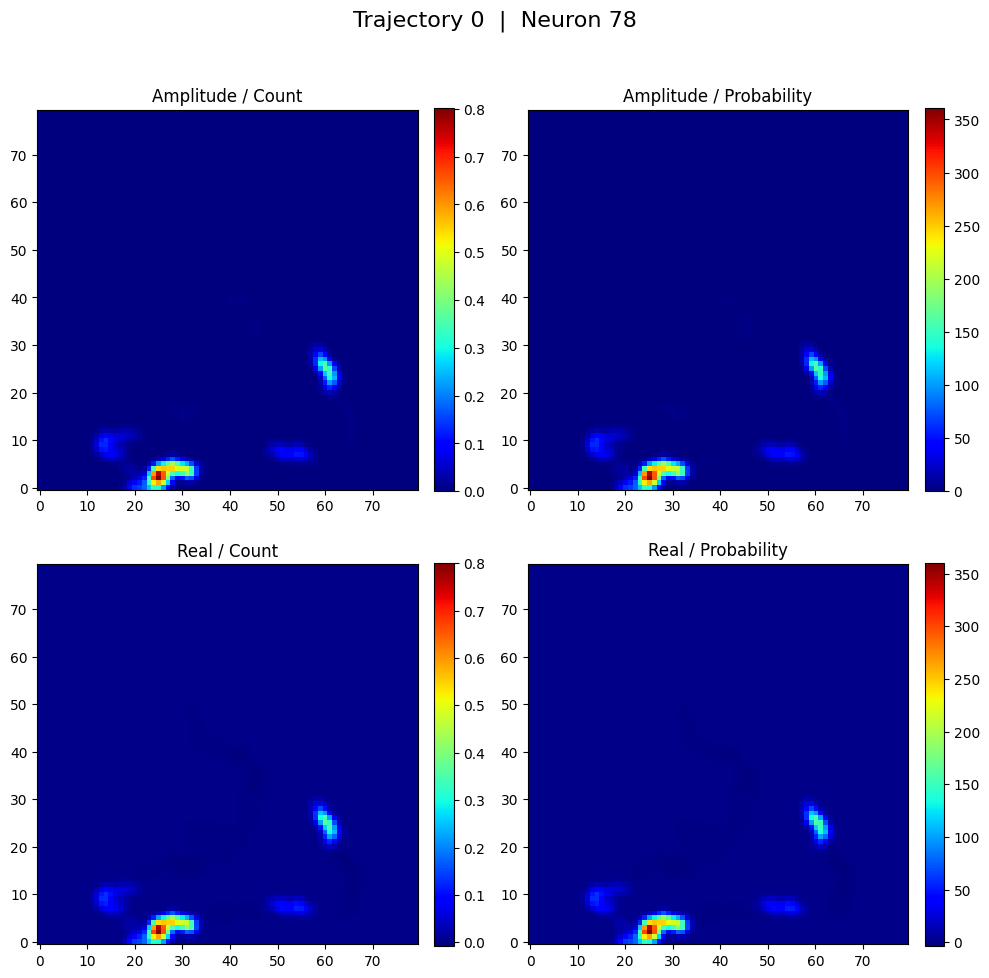

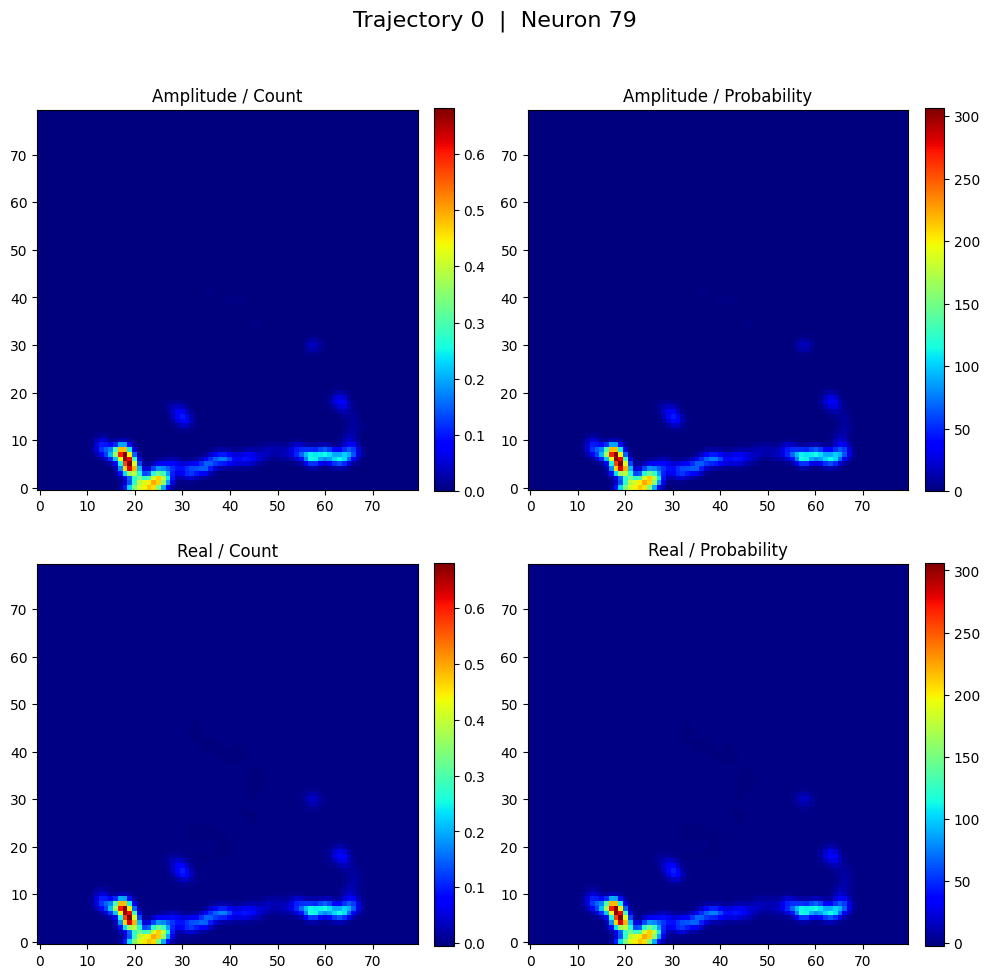

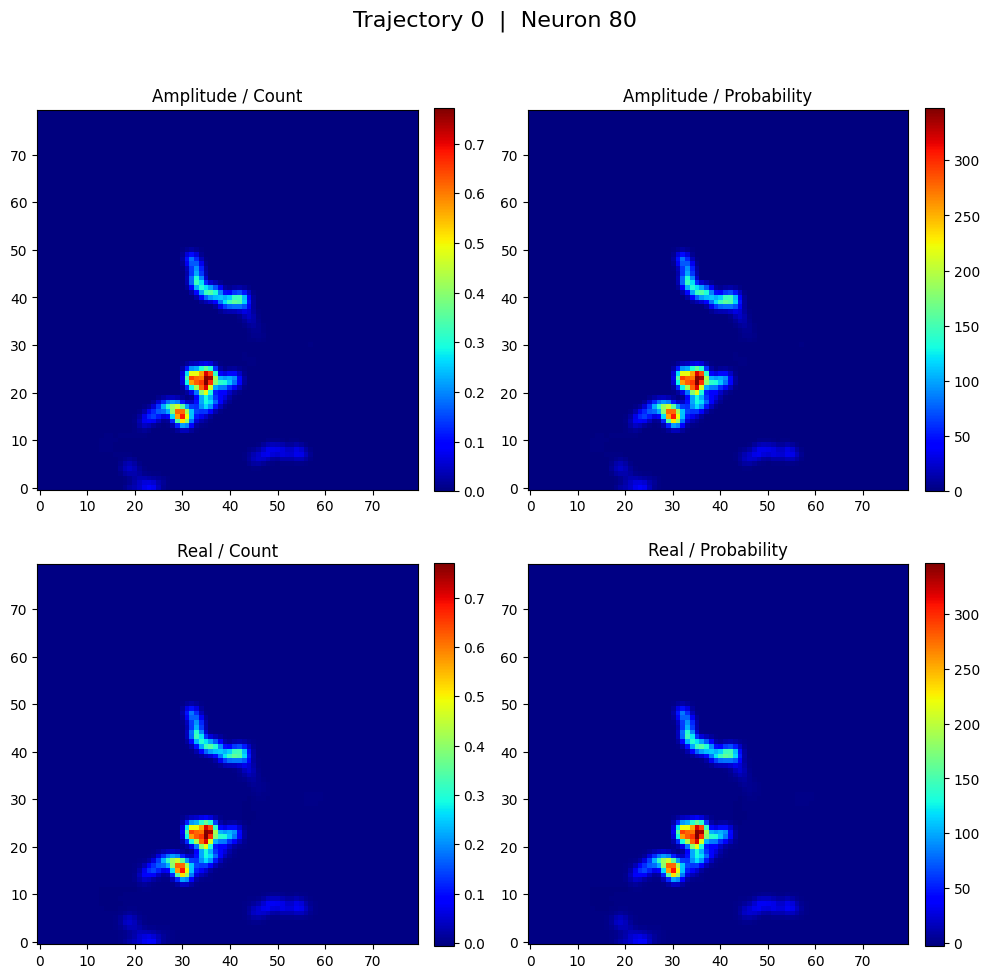

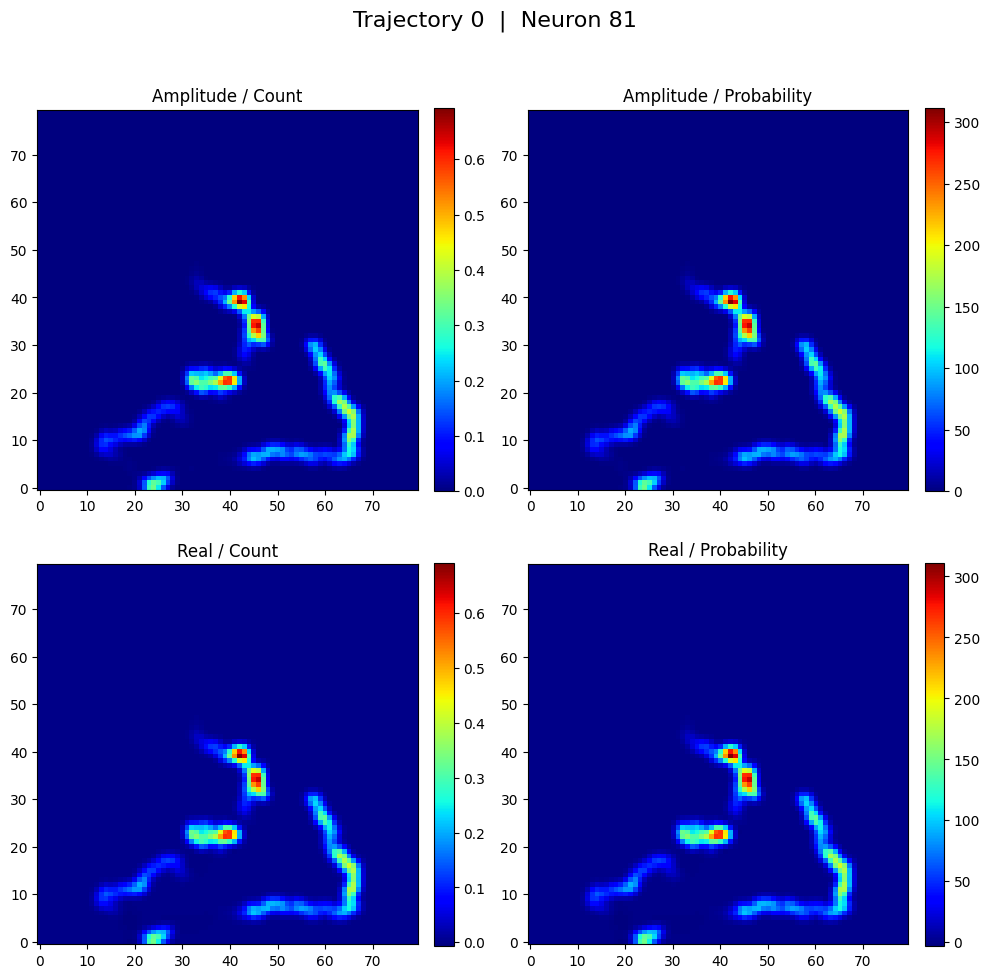

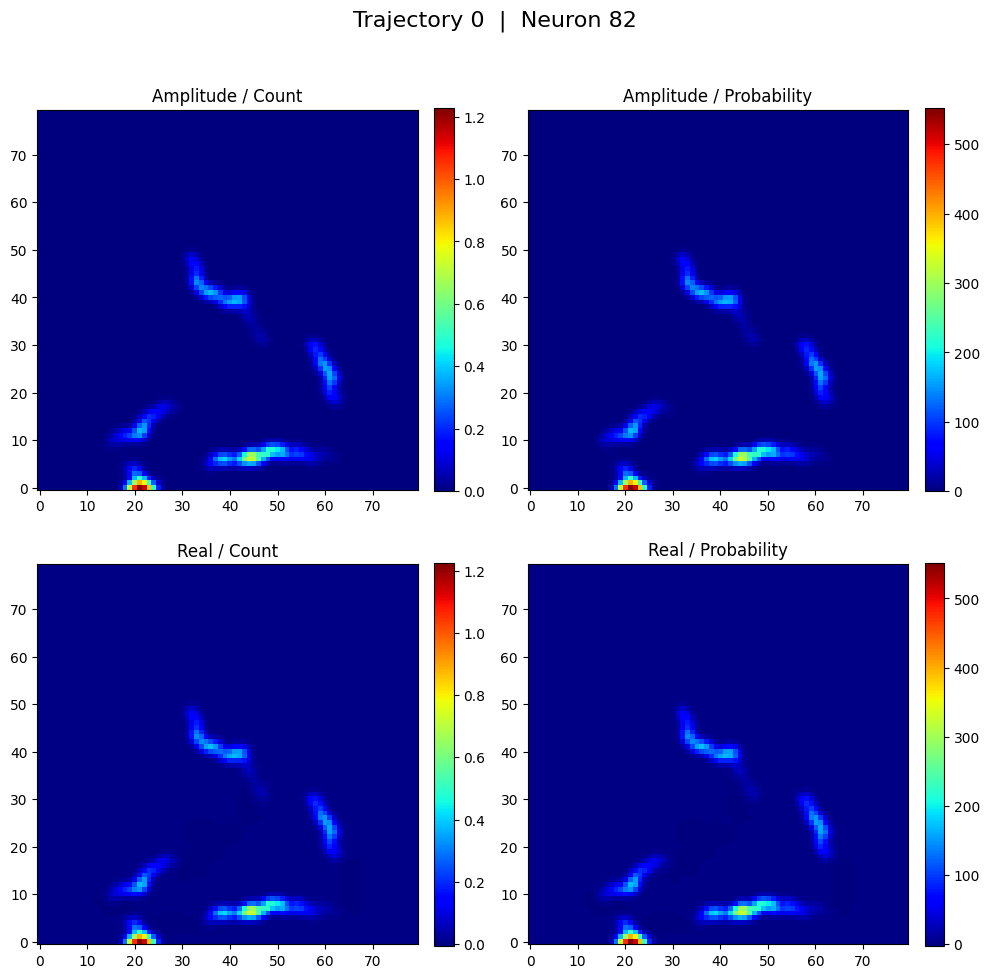

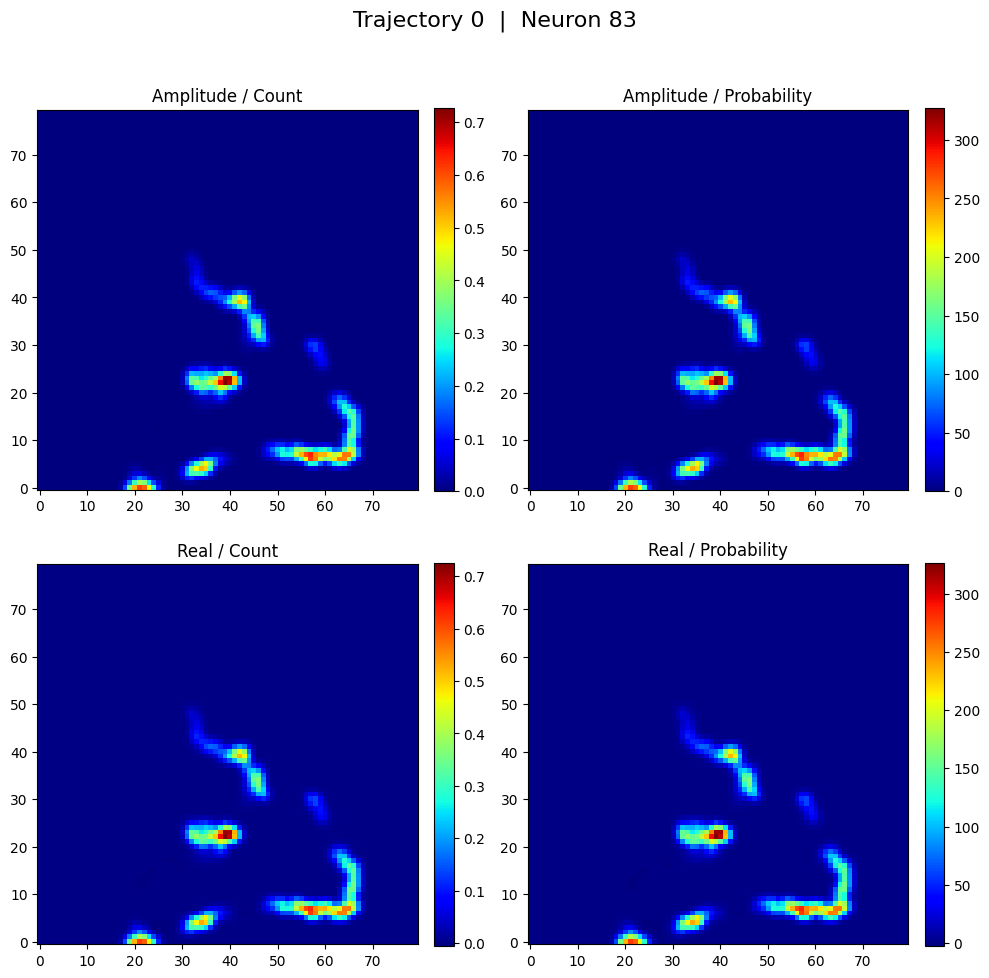

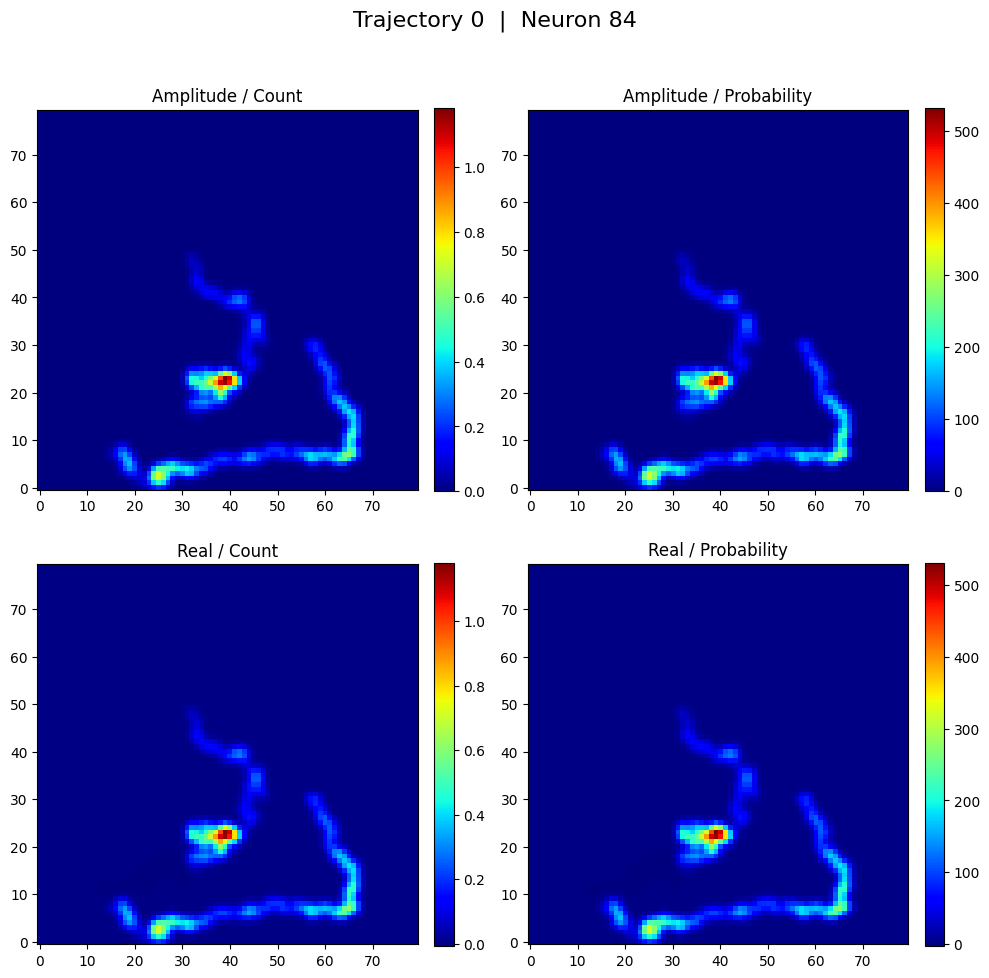

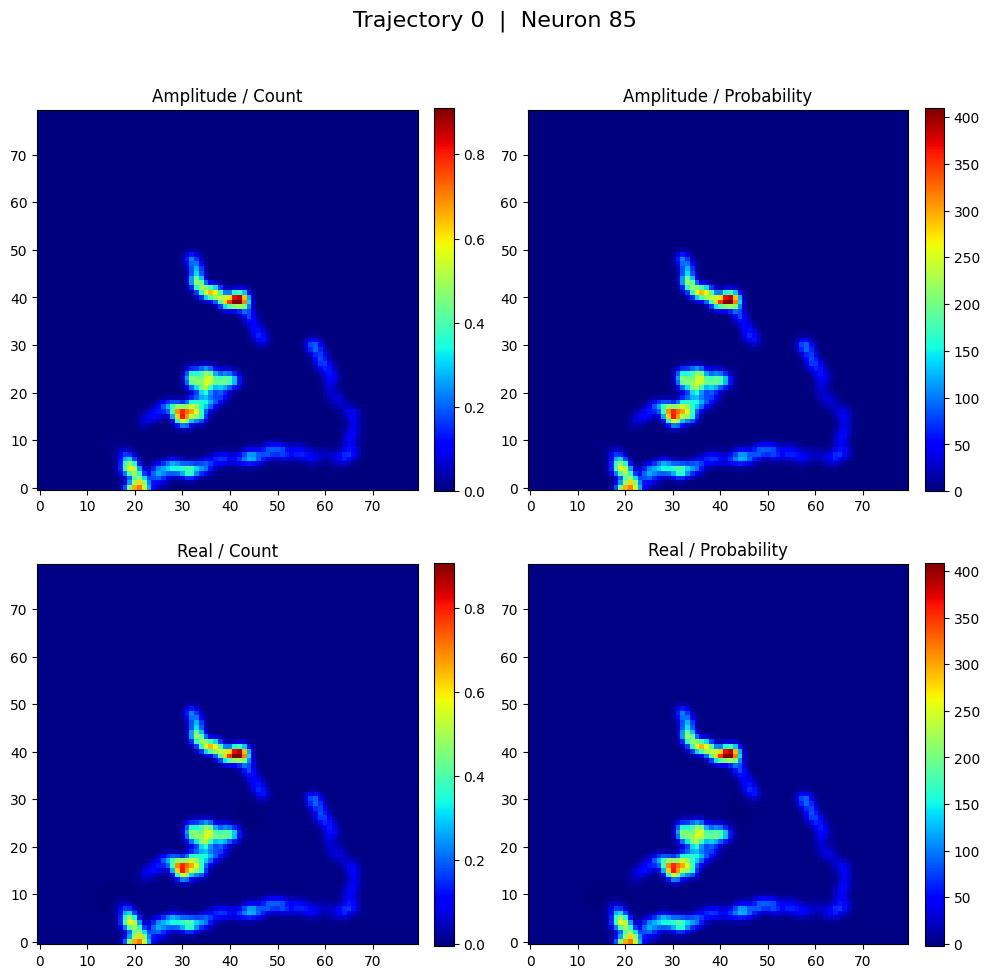

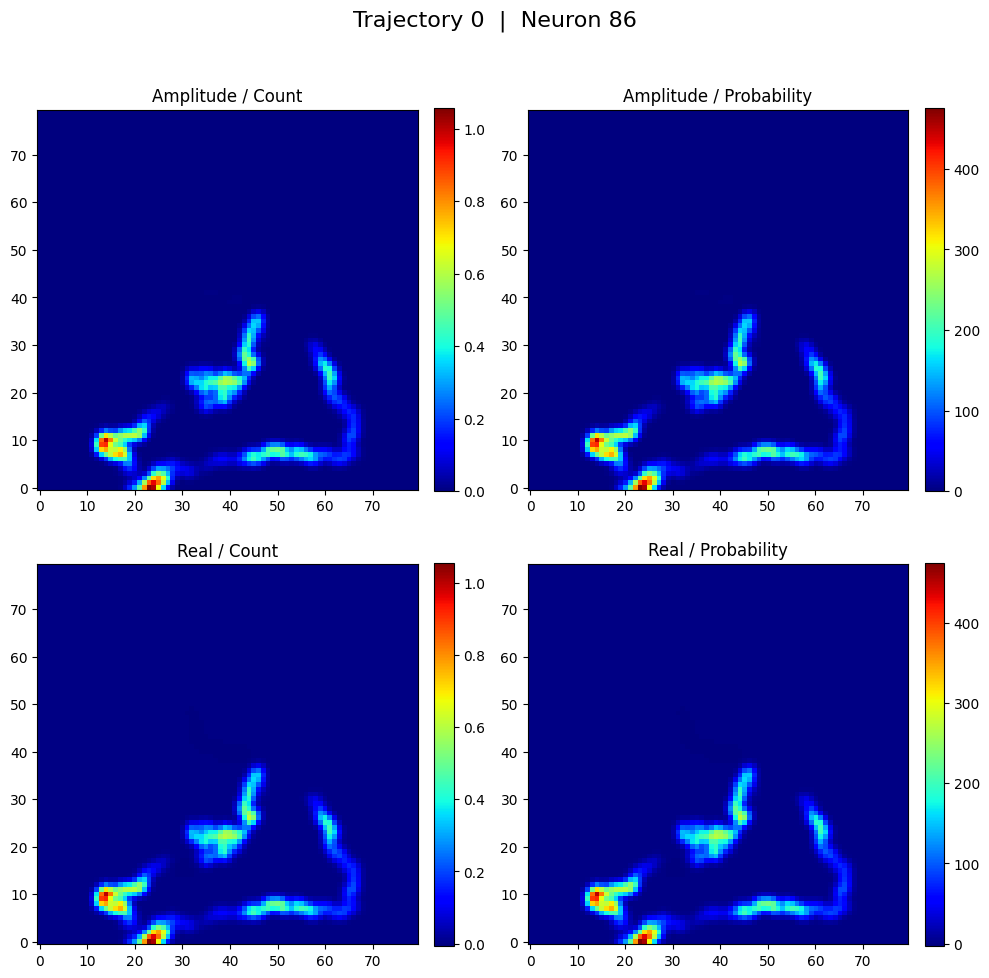

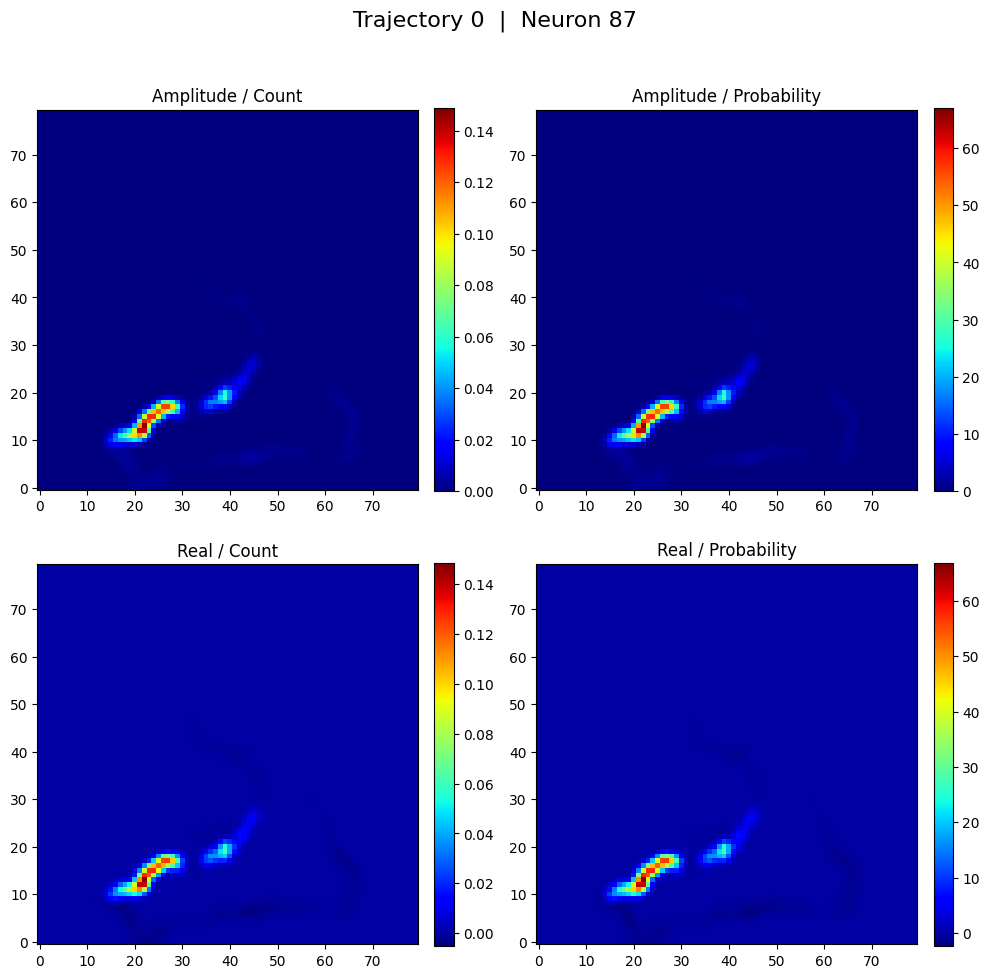

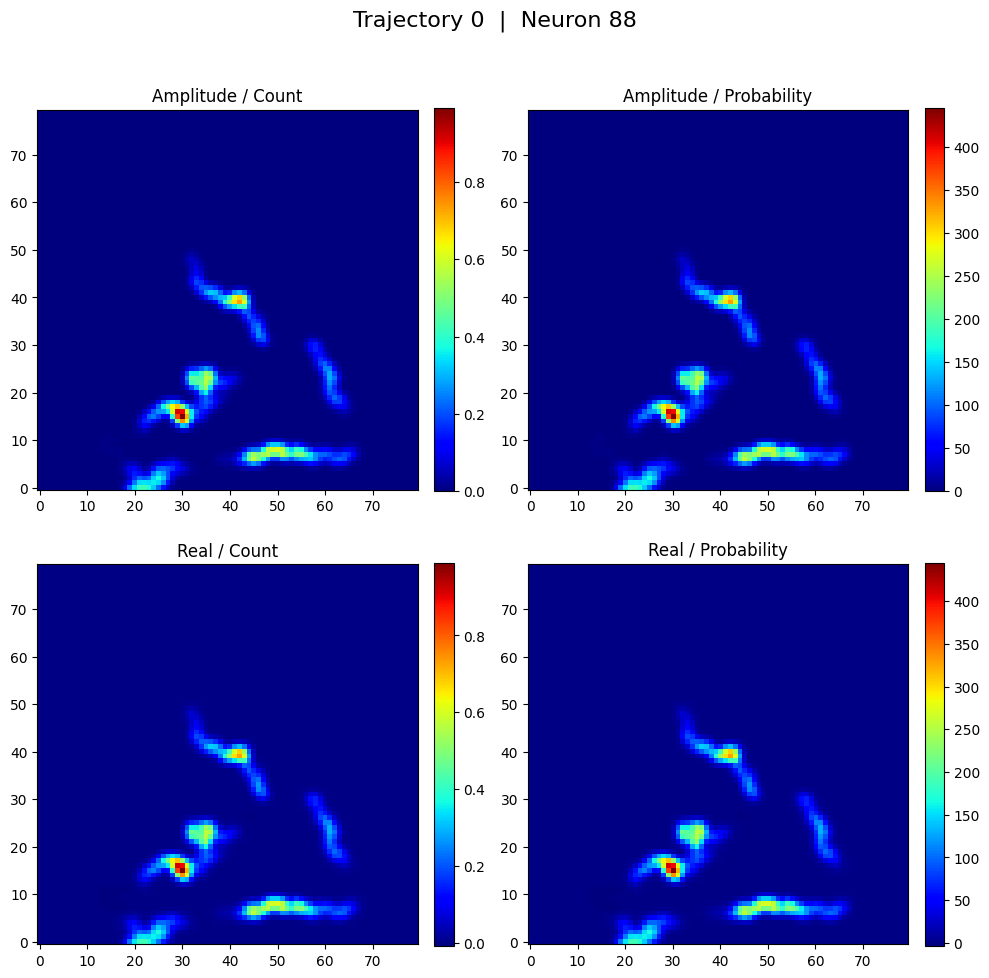

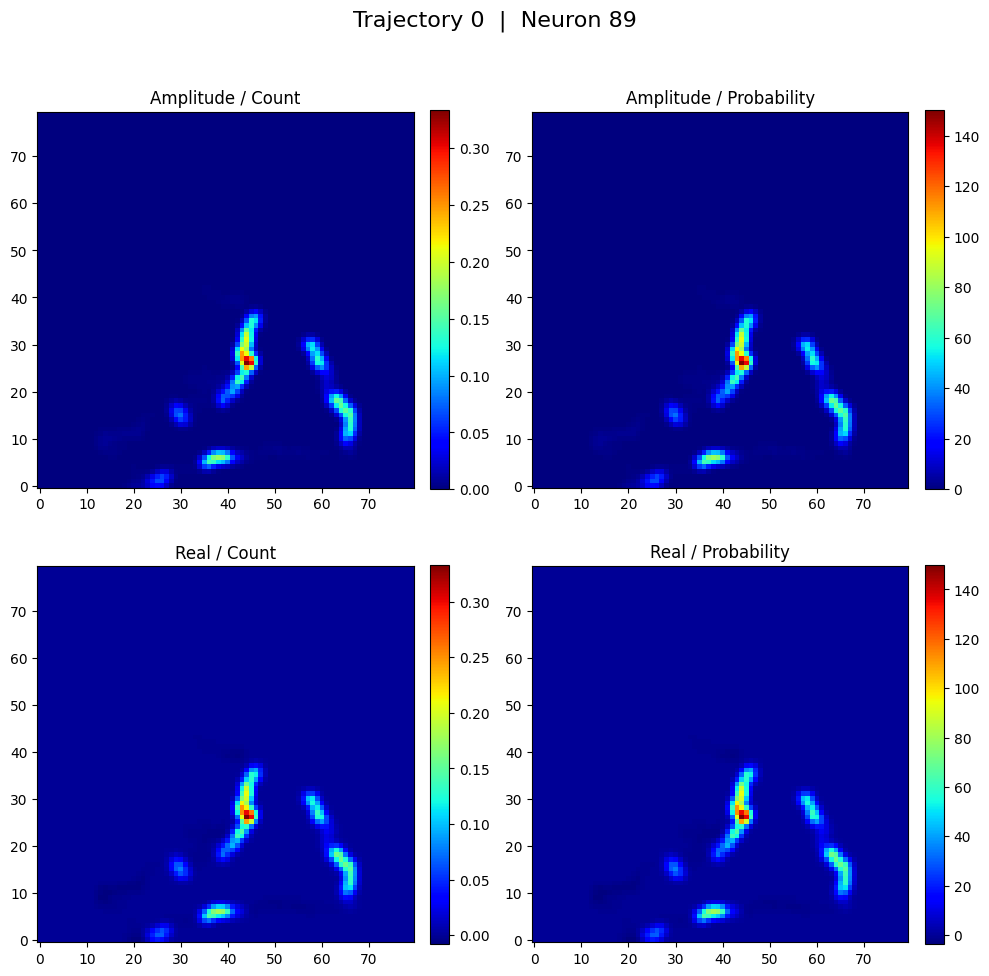

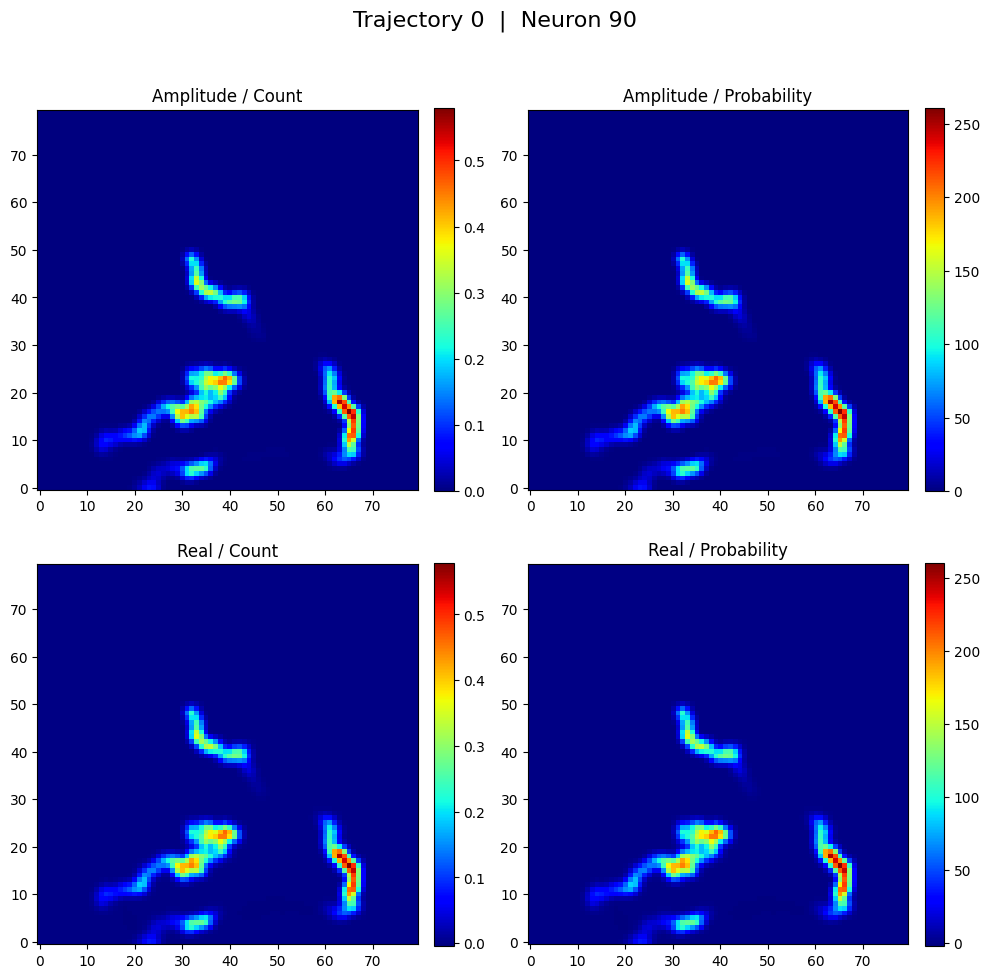

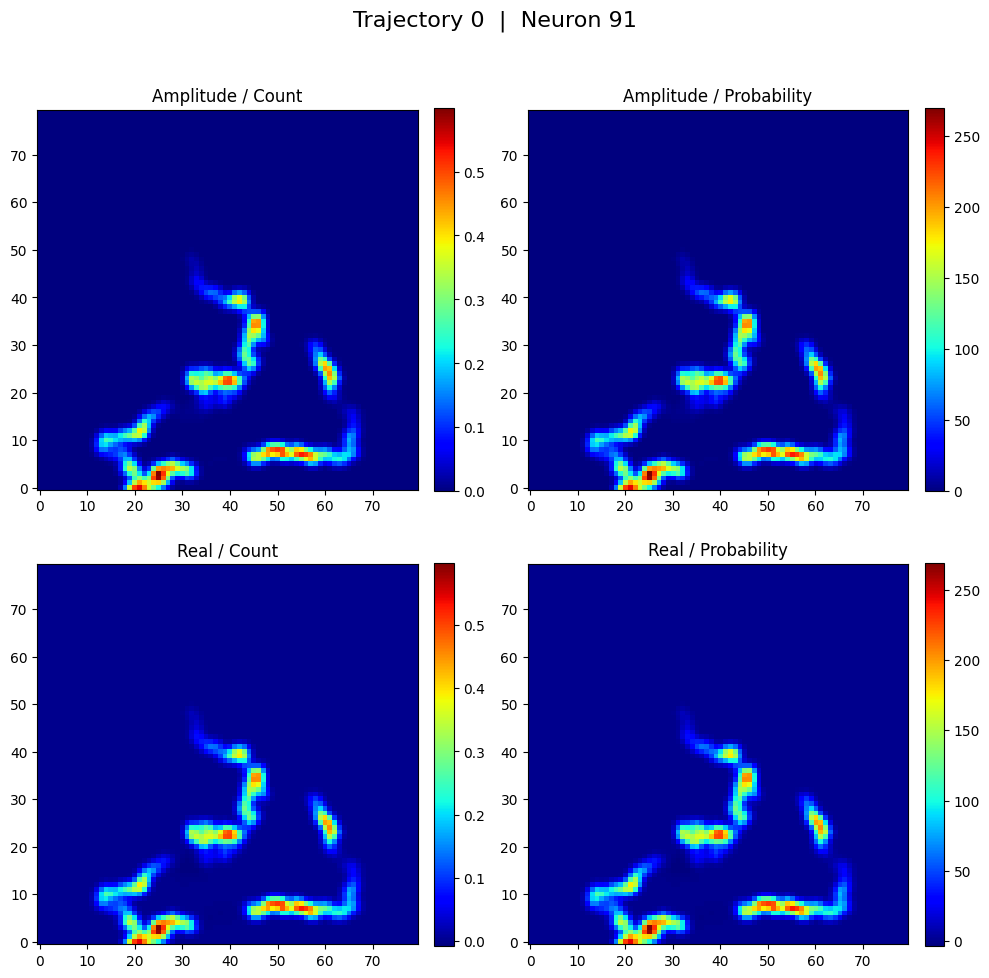

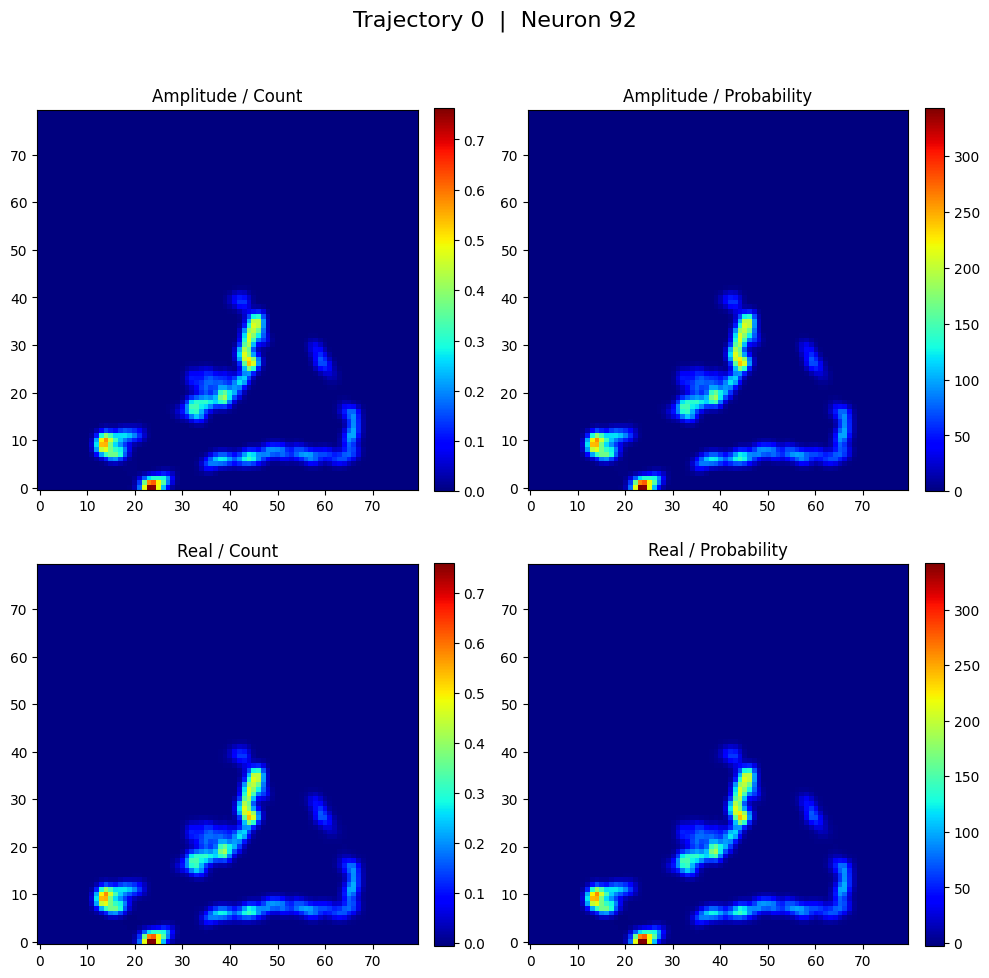

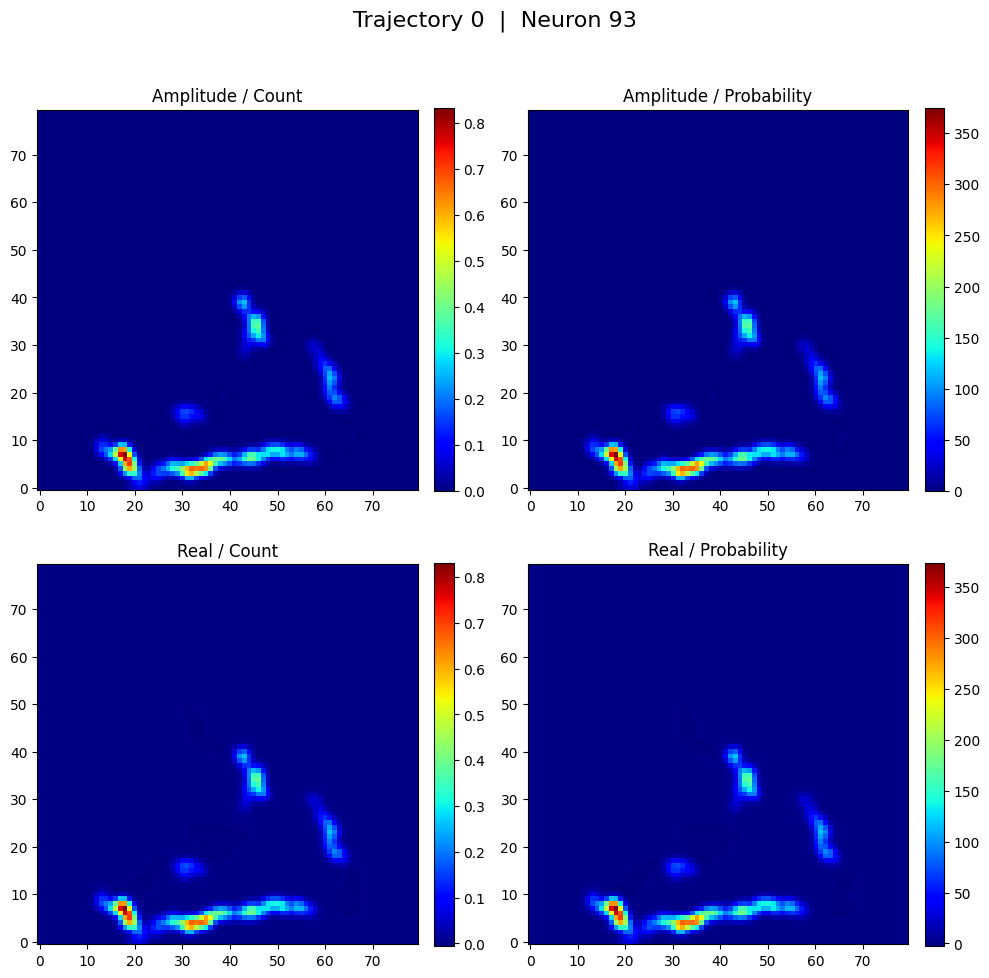

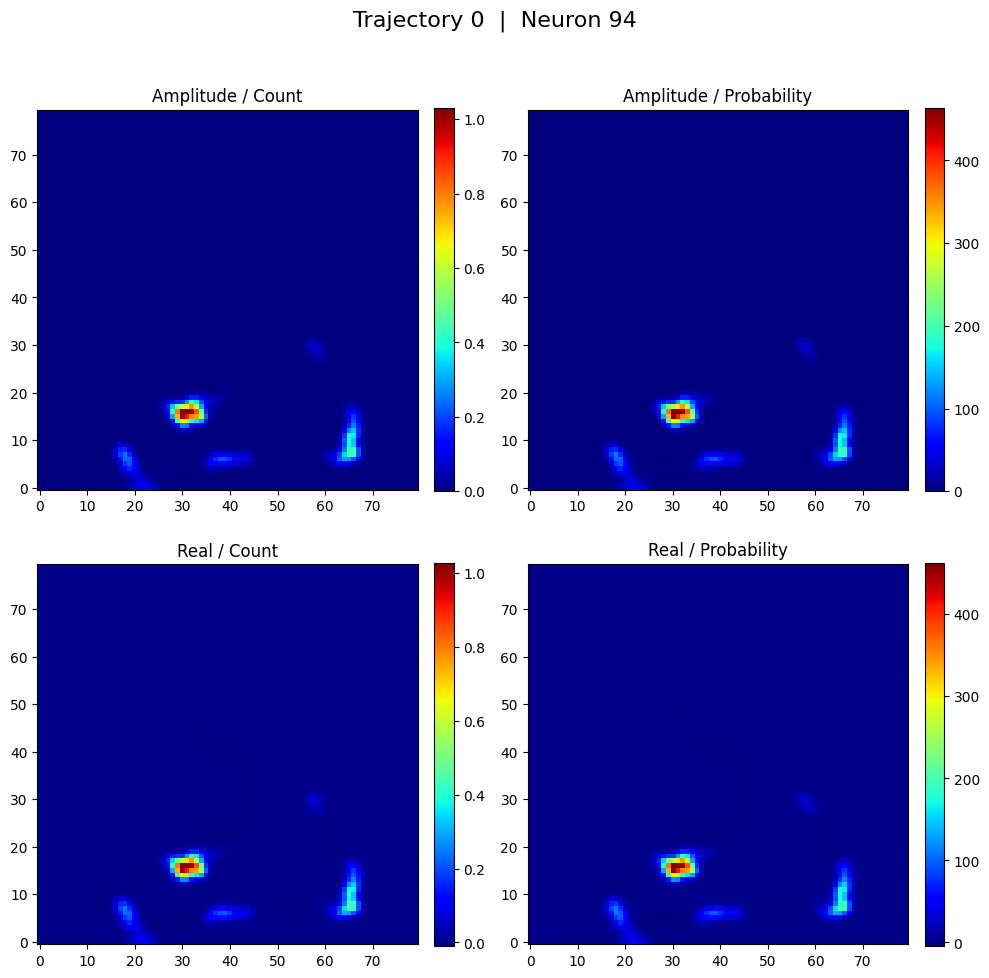

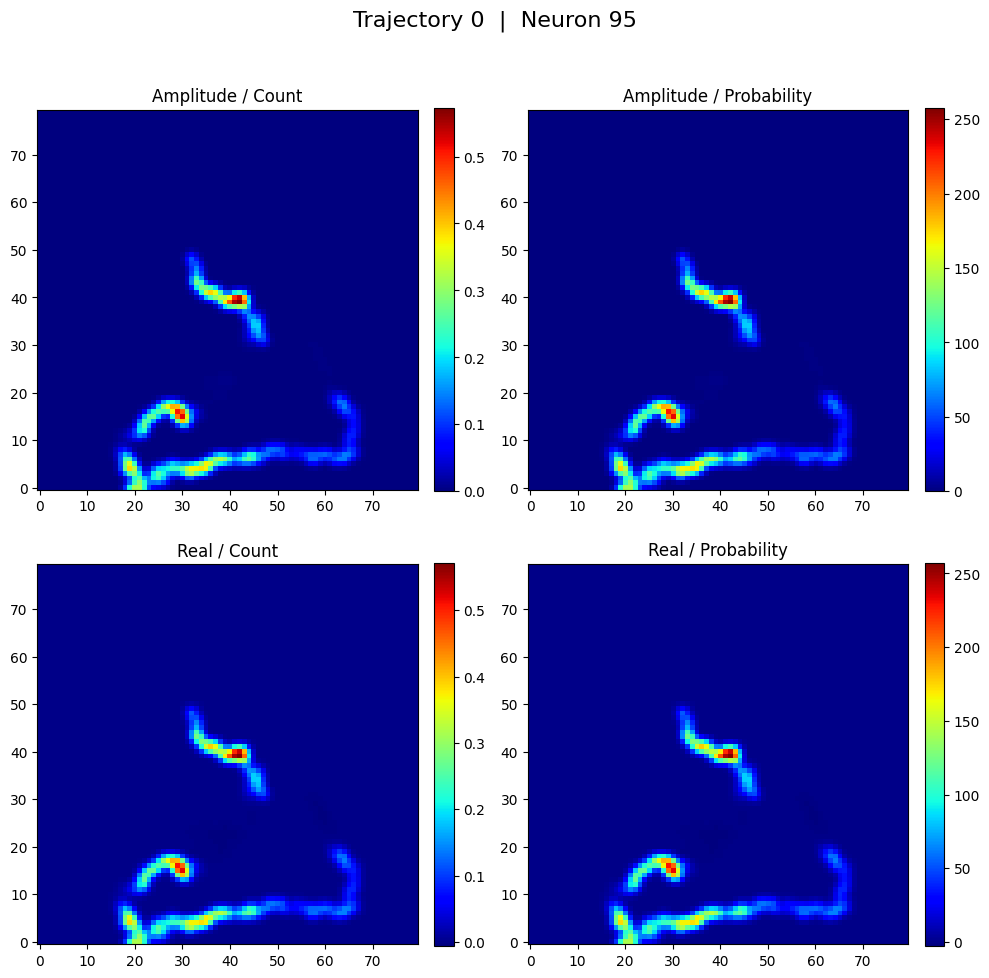

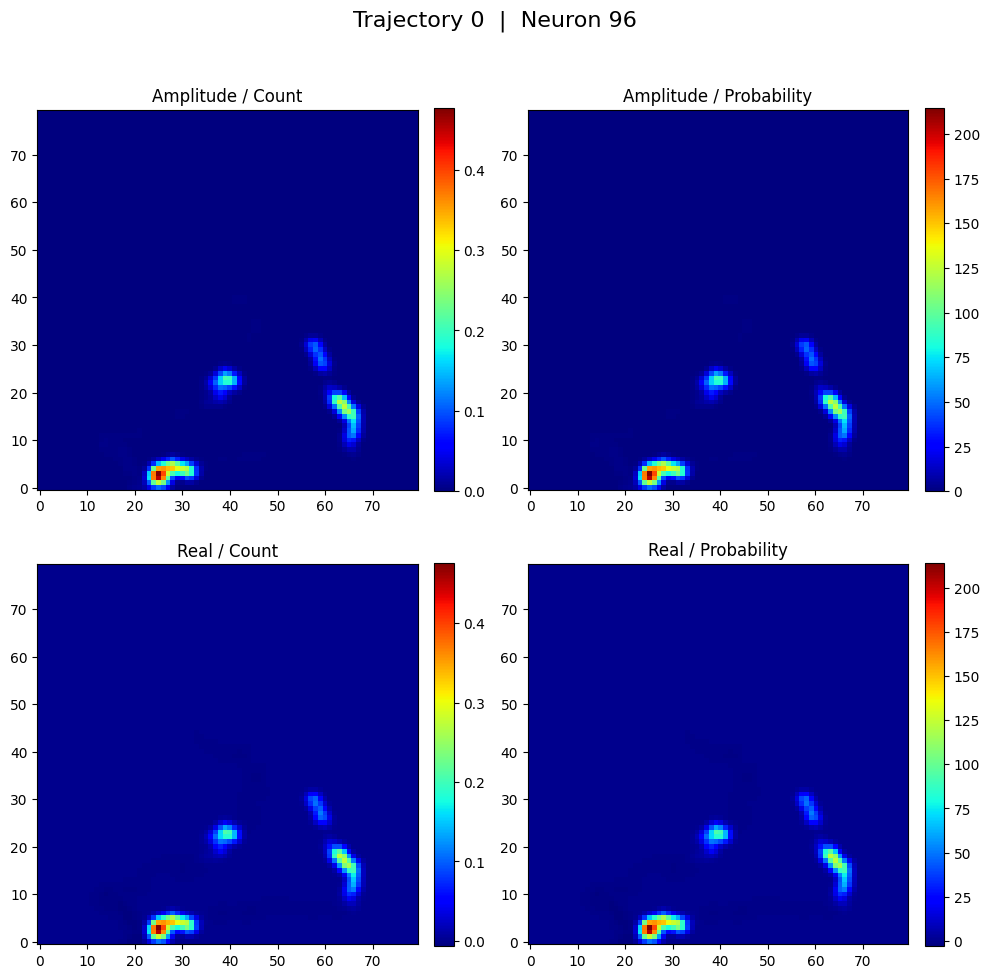

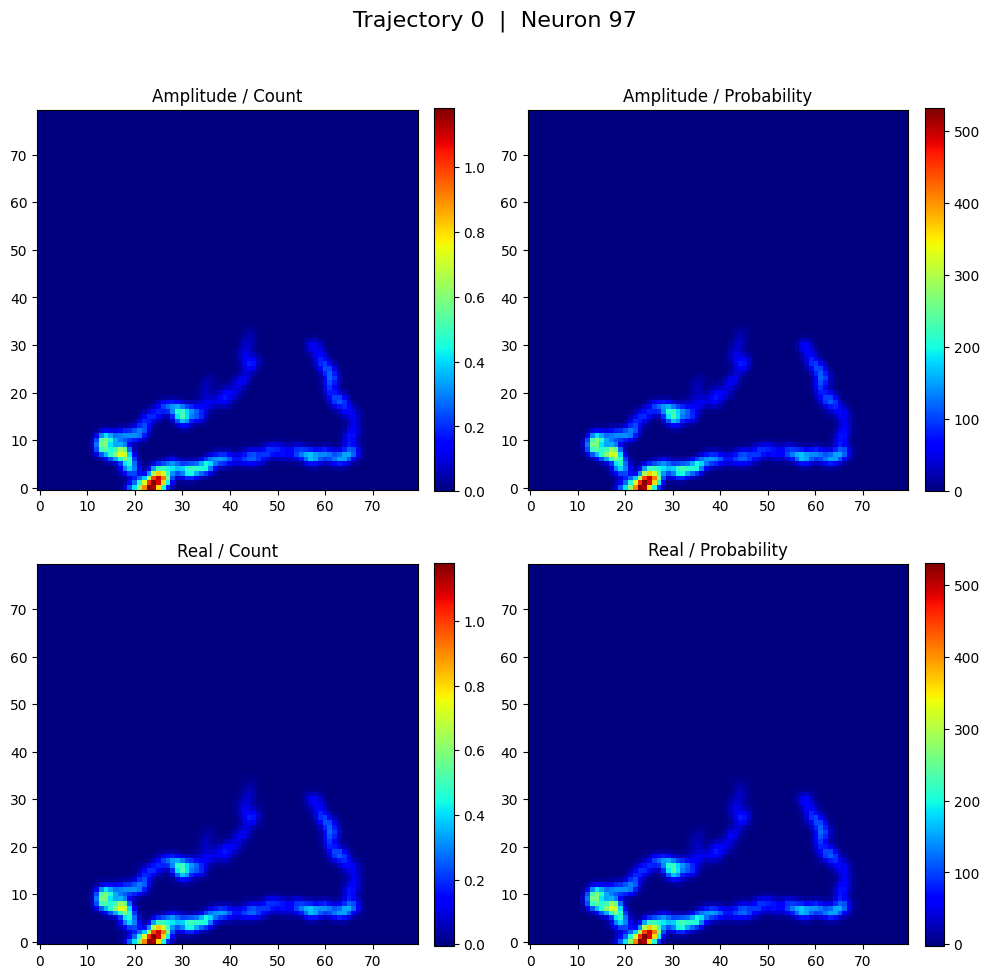

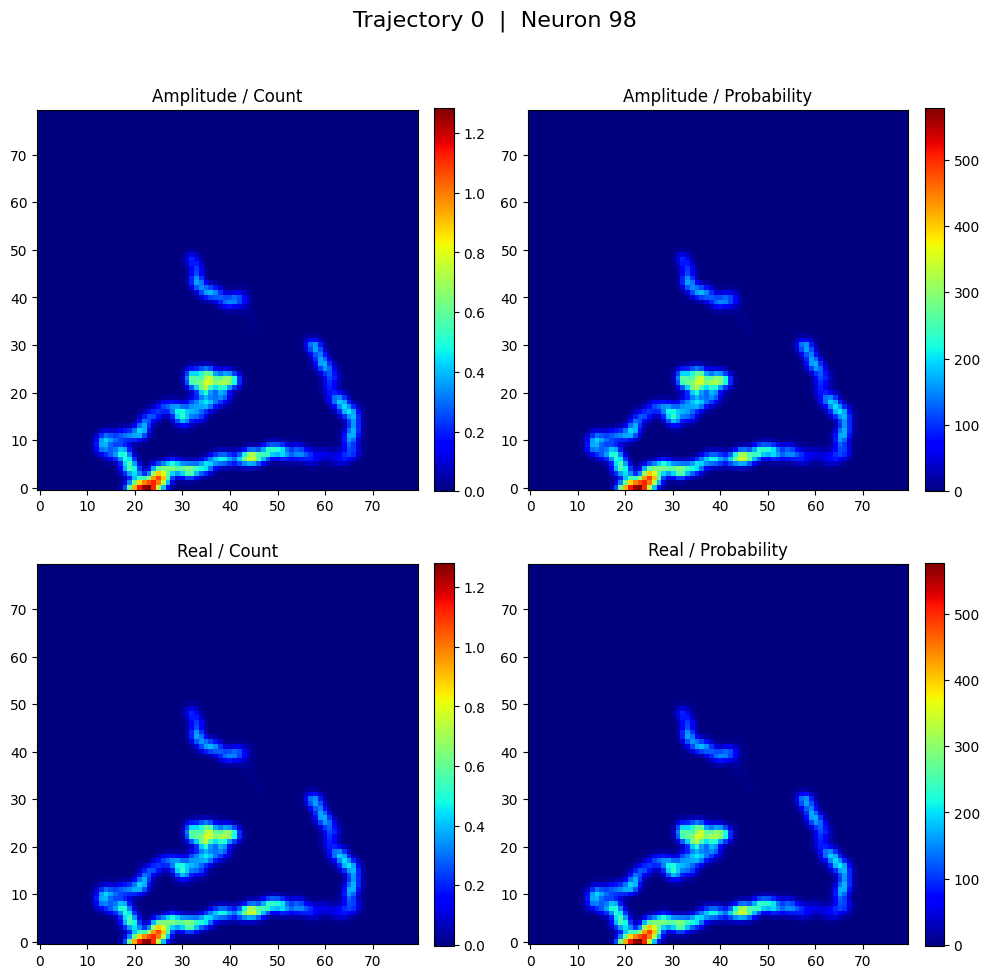

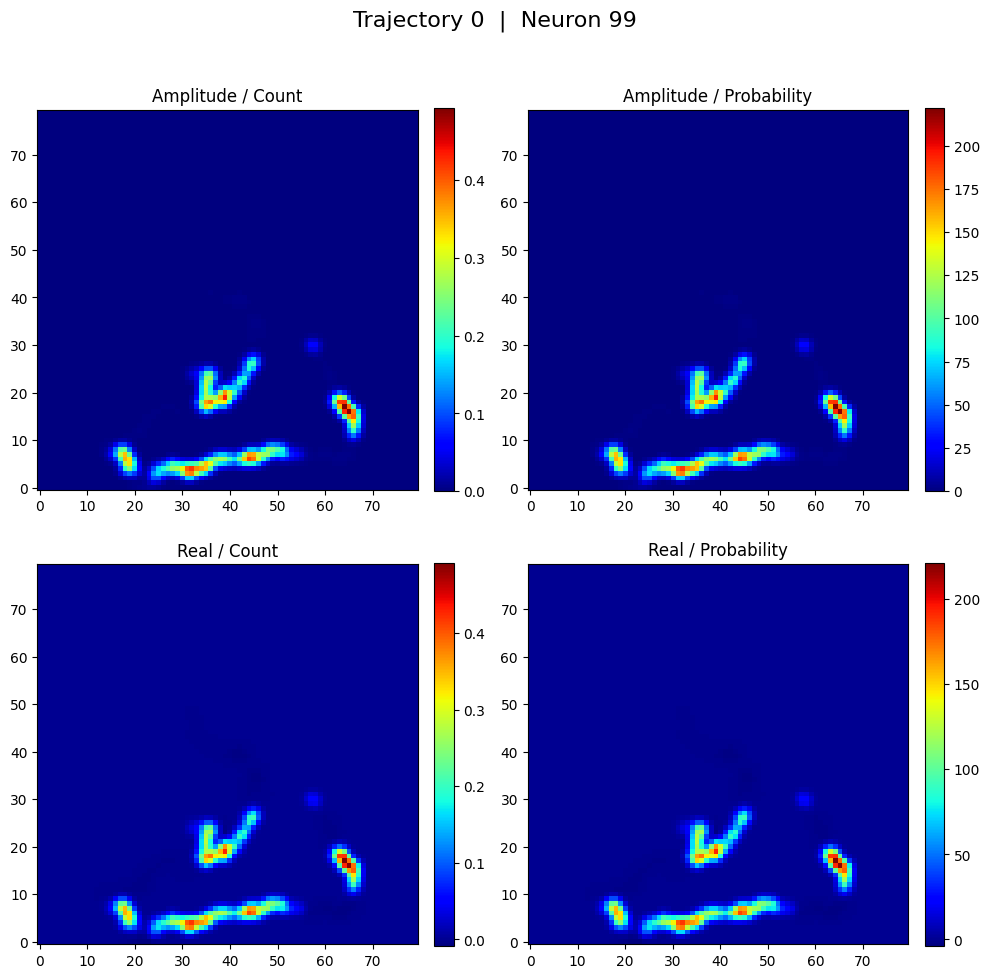

In [31]:
for result in all_results:

    neuron = result["neuron"]

    fig, ax = plt.subplots(2, 2, figsize=(10, 10))

    maps = [

        (
            "Amplitude / Count",
            result["amp_count_smoothed"],
        ),

        (
            "Amplitude / Probability",
            result["amp_prob_smoothed"],
        ),

        (
            "Real / Count",
            result["real_count_smoothed"],
        ),

        (
            "Real / Probability",
            result["real_prob_smoothed"],
        ),

    ]

    for axis, (title, rate_map) in zip(ax.ravel(), maps):

        im = axis.imshow(
            rate_map,
            origin="lower",
            interpolation="nearest",
            cmap="jet"
        )

        axis.set_title(title)

        plt.colorbar(
            im,
            ax=axis,
            fraction=0.046,
            pad=0.04,
        )

    fig.suptitle(
        f"Trajectory {trajectory}  |  Neuron {neuron}",
        fontsize=16,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    plt.show()
